# Anexo A - Backtesting temporal y diagnóstico ampliado del forecasting de biogás

Este notebook conserva el desarrollo completo del proyecto principal y añade una validación temporal con ventanas expansivas. Su propósito es comprobar si los resultados se mantienen en distintos periodos y estudiar con más detalle el comportamiento de los errores. **Este anexo amplía el trabajo principal, pero no lo sustituye.**

## Contexto del proyecto principal


La **digestión anaerobia** es un **proceso biológico** en el cual **los microorganismos descomponen materia orgánica en ausencia de oxígeno**. Durante este proceso se genera **biogás**, una mezcla de gases que **contiene principalmente metano y dióxido de carbono** y que **puede** aprovecharse como fuente de energía para **generar electricidad, producir calor y funcionar como combustible tras depurarlo**.

Desde el punto de vista industrial, es muy importante no solo producir biogás, sino también comprender cómo cambia su producción cuando varían la alimentación y las condiciones de operación. Poder anticipar estos cambios puede ayudar a planificar el aprovechamiento energético y a identificar situaciones que requieran una revisión del proceso.

En este proyecto voy a analizar los datos de la planta de recuperación de recursos hídricos de **Muscatine, Iowa, Estados Unidos**. El conjunto de datos incluye información diaria de laboratorio y operación, además de registros por minuto obtenidos mediante el sistema SCADA de la instalación.

**El objetivo principal es** evaluar si la información histórica permite **predecir el caudal medio de biogás para distintos horizontes de tiempo.** Para ello, primero voy a revisar la calidad de los datos y su continuidad temporal. Después analizaré los patrones más relevantes y compararé modelos de Machine Learning, comenzando con una predicción a un día y evaluando los horizontes D+1, D+3, D+7, D+15 y D+30. Utilizaré pronósticos sencillos como referencia para comprobar si los modelos aportan una mejora real.

La finalidad no es solamente encontrar el modelo con menor error, sino comprender qué información aporta al análisis, en qué situaciones se equivoca y cuáles son sus limitaciones para apoyar decisiones de operación.


## Descripción del conjunto de datos

El conjunto de datos posee dos tablas que describen la misma instalación desde distintas frecuencias de medición:

| Tabla | Información disponible | Frecuencia |
|---|---|---|
| LABS | Alimentación, temperaturas, pH, retención de sólidos, análisis de laboratorio y caudal medio de biogás. | Diaria, con un período sin registros y valores ausentes en algunas variables. |
| SCADA | Temperaturas, caudales, niveles y distribución del biogás hacia la caldera y el quemador. | Por minuto, con algunos intervalos sin registros. |


Los archivos incluyen variables individuales para dos digestores. Sin embargo, **el caudal de biogás está registrado como total y no por digestor**. Además, no se dispone de una medición de la concentración de metano, por lo que no voy a estimar su producción utilizando un porcentaje supuesto.

La variable `Biogas` está expresada en **pies cúbicos por minuto (CFM)**. En LABS, los autores calcularon este caudal medio diario dividiendo el volumen total de biogás registrado durante el día entre los **1.440 minutos del día**. El artículo no indica condiciones normalizadas de presión y temperatura; por eso puedo convertirlo a **m³/día**, pero no denominarlo **Nm³/día**.

Comenzaré con la tabla diaria para desarrollar el primer modelo. La información SCADA permitirá revisar el comportamiento con mayor detalle y evaluar posteriormente si conviene ampliar el pronóstico a una resolución horaria.

Antes de usar cada variable como característica del modelo, revisaré si su valor estaría disponible en el momento de realizar la predicción. Esto es especialmente importante para los análisis de laboratorio, cuyos resultados pueden conocerse después del momento de muestreo.


Para desarrollar el proyecto seguiré este orden: **revisión y preparación de datos, análisis gráfico, modelado predictivo, evaluación, conclusiones y exportación de tablas para Power BI**. La separación de entrenamiento, validación y prueba respetará siempre el orden temporal.


## Fuente de los datos

El conjunto de datos fue publicado por Hunter W. Schroer y Craig L. Just a través de la Universidad de Iowa.

- [Dataset: Laboratory, operational, and SCADA datasets for anaerobic co-digestion at the Muscatine, IA Water Resource Recovery Facility](https://doi.org/10.25820/data.006715).
- [Artículo: Feature Engineering and Supervised Machine Learning to Forecast Biogas Production during Municipal Anaerobic Co-Digestion](https://pmc.ncbi.nlm.nih.gov/articles/PMC10928704/).
- [Código de referencia de los autores](https://github.com/hunter-schroer/municipal-biogas-forecasting).

Los archivos originales ya incluyen algunos tratamientos documentados por los autores. Conservaré esos archivos sin modificaciones y registraré por separado las decisiones de limpieza que aplique durante el análisis.


# 1. Análisis exploratorio de los datos

## 1.1 Importo las librerías y reviso la ubicación de los archivos

Antes de cargar los datos, voy a comprobar que estoy trabajando en la carpeta correcta y que los archivos necesarios están disponibles. Después revisaré las dos tablas por separado para entender su estructura antes de realizar cualquier cambio.


In [1]:
# Importo las librerías que utilizaré al comenzar el análisis
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Configuro pandas para visualizar todas las columnas
pd.set_option('display.max_columns', None)

# Identifico la carpeta principal del proyecto mediante una ruta relativa
ruta_proyecto = Path.cwd()
if ruta_proyecto.name.lower() == 'notebooks':
    ruta_proyecto = ruta_proyecto.parent

ruta_datos = ruta_proyecto / 'data' / 'raw'

# Compruebo dónde se ejecuta el código y dónde están mis datos
print('Librerías importadas correctamente.')
print('Carpeta de ejecución:', Path.cwd())
print('Carpeta del proyecto:', ruta_proyecto)
print('Existe la carpeta del proyecto:', ruta_proyecto.is_dir())
print('Existe la carpeta de datos:', ruta_datos.is_dir())

# Reviso que los cinco archivos necesarios estén disponibles
archivos = ['README.txt', 'Biogas-data-dictionary-LAB-dataset.csv',
            'Biogas-data-dictionary-SCADA-dataset.csv', 'LABS-raw.csv', 'SCADA-raw.csv']
for archivo in archivos:
    print(archivo, '->', (ruta_datos / archivo).is_file())


Librerías importadas correctamente.
Carpeta de ejecución: C:\Users\sergi\Documents\CHECHO\PORTFOLIO - sappdfportfolio.com - html5up-spectral\github\forecasting-biogas-production\notebooks
Carpeta del proyecto: C:\Users\sergi\Documents\CHECHO\PORTFOLIO - sappdfportfolio.com - html5up-spectral\github\forecasting-biogas-production
Existe la carpeta del proyecto: True
Existe la carpeta de datos: True
README.txt -> True
Biogas-data-dictionary-LAB-dataset.csv -> True
Biogas-data-dictionary-SCADA-dataset.csv -> True
LABS-raw.csv -> True
SCADA-raw.csv -> True


## 1.2 Cargo las tablas

Voy a trabajar con los registros diarios de operación y laboratorio de LABS y los registros por minuto de SCADA, correspondientes a la planta de Muscatine.

Según la documentación, los autores ya realizaron un preprocesamiento de los archivos. Por eso, aunque sus nombres incluyen «raw», no representan datos completamente sin tratar.

Cargo ambas tablas por separado y reviso sus primeras y últimas filas antes de comenzar la preparación de los datos.


In [2]:
# Cargo las dos tablas y conservo una versión original de cada una
df_lab_original = pd.read_csv(ruta_datos / 'LABS-raw.csv')
df_scada_original = pd.read_csv(ruta_datos / 'SCADA-raw.csv')

# Creo las copias que utilizaré durante el análisis
df_lab = df_lab_original.copy()
df_scada = df_scada_original.copy()

# Reviso las dimensiones y las primeras y últimas filas de LABS
print('LABS: filas y columnas:', df_lab.shape)
print('Primeras cinco filas:')
display(df_lab.head())
print('Últimas cinco filas:')
display(df_lab.tail())

# Reviso las dimensiones y las primeras y últimas filas de SCADA
print('SCADA: filas y columnas:', df_scada.shape)
print('Primeras cinco filas:')
display(df_scada.head())
print('Últimas cinco filas:')
display(df_scada.tail())


LABS: filas y columnas: (1103, 25)
Primeras cinco filas:


,Year,Month,Day,V-TWAS_gal,V-PS_gal,V-HSW_gal,Dig1-T_degF,Dig2-T_degF,Dig1-pH,Dig2-pH,FOG_gal,SRT,HSW-VS_percent,HSW-COD_mgL,Dig1-alk_mgL,Dig2-alk_mgL,Dig1-VFA_mgL,Dig2-VFA_mgL,Dig1-FOS-TAC,Dig2-FOS-TAC,Q-influent_MGD,BOD-influent_mgL,TWAS-VS_percent,PS-VS_percent,Biogas
0,2020,1,1,4583,15412,0,95.5,95.4,7.07,7.06,0,42.9,0.0,0.0,4399.0,4214.0,NaN,NaN,NaN,NaN,2.70,108.0,3.70,1.9,43.3
1,2020,1,2,7690,17232,0,95.3,95.4,7.31,7.24,7328,26.6,0.0,0.0,4285.0,4187.0,NaN,NaN,NaN,NaN,2.85,135.0,3.66,1.9,62.8
2,2020,1,3,2516,15412,0,95.2,95.4,7.23,7.21,15537,25.6,0.0,0.0,4269.0,4084.0,NaN,NaN,NaN,NaN,2.70,184.0,3.56,2.3,53.0
3,2020,1,4,2429,15865,0,94.9,95.1,6.92,6.99,0,46.9,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.58,253.0,3.53,NaN,41.9
4,2020,1,5,2447,15556,0,95.7,95.7,6.98,6.98,0,47.7,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.69,135.7,3.49,NaN,32.5


Últimas cinco filas:


,Year,Month,Day,V-TWAS_gal,V-PS_gal,V-HSW_gal,Dig1-T_degF,Dig2-T_degF,Dig1-pH,Dig2-pH,FOG_gal,SRT,HSW-VS_percent,HSW-COD_mgL,Dig1-alk_mgL,Dig2-alk_mgL,Dig1-VFA_mgL,Dig2-VFA_mgL,Dig1-FOS-TAC,Dig2-FOS-TAC,Q-influent_MGD,BOD-influent_mgL,TWAS-VS_percent,PS-VS_percent,Biogas
1098,2023,3,27,16313,16952,16720,96.1,95.8,7.41,7.40,15692,17.2,1.96,50750.0,7017.0,7641.0,1123.0,1466.0,0.16,0.19,3.64,NaN,3.13,3.61,75.2
1099,2023,3,28,16189,17947,20073,95.8,95.9,7.38,7.38,18001,15.8,7.69,76950.0,6891.0,7282.0,1082.0,1415.0,0.16,0.19,3.41,369.0,3.20,3.56,83.3
1100,2023,3,29,17065,17097,25129,96.2,95.7,7.34,7.33,23254,14.5,3.90,92100.0,6795.0,7549.0,1168.0,1563.0,0.17,0.21,3.29,496.0,3.30,2.96,93.6
1101,2023,3,30,15733,18843,23009,95.7,95.8,7.30,7.29,17578,14.9,2.77,59600.0,6650.0,7042.0,1223.0,1294.0,0.18,0.18,3.22,432.0,3.10,3.67,62.0
1102,2023,3,31,16119,18905,12079,95.9,96.3,7.39,7.34,11098,18.2,4.21,97900.0,6481.0,6711.0,1186.0,1410.0,0.18,0.21,3.40,441.0,2.97,3.53,66.0


SCADA: filas y columnas: (500400, 27)
Primeras cinco filas:


,Timestamp,D1_TEMPERATURE,D2_TEMPERATURE,Q-PS_MGD,Q-influent_MGD,Q-TWAS_GPM,Q-Aeration_SCFM,RAS-1-GATE_MGD,RAS-2-GATE_MGD,RAS-3-GATE_MGD,Q-RAS1_MGD,Q-RAS2_MGD,Q-RAS3_MGD,Q-WAS1_MGD,Q-WAS2_MGD,V-burner_FT3,V-Boiler_FT3,Q-HSW1_GPM,Q-HSW2_GPM,V-HSW-DIG2-yest_gal,H-HSW_ft,Q-RAS_MGD,H-Dig1_FT,H-Dig2_FT,Biogas,Biogas_burner,Biogas_boiler
0,2023-01-01 00:00:00,95.97,96.15,0.04,3.16,0.17,5916.84,1.61,1.62,1.64,0.0,4.29,0.0,0.08,0.07,20.23,14.74,2.64,0.0,7380.59,6.16,4.29,5.95,4.70,187.196480,106.940117,80.256363
1,2023-01-01 00:01:00,96.05,96.27,393.53,3.91,0.17,5927.83,1.63,1.62,1.64,0.0,4.31,0.0,0.07,0.08,128.71,95.09,2.62,0.0,1897.08,6.19,4.30,5.96,4.68,188.329361,107.794663,80.534698
2,2023-01-01 00:02:00,95.99,96.17,380.98,3.92,0.17,5908.29,1.63,1.55,1.64,0.0,4.31,0.0,0.07,0.08,236.32,175.59,2.63,0.0,1897.08,6.16,4.30,5.96,4.66,190.409576,109.808952,80.600624
3,2023-01-01 00:03:00,95.86,96.11,0.04,3.38,0.17,5905.85,1.61,1.61,1.64,0.0,4.31,0.0,0.07,0.08,343.46,256.06,2.61,0.0,1897.08,6.15,4.32,5.94,4.65,186.254044,105.719345,80.534698
4,2023-01-01 00:04:00,95.96,96.16,0.04,3.35,0.17,5883.88,1.61,1.63,1.64,0.0,4.32,0.0,0.08,0.08,448.23,336.62,2.62,0.0,1897.08,6.14,4.32,5.89,4.63,181.170731,100.775200,80.395531


Últimas cinco filas:


,Timestamp,D1_TEMPERATURE,D2_TEMPERATURE,Q-PS_MGD,Q-influent_MGD,Q-TWAS_GPM,Q-Aeration_SCFM,RAS-1-GATE_MGD,RAS-2-GATE_MGD,RAS-3-GATE_MGD,Q-RAS1_MGD,Q-RAS2_MGD,Q-RAS3_MGD,Q-WAS1_MGD,Q-WAS2_MGD,V-burner_FT3,V-Boiler_FT3,Q-HSW1_GPM,Q-HSW2_GPM,V-HSW-DIG2-yest_gal,H-HSW_ft,Q-RAS_MGD,H-Dig1_FT,H-Dig2_FT,Biogas,Biogas_burner,Biogas_boiler
500395,2022-12-31 23:55:00,95.96,96.12,0.08,1.88,0.17,5767.91,1.63,1.62,1.63,0.0,4.31,0.0,0.08,0.08,100000.0,51516.59,2.61,0.0,7380.59,6.17,4.31,6.05,4.78,111.544897,85.820671,25.724226
500396,2022-12-31 23:56:00,96.00,96.15,0.04,1.91,0.15,5866.79,1.61,1.62,1.64,0.0,4.28,0.0,0.08,0.07,100000.0,51546.11,2.64,0.0,7380.59,6.20,4.28,6.05,4.78,159.514137,116.767387,42.746750
500397,2022-12-31 23:57:00,95.88,96.10,0.04,1.68,0.17,5822.84,1.61,1.62,1.64,0.0,4.29,0.0,0.07,0.07,100000.0,51605.24,2.92,0.0,7380.59,6.15,4.29,6.02,4.75,183.927238,113.288162,70.639076
500398,2022-12-31 23:58:00,95.97,96.15,0.04,2.13,0.17,5927.83,1.63,1.62,1.64,0.0,4.30,0.0,0.08,0.07,100000.0,51680.69,2.64,0.0,7380.59,6.16,4.30,6.00,4.73,191.332481,113.105049,78.227432
500399,2022-12-31 23:59:00,96.04,96.22,0.04,2.85,0.17,5902.19,1.58,1.62,1.64,0.0,4.29,0.0,0.08,0.07,100000.0,51760.05,2.64,0.0,7380.59,6.17,4.31,5.98,4.71,189.703957,109.747910,79.956047


### Observaciones después de cargar las tablas

La tabla LABS contiene 1.103 filas y 25 columnas, mientras que SCADA contiene 500.400 filas y 27 columnas. Al visualizar LABS se observan valores ausentes en algunas variables de laboratorio. Los conservo para revisar su distribución en el siguiente paso.

Las primeras filas de SCADA corresponden a enero de 2023 y las últimas a diciembre de 2022. Esto permite ver que el orden del archivo no coincide con el orden temporal; revisaré y organizaré las fechas durante la auditoría temporal.

La documentación indica que los autores ya retiraron algunos registros, eliminaron análisis repetidos e hicieron asignaciones iniciales en HSW-VS y HSW-COD. Por lo tanto, los archivos publicados no representan datos totalmente sin tratamiento. Tendré en cuenta estas decisiones al interpretar valores ausentes y ceros.


## 1.3 Describo las variables y su función dentro del proceso

Antes de continuar con los gráficos, organizo las variables para comprender qué información aporta cada una. En este caso, las tablas describen una misma planta: algunas variables corresponden al digestor 1 o 2 y otras al conjunto de la instalación. Por lo tanto, no voy a interpretar D1 y D2 como reactores con licor real o sintético.

### Significado de las siglas

| Sigla | Significado | Cómo la interpreto en este análisis |
|---|---|---|
| TWAS | Thickened Waste Activated Sludge: lodo biológico excedente espesado. | Una de las corrientes de alimentación de los digestores. |
| PS | Primary Sludge: lodo primario. | Otra corriente de alimentación procedente de la separación inicial del agua residual. |
| HSW | High Strength Waste: residuos de alta carga orgánica. | Alimentación adicional de codigestión. La descripción LABS agrega «activated sludge», pero el diccionario SCADA utiliza el término general; conservo esta discrepancia. |
| FOG | Fats, Oils and Grease: grasas y aceites. | Volumen recibido en planta; no equivale necesariamente al volumen alimentado ese día. |
| SRT | Solids Retention Time: tiempo de retención de sólidos. | Retención de sólidos en días; no lo sustituyo por HRT. |
| VS | Volatile Solids: sólidos volátiles. | Indicador de la fracción de sólidos potencialmente relacionada con materia orgánica; no es una medición directa de biodegradabilidad. |
| COD | Chemical Oxygen Demand: demanda química de oxígeno (DQO). | Caracterización de la carga del residuo. |
| BOD | Biochemical Oxygen Demand: demanda bioquímica de oxígeno (DBO). | Caracterización del agua que entra a la planta. |
| VFA | Volatile Fatty Acids: ácidos grasos volátiles (AGV). | Variable para revisar la evolución del proceso junto con pH y alcalinidad. |
| FOS/TAC | Relación analítica entre ácidos orgánicos y alcalinidad. | El diccionario la describe como relación VFA/alcalinidad. No la recalculo automáticamente como división de las dos columnas ni aplico un umbral universal. |
| RAS | Return Activated Sludge: lodo activado recirculado. | Variables de recirculación del tratamiento de agua; no son todas alimentación directa al digestor. |
| WAS | Waste Activated Sludge: lodo activado excedente. | Corriente retirada del proceso biológico. |
| SCADA | Supervisory Control and Data Acquisition. | Sistema que registra señales operativas por minuto. |

Las unidades originales incluyen galones, °F, mg/L, porcentaje en masa, pies y pies cúbicos. MGD significa millones de galones por día; GPM, galones por minuto; CFM, pies cúbicos por minuto. Mantengo las unidades publicadas y no convierto caudales a volúmenes sin considerar el intervalo que representan.

### Variables de la tabla diaria LABS

Cuando agrupo nombres con 1 y 2, cada nombre corresponde a una columna distinta de su respectivo digestor. La frecuencia de la tabla es diaria, pero las mediciones de laboratorio pueden presentar ausentes y sus resultados pueden conocerse después del muestreo.

| Variable original | Significado | Unidad | Alcance y utilidad |
|---|---|---|---|
| Fecha; Year; Month; Day | Fecha construida y componentes del calendario. | Fecha; año, mes, día | Organizo los registros y construyo el eje temporal. |
| V-TWAS_gal | Volumen diario de lodo biológico espesado alimentado. | gal | Alimentación conjunta de digestores; reviso su relación retardada con el biogás. |
| V-PS_gal | Volumen diario de lodo primario alimentado. | gal | Alimentación conjunta de digestores. |
| V-HSW_gal | Volumen diario alimentado de residuos de alta carga. | gal | Alimentación conjunta; reviso cambios de carga sin inventar OLR. |
| FOG_gal | Volumen de grasas y aceites recibido. | gal | Recepción en planta; no lo sumo a HSW porque la fuente no documenta si ambas corrientes se superponen. |
| Dig1-T_degF; Dig2-T_degF | Temperatura de cada digestor. | °F | Reviso evolución y diferencias térmicas. |
| Dig1-pH; Dig2-pH | pH de cada digestor. | unidades de pH | Reviso cambios junto con los análisis de estabilidad. |
| SRT | Tiempo de retención de sólidos. | d | Contexto operativo; no es HRT ni una variable individual por digestor en el archivo. |
| HSW-VS_percent | Sólidos volátiles de HSW. | % masa/masa | Caracterizo el residuo, considerando faltantes y asignaciones iniciales del publicador. |
| HSW-COD_mgL | DQO de HSW. | mg/L | Caracterizo la carga orgánica del residuo. |
| Dig1-alk_mgL; Dig2-alk_mgL | Alcalinidad de cada digestor expresada como CaCO3. | mg/L | Reviso capacidad amortiguadora y evolución temporal. |
| Dig1-VFA_mgL; Dig2-VFA_mgL | AGV totales en cada digestor. | mg/L | Reviso acumulación y relación con otras variables. |
| Dig1-FOS-TAC; Dig2-FOS-TAC | Indicador de ácidos respecto a alcalinidad. | sin unidad | Analizo su evolución; no confirma por sí solo una falla. |
| Q-influent_MGD | Caudal medio de entrada a la planta. | MGD | Contexto hidráulico general. |
| BOD-influent_mgL | DBO del agua de entrada. | mg/L | Contexto de la carga que recibe la planta. |
| TWAS-VS_percent | VS de la corriente identificada como TWAS en el nombre. | % masa/masa | La descripción publicada la asocia al lodo primario, en contradicción con el nombre de la columna; conservo el nombre y los valores originales. |
| PS-VS_percent | VS de la corriente identificada como PS en el nombre. | % masa/masa | La descripción publicada la asocia al lodo biológico espesado, en contradicción con el nombre de la columna; conservo el nombre y los valores originales. |
| Biogas | Caudal medio diario de biogás total. | CFM | Variable objetivo; no está separada por digestor ni mide CH4. |

### Variables de la tabla SCADA

La frecuencia publicada es por minuto. Eso no implica que todas las señales se actualicen cada minuto: algunos contadores o valores del día anterior pueden mantenerse constantes.

| Variable original | Significado | Unidad | Alcance y utilidad |
|---|---|---|---|
| Timestamp | Fecha y hora de cada registro. | fecha/hora | Eje temporal; zona horaria no especificada. |
| D1_TEMPERATURE; D2_TEMPERATURE | Temperatura de cada digestor. | °F | Reviso dinámica térmica con mayor detalle. |
| Q-PS_MGD | Caudal de lodo primario. | MGD según diccionario | Reviso escala y lecturas sospechosas antes de usarlo. |
| Q-influent_MGD | Caudal de entrada a planta. | MGD | Contexto hidráulico general. |
| Q-TWAS_GPM | Caudal de lodo biológico espesado hacia los digestores. | GPM | Alimentación total registrada. |
| Q-Aeration_SCFM | Caudal total de aire hacia las balsas de aireación. | Ambigua: SCFM en nombre, pies cúbicos estándar/hora en diccionario | Variable del tratamiento de agua; no es aire alimentado al digestor anaerobio. |
| RAS-1-GATE_MGD; RAS-2-GATE_MGD; RAS-3-GATE_MGD | Señales de caudal asociadas a compuertas de recirculación 1, 2 y 3. | MGD | No las interpreto como porcentaje de apertura. |
| Q-RAS1_MGD; Q-RAS2_MGD; Q-RAS3_MGD | Caudal de lodo recirculado por las bombas 1, 2 y 3. | MGD | Contexto de recirculación. |
| Q-RAS_MGD | Caudal total de lodo recirculado. | MGD | Posible redundancia; reviso antes de seleccionar características. |
| Q-WAS1_MGD; Q-WAS2_MGD | Caudales de lodo excedente identificados como 1 y 2. | MGD | El diccionario nombra «pump 1» en ambos casos; la fuente no permite identificar de forma inequívoca la segunda bomba. |
| Q-HSW1_GPM; Q-HSW2_GPM | Caudal de HSW hacia cada digestor. | GPM | Alimentación individual de D1/D2. |
| V-HSW-DIG2-yest_gal | Volumen de HSW alimentado ayer al digestor 2. | gal | Valor histórico, no alimentación instantánea. |
| H-HSW_ft | Nivel del tanque de HSW. | ft | Reviso disponibilidad y comportamiento del almacenamiento. |
| H-Dig1_FT; H-Dig2_FT | Altura de la cubierta de cada digestor, según diccionario. | ft | No lo denomino nivel de líquido ni calculo volumen sin conocer geometría. |
| V-burner_FT3 | Contador del volumen de biogás enviado al quemador durante el día. | ft³ | Contador diario: no sumo todas sus lecturas por minuto. |
| V-Boiler_FT3 | Contador del volumen de biogás enviado a caldera durante el día. | ft³ | Reviso reinicios y cobertura antes de obtener volúmenes. |
| Biogas_burner | Caudal de biogás hacia el quemador. | CFM | Destino del gas; no producción del digestor 1. |
| Biogas_boiler | Caudal de biogás hacia la caldera. | CFM | Destino del gas; no producción del digestor 2. |
| Biogas | Caudal total: quemador más caldera. | CFM | Objetivo total de planta. |

### Cómo utilizaré esta información

Para el primer modelo priorizaré el historial de biogás y un conjunto pequeño de variables de alimentación y operación. Antes de incluirlas comprobaré qué información se conocería al realizar el pronóstico. No voy a considerar que un análisis de laboratorio está disponible inmediatamente solo porque tiene fecha de muestreo.

Las variables generales de planta pueden aportar contexto, pero su correlación con el biogás no demuestra un efecto directo sobre el digestor. Tampoco voy a sumar señales redundantes, mezclar contadores con caudales o interpretar los destinos del gas como producción individual de cada reactor.

Conservo los nombres originales para poder rastrear cada columna hasta la fuente. En las gráficas utilizaré nombres completos en español y las unidades correspondientes. Las inconsistencias identificadas quedan documentadas; no se corrigieron unidades ni valores por suposición.


## 1.4 Reviso la estructura, organizo las fechas y compruebo los tipos de datos

En este paso convierto las fechas a su tipo correspondiente y ordeno ambas tablas desde el registro más antiguo al más reciente. Mantengo como enteros los componentes del calendario y los volúmenes diarios publicados sin decimales. Las mediciones continuas, como caudal, temperatura, pH y concentraciones, se conservan como decimales para no perder precisión. Después reviso estadísticas, valores ausentes y duplicados.

Los enteros de los volúmenes describen la precisión con la que se publicaron los registros, no implican que físicamente el volumen sea una variable discreta. Utilizo el tipo nullable Int64 para conservar ausentes si los hubiera.


In [3]:
# Construyo la fecha diaria a partir del año, mes y día
df_lab['Fecha'] = pd.to_datetime(df_lab[['Year', 'Month', 'Day']], errors='raise')

# Convierto la fecha y hora de SCADA, conservando horas y minutos
df_scada['Timestamp'] = pd.to_datetime(df_scada['Timestamp'], errors='raise')

# Ordeno las dos tablas desde el registro más antiguo al más reciente
df_lab = df_lab.sort_values('Fecha').reset_index(drop=True)
df_scada = df_scada.sort_values('Timestamp').reset_index(drop=True)

# Mantengo como enteros el calendario y los volúmenes diarios registrados sin decimales
columnas_enteras_lab = ['Year', 'Month', 'Day', 'V-TWAS_gal',
                       'V-PS_gal', 'V-HSW_gal', 'FOG_gal']
for columna in columnas_enteras_lab:
    valores = pd.to_numeric(df_lab[columna], errors='raise')
    if (valores.notna() & (valores % 1 != 0)).any():
        raise ValueError('Encontré decimales en la columna: ' + columna)
    df_lab[columna] = valores.astype('Int64')

# Conservo como decimales las mediciones continuas, aunque algunas tengan valores enteros
for columna in df_lab.columns:
    if columna not in columnas_enteras_lab + ['Fecha']:
        df_lab[columna] = pd.to_numeric(df_lab[columna], errors='raise').astype('float64')

for columna in df_scada.columns:
    if columna != 'Timestamp':
        df_scada[columna] = pd.to_numeric(df_scada[columna], errors='raise').astype('float64')

# Coloco la fecha al comienzo de LABS para facilitar su lectura
df_lab = df_lab[['Fecha'] + [columna for columna in df_lab.columns if columna != 'Fecha']]

# Reviso por separado la estructura, los ausentes, los duplicados y las estadísticas
tablas = {'LABS': df_lab, 'SCADA': df_scada}
for nombre, tabla in tablas.items():
    print('\nTABLA:', nombre)
    tabla.info()
    resumen = pd.DataFrame({
        'Tipo': tabla.dtypes.astype(str),
        'Valores presentes': tabla.notna().sum(),
        'Valores ausentes': tabla.isna().sum(),
        'Porcentaje ausente': tabla.isna().mean() * 100
    })
    display(resumen)
    print('Filas duplicadas:', tabla.duplicated().sum())
    display(tabla.describe().T)
    numericas = tabla.select_dtypes(include='number')
    display(pd.DataFrame({
        'Ceros': numericas.eq(0).sum(),
        'Mínimo': numericas.min(),
        'Máximo': numericas.max()
    }))

# Compruebo las fechas, el orden y los registros de los extremos
for nombre, tabla, fecha in [('LABS', df_lab, 'Fecha'),
                             ('SCADA', df_scada, 'Timestamp')]:
    print('\n', nombre)
    print('Dimensiones:', tabla.shape)
    print('Fecha inicial:', tabla[fecha].min())
    print('Fecha final:', tabla[fecha].max())
    print('Fechas ausentes:', tabla[fecha].isna().sum())
    print('Fechas duplicadas:', tabla[fecha].duplicated().sum())
    print('Orden cronológico:', tabla[fecha].is_monotonic_increasing)
    display(tabla.head())
    display(tabla.tail())



TABLA: LABS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Fecha             1103 non-null   datetime64[ns]
 1   Year              1103 non-null   Int64         
 2   Month             1103 non-null   Int64         
 3   Day               1103 non-null   Int64         
 4   V-TWAS_gal        1103 non-null   Int64         
 5   V-PS_gal          1103 non-null   Int64         
 6   V-HSW_gal         1103 non-null   Int64         
 7   Dig1-T_degF       1098 non-null   float64       
 8   Dig2-T_degF       1102 non-null   float64       
 9   Dig1-pH           1093 non-null   float64       
 10  Dig2-pH           1094 non-null   float64       
 11  FOG_gal           1103 non-null   Int64         
 12  SRT               1103 non-null   float64       
 13  HSW-VS_percent    745 non-null    float64       
 14  HSW-COD_mgL

,Tipo,Valores presentes,Valores ausentes,Porcentaje ausente
Fecha,datetime64[ns],1103,0,0.000000
Year,Int64,1103,0,0.000000
Month,Int64,1103,0,0.000000
Day,Int64,1103,0,0.000000
V-TWAS_gal,Int64,1103,0,0.000000
V-PS_gal,Int64,1103,0,0.000000
V-HSW_gal,Int64,1103,0,0.000000
Dig1-T_degF,float64,1098,5,0.453309
Dig2-T_degF,float64,1102,1,0.090662
Dig1-pH,float64,1093,10,0.906618


Filas duplicadas: 0


,count,mean,min,25%,50%,75%,max,std
Fecha,1103,2021-08-22 07:26:29.483227648,2020-01-01 00:00:00,2020-10-02 12:00:00,2021-09-26 00:00:00,2022-06-28 12:00:00,2023-03-31 00:00:00,NaN
Year,1103.0,2021.162285,2020.0,2020.0,2021.0,2022.0,2023.0,0.981661
Month,1103.0,6.265639,1.0,3.0,7.0,9.5,12.0,3.643502
Day,1103.0,15.699909,1.0,8.0,16.0,23.0,31.0,8.839344
V-TWAS_gal,1103.0,10176.097915,213.0,6687.0,9205.0,13430.0,29985.0,4630.544194
V-PS_gal,1103.0,16451.349955,249.0,12313.0,15998.0,18140.5,229022.0,11513.202458
V-HSW_gal,1103.0,12371.823209,0.0,4979.5,11188.0,18782.0,50237.0,8885.530462
Dig1-T_degF,1098.0,95.518852,85.0,95.3,95.6,95.9,98.5,0.867892
Dig2-T_degF,1102.0,95.60726,85.0,95.4,95.7,95.9,126.1,1.556138
Dig1-pH,1093.0,7.247713,6.43,7.15,7.27,7.35,7.94,0.162815


,Ceros,Mínimo,Máximo
Year,0,2020.0,2023.0
Month,0,1.0,12.0
Day,0,1.0,31.0
V-TWAS_gal,0,213.0,29985.0
V-PS_gal,0,249.0,229022.0
V-HSW_gal,111,0.0,50237.0
Dig1-T_degF,0,85.0,98.5
Dig2-T_degF,0,85.0,126.1
Dig1-pH,0,6.43,7.94
Dig2-pH,0,6.49,7.76


...

,Fecha,Year,Month,Day,V-TWAS_gal,V-PS_gal,V-HSW_gal,Dig1-T_degF,Dig2-T_degF,Dig1-pH,Dig2-pH,FOG_gal,SRT,HSW-VS_percent,HSW-COD_mgL,Dig1-alk_mgL,Dig2-alk_mgL,Dig1-VFA_mgL,Dig2-VFA_mgL,Dig1-FOS-TAC,Dig2-FOS-TAC,Q-influent_MGD,BOD-influent_mgL,TWAS-VS_percent,PS-VS_percent,Biogas
0,2020-01-01,2020,1,1,4583,15412,0,95.5,95.4,7.07,7.06,0,42.9,0.0,0.0,4399.0,4214.0,NaN,NaN,NaN,NaN,2.70,108.0,3.70,1.9,43.3
1,2020-01-02,2020,1,2,7690,17232,0,95.3,95.4,7.31,7.24,7328,26.6,0.0,0.0,4285.0,4187.0,NaN,NaN,NaN,NaN,2.85,135.0,3.66,1.9,62.8
2,2020-01-03,2020,1,3,2516,15412,0,95.2,95.4,7.23,7.21,15537,25.6,0.0,0.0,4269.0,4084.0,NaN,NaN,NaN,NaN,2.70,184.0,3.56,2.3,53.0
3,2020-01-04,2020,1,4,2429,15865,0,94.9,95.1,6.92,6.99,0,46.9,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.58,253.0,3.53,NaN,41.9
4,2020-01-05,2020,1,5,2447,15556,0,95.7,95.7,6.98,6.98,0,47.7,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.69,135.7,3.49,NaN,32.5


,Fecha,Year,Month,Day,V-TWAS_gal,V-PS_gal,V-HSW_gal,Dig1-T_degF,Dig2-T_degF,Dig1-pH,Dig2-pH,FOG_gal,SRT,HSW-VS_percent,HSW-COD_mgL,Dig1-alk_mgL,Dig2-alk_mgL,Dig1-VFA_mgL,Dig2-VFA_mgL,Dig1-FOS-TAC,Dig2-FOS-TAC,Q-influent_MGD,BOD-influent_mgL,TWAS-VS_percent,PS-VS_percent,Biogas
1098,2023-03-27,2023,3,27,16313,16952,16720,96.1,95.8,7.41,7.40,15692,17.2,1.96,50750.0,7017.0,7641.0,1123.0,1466.0,0.16,0.19,3.64,NaN,3.13,3.61,75.2
1099,2023-03-28,2023,3,28,16189,17947,20073,95.8,95.9,7.38,7.38,18001,15.8,7.69,76950.0,6891.0,7282.0,1082.0,1415.0,0.16,0.19,3.41,369.0,3.20,3.56,83.3
1100,2023-03-29,2023,3,29,17065,17097,25129,96.2,95.7,7.34,7.33,23254,14.5,3.90,92100.0,6795.0,7549.0,1168.0,1563.0,0.17,0.21,3.29,496.0,3.30,2.96,93.6
1101,2023-03-30,2023,3,30,15733,18843,23009,95.7,95.8,7.30,7.29,17578,14.9,2.77,59600.0,6650.0,7042.0,1223.0,1294.0,0.18,0.18,3.22,432.0,3.10,3.67,62.0
1102,2023-03-31,2023,3,31,16119,18905,12079,95.9,96.3,7.39,7.34,11098,18.2,4.21,97900.0,6481.0,6711.0,1186.0,1410.0,0.18,0.21,3.40,441.0,2.97,3.53,66.0



 SCADA
Dimensiones: (500400, 27)
Fecha inicial: 2022-03-18 00:01:00
Fecha final: 2023-02-28 20:04:00
Fechas ausentes: 0
Fechas duplicadas: 0
Orden cronológico: True


,Timestamp,D1_TEMPERATURE,D2_TEMPERATURE,Q-PS_MGD,Q-influent_MGD,Q-TWAS_GPM,Q-Aeration_SCFM,RAS-1-GATE_MGD,RAS-2-GATE_MGD,RAS-3-GATE_MGD,Q-RAS1_MGD,Q-RAS2_MGD,Q-RAS3_MGD,Q-WAS1_MGD,Q-WAS2_MGD,V-burner_FT3,V-Boiler_FT3,Q-HSW1_GPM,Q-HSW2_GPM,V-HSW-DIG2-yest_gal,H-HSW_ft,Q-RAS_MGD,H-Dig1_FT,H-Dig2_FT,Biogas,Biogas_burner,Biogas_boiler
0,2022-03-18 00:01:00,96.40,96.52,334.29,4.65,0.17,4754.71,1.79,1.91,1.90,0.0,5.19,0.0,0.13,0.0,129.27,41.41,0.00,14.63,9245.54,5.34,5.19,5.98,4.40,134.468655,101.873894,32.594761
1,2022-03-18 00:02:00,96.47,96.60,337.87,3.99,0.17,4788.89,1.79,1.91,1.93,0.0,5.23,0.0,0.13,0.0,229.83,74.49,0.00,14.68,9245.54,5.34,5.22,5.97,4.41,135.047306,97.112862,37.934444
2,2022-03-18 00:03:00,96.41,96.51,0.08,3.25,0.17,4821.85,1.81,1.91,1.93,0.0,5.20,0.0,0.13,0.0,323.96,122.64,0.00,14.68,9245.54,5.37,5.19,5.97,4.42,146.554352,91.436241,55.118111
3,2022-03-18 00:04:00,96.40,96.51,0.08,2.92,0.17,4824.29,1.82,1.91,1.94,0.0,5.28,0.0,0.13,0.0,414.16,180.55,0.00,14.67,9245.54,5.37,5.27,5.95,4.42,148.424591,88.567421,59.857170
4,2022-03-18 00:05:00,96.40,96.56,0.04,3.36,0.17,4847.49,1.82,1.91,1.94,0.0,5.26,0.0,0.14,0.0,502.56,241.17,14.96,0.00,9245.54,5.39,5.25,5.95,4.42,149.618511,88.384300,61.234211


,Timestamp,D1_TEMPERATURE,D2_TEMPERATURE,Q-PS_MGD,Q-influent_MGD,Q-TWAS_GPM,Q-Aeration_SCFM,RAS-1-GATE_MGD,RAS-2-GATE_MGD,RAS-3-GATE_MGD,Q-RAS1_MGD,Q-RAS2_MGD,Q-RAS3_MGD,Q-WAS1_MGD,Q-WAS2_MGD,V-burner_FT3,V-Boiler_FT3,Q-HSW1_GPM,Q-HSW2_GPM,V-HSW-DIG2-yest_gal,H-HSW_ft,Q-RAS_MGD,H-Dig1_FT,H-Dig2_FT,Biogas,Biogas_burner,Biogas_boiler
500395,2023-02-28 20:00:00,94.11,93.42,0.04,3.88,0.17,6738.38,1.57,1.61,1.53,0.0,0.0,4.23,0.1,0.1,100000.0,63656.95,13.78,0.0,11335.96,5.13,4.23,6.66,4.80,180.582321,126.350494,54.231827
500396,2023-02-28 20:01:00,94.10,93.42,335.20,3.38,0.17,6699.32,1.59,1.61,1.52,0.0,0.0,4.24,0.1,0.1,100000.0,63711.39,13.75,0.0,11335.96,5.13,4.24,6.65,4.79,184.884331,130.256973,54.627357
500397,2023-02-28 20:02:00,94.06,93.43,329.33,3.00,0.17,6800.64,1.59,1.61,1.52,0.0,0.0,4.25,0.1,0.1,100000.0,63765.84,13.74,0.0,11335.96,5.13,4.24,6.65,4.79,180.682411,126.289444,54.392967
500398,2023-02-28 20:03:00,93.97,93.39,27.81,3.15,0.17,6796.98,1.59,1.61,1.52,0.0,0.0,4.22,0.1,0.1,100000.0,63820.13,13.72,0.0,11335.96,5.13,4.23,6.65,4.79,183.373016,129.097244,54.275772
500399,2023-02-28 20:04:00,93.85,93.52,27.81,3.15,0.17,6796.98,1.59,1.61,1.52,0.0,0.0,4.21,0.1,0.1,100000.0,63874.50,13.76,0.0,11335.96,5.13,4.21,6.65,4.79,185.692486,131.233597,54.458889


### Hallazgos iniciales

Después de revisar la estructura de los datos, la tabla **LABS conserva sus 1.103 registros y ahora contiene 26 columnas**, ya que agregué la variable `Fecha`. La tabla **SCADA mantiene sus 500.400 registros y 27 columnas**. Tanto `Fecha` como `Timestamp` tienen formato `datetime64[ns]`, están ordenadas cronológicamente y no contienen valores ausentes ni fechas duplicadas. Tampoco se encontraron filas duplicadas.

En LABS mantengo como `Int64` los componentes del calendario y los volúmenes diarios publicados sin decimales. Las **18 variables de medición restantes se conservan como `float64`**. En SCADA, sus **26 variables de medición permanecen como `float64`**. Durante este proceso **no eliminé filas, no rellené valores ausentes y no redondeé mediciones**.

Los faltantes más importantes de LABS corresponden a la **demanda química de oxígeno de los residuos de alta carga** (`HSW-COD_mgL`), con **471 valores ausentes (42,70 %)**; los **sólidos volátiles de la corriente identificada como lodo primario** (`PS-VS_percent`), con **377 (34,18 %)**; y los **sólidos volátiles de los residuos de alta carga** (`HSW-VS_percent`), con **358 (32,46 %)**. Los nombres indican que `PS-VS_percent` corresponde al **lodo primario** y `TWAS-VS_percent` al **lodo biológico excedente espesado**, pero el diccionario describe cada columna como si perteneciera a la corriente contraria. Esto sugiere que **el error podría estar únicamente en el diccionario y no en los datos de las columnas**. Mantengo los nombres y valores originales y documento esta incertidumbre.

Los **ácidos grasos volátiles** (`Dig1-VFA_mgL` y `Dig2-VFA_mgL`) y el **indicador de ácidos respecto a la alcalinidad** (`Dig1-FOS-TAC` y `Dig2-FOS-TAC`) tienen **242 valores ausentes por digestor (21,94 %)**. El **caudal medio diario de biogás total** no presenta valores ausentes en las filas publicadas. SCADA tampoco contiene celdas vacías, aunque esto **no descarta la existencia de intervalos sin registros, valores constantes o posibles problemas de sensores**.

En LABS, el **caudal medio diario de biogás total** varía entre **1,4 y 236,8 CFM**, con una media aproximada de **103,55 CFM**. En SCADA, el **caudal total de biogás por minuto** varía entre **0 y 276,44 CFM**, con una media por registro aproximada de **112,83 CFM** y **3.697 registros con caudal cero**. Estas medias corresponden a períodos y frecuencias diferentes, por lo que **no deben interpretarse como una comparación directa del desempeño**.

También se observan valores extremos que se examinan en el análisis temporal. El **caudal de lodo primario registrado por SCADA** (`Q-PS_MGD`) alcanza un valor máximo de **500 MGD**, mientras que la **temperatura del digestor 2 registrada en LABS** (`Dig2-T_degF`) alcanza **126,1 °F**. Mantengo los valores originales en las fuentes y documento su tratamiento en la copia específica para modelado.

## 1.5 Observo las variables principales mediante gráficos

Primero reviso la evolución de los datos. Esta vista general es descriptiva: todavía no selecciono variables ni entreno modelos. Mantengo los ceros observados y no relleno los datos ausentes.

In [4]:
# Preparo copias para graficar sin modificar las tablas de trabajo
import matplotlib.dates as mdates

carpeta_graficos = ruta_proyecto / 'images'
carpeta_graficos.mkdir(parents=True, exist_ok=True)

# Agrego el calendario únicamente a la copia visual: los días ausentes quedan vacíos
lab_graficos = df_lab.set_index('Fecha').sort_index().asfreq('D')

# Separo los registros publicados antes y después de la interrupción de LABS
inicio_interrupcion = pd.Timestamp('2021-04-06')
fin_interrupcion = pd.Timestamp('2021-06-27')
lab_antes = df_lab[df_lab['Fecha'] < inicio_interrupcion].copy()
lab_despues = df_lab[df_lab['Fecha'] > fin_interrupcion].copy()

# Calculo medias SCADA diarias y conservo la cobertura de cada día
scada_diario = df_scada.set_index('Timestamp')['Biogas'].resample('D').agg(['mean', 'count'])
scada_completo = scada_diario['mean'].where(scada_diario['count'] == 1440)
scada_parcial = scada_diario['mean'].where((scada_diario['count'] > 0) & (scada_diario['count'] < 1440))

def formato_fecha(eje, intervalo=6):
    eje.xaxis.set_major_locator(mdates.MonthLocator(interval=intervalo))
    eje.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    eje.set_xlabel('Fecha (mes/año)')
    eje.grid(alpha=0.25)
    eje.legend(loc='upper left', fontsize=9)

def histograma_unico(eje, tabla, columna, color, titulo, unidad):
    valores = tabla[columna].dropna()
    eje.hist(valores, bins=25, color=color, alpha=0.75, label=f'n={len(valores)}')
    eje.set_title(titulo)
    eje.set_xlabel(unidad)
    eje.set_ylabel('Frecuencia')
    eje.grid(alpha=0.2)
    eje.legend(fontsize=9)

def histograma_digestores(eje, tabla, columna_1, columna_2, titulo, unidad):
    valores_1 = tabla[columna_1].dropna()
    valores_2 = tabla[columna_2].dropna()
    eje.hist(valores_1, bins=25, color='tab:blue', alpha=0.55, label=f'Digestor 1 (n={len(valores_1)})')
    eje.hist(valores_2, bins=25, color='tab:orange', alpha=0.55, label=f'Digestor 2 (n={len(valores_2)})')
    eje.set_title(titulo)
    eje.set_xlabel(unidad)
    eje.set_ylabel('Frecuencia')
    eje.grid(alpha=0.2)
    eje.legend(fontsize=9)


### Caudal de biogás a lo largo del tiempo

A continuación, comparo el caudal medio diario registrado en LABS con las medias diarias calculadas a partir de SCADA. En LABS marco la interrupción comprendida entre el **6 de abril y el 27 de junio de 2021** y comparo mediante histogramas la frecuencia de los valores publicados antes y después de ese período.

SCADA solo contiene registros desde el **18 de marzo de 2022 hasta el 28 de febrero de 2023**. Por eso no puede dividirse en observaciones anteriores y posteriores a la interrupción de LABS. Su histograma muestra únicamente la distribución de las medias diarias disponibles en su propio período. Las dos fuentes representan el **caudal total de la planta**, no la producción individual de cada digestor.

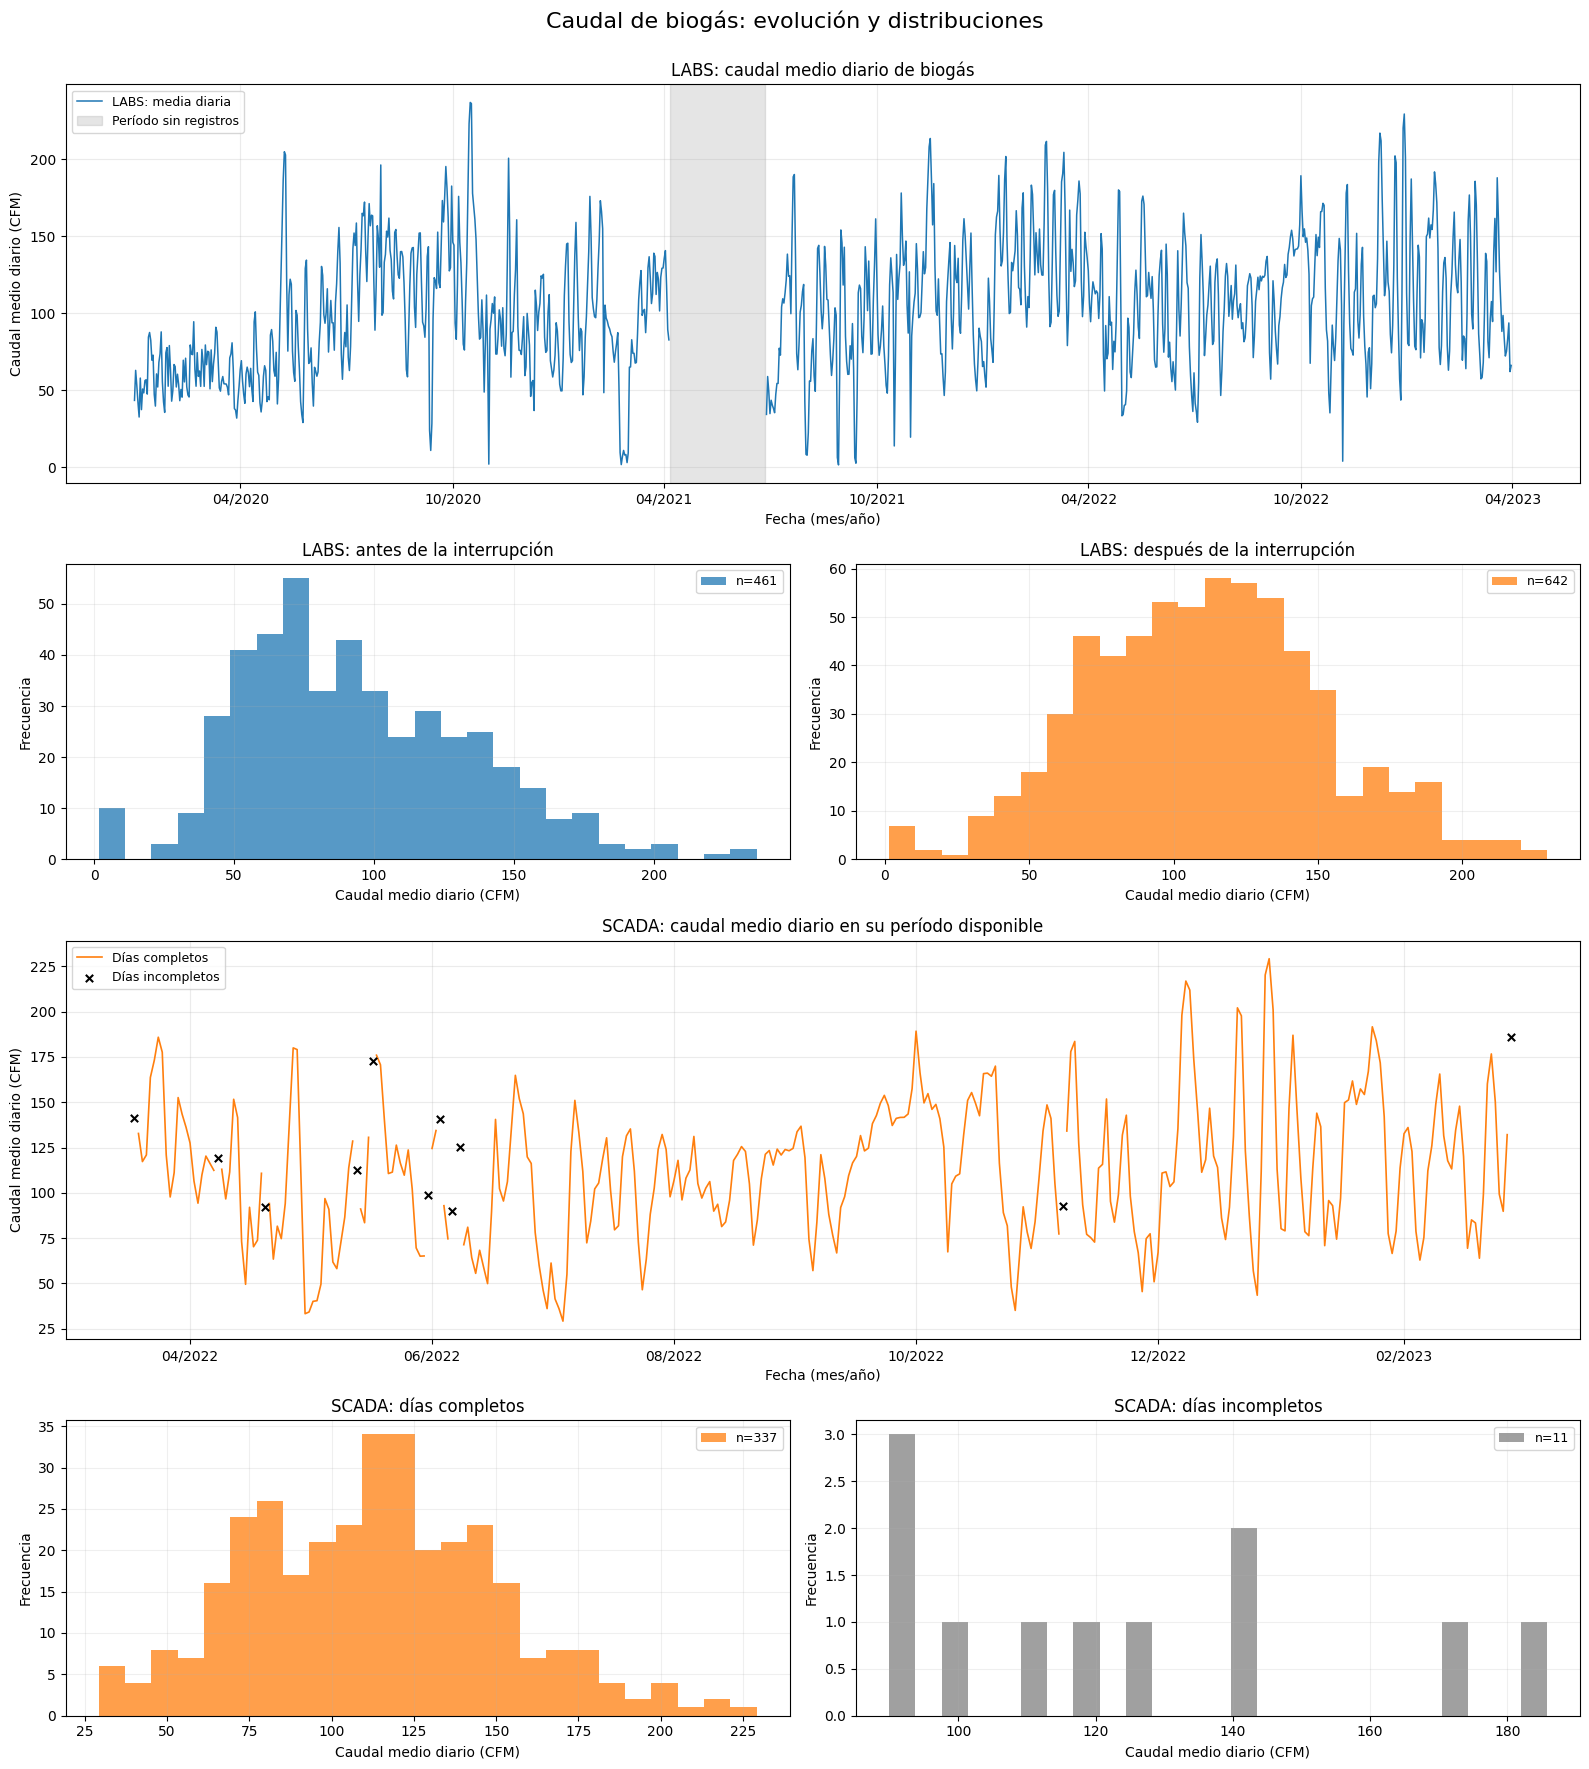

In [5]:
fig = plt.figure(figsize=(16, 18))
rejilla = fig.add_gridspec(4, 2, height_ratios=[1.35, 1, 1.35, 1])

eje_lab = fig.add_subplot(rejilla[0, :])
eje_lab.plot(lab_graficos.index, lab_graficos['Biogas'], color='tab:blue', linewidth=1.1, label='LABS: media diaria')
eje_lab.axvspan(inicio_interrupcion, fin_interrupcion, color='gray', alpha=0.2, label='Período sin registros')
eje_lab.set_title('LABS: caudal medio diario de biogás')
eje_lab.set_ylabel('Caudal medio diario (CFM)')
formato_fecha(eje_lab)

histograma_unico(fig.add_subplot(rejilla[1, 0]), lab_antes, 'Biogas', 'tab:blue', 'LABS: antes de la interrupción', 'Caudal medio diario (CFM)')
histograma_unico(fig.add_subplot(rejilla[1, 1]), lab_despues, 'Biogas', 'tab:orange', 'LABS: después de la interrupción', 'Caudal medio diario (CFM)')

eje_scada = fig.add_subplot(rejilla[2, :])
eje_scada.plot(scada_completo.index, scada_completo, color='tab:orange', linewidth=1.2, label='Días completos')
eje_scada.scatter(scada_parcial.index, scada_parcial, color='black', marker='x', s=28, label='Días incompletos', zorder=3)
eje_scada.set_title('SCADA: caudal medio diario en su período disponible')
eje_scada.set_ylabel('Caudal medio diario (CFM)')
formato_fecha(eje_scada, intervalo=2)

completos = scada_diario.loc[scada_diario['count'] == 1440].copy()
incompletos = scada_diario.loc[(scada_diario['count'] > 0) & (scada_diario['count'] < 1440)].copy()
histograma_unico(fig.add_subplot(rejilla[3, 0]), completos, 'mean', 'tab:orange', 'SCADA: días completos', 'Caudal medio diario (CFM)')
histograma_unico(fig.add_subplot(rejilla[3, 1]), incompletos, 'mean', 'gray', 'SCADA: días incompletos', 'Caudal medio diario (CFM)')

fig.suptitle('Caudal de biogás: evolución y distribuciones', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(carpeta_graficos / '01_biogas.png', dpi=160, bbox_inches='tight')
plt.show()


### Volúmenes diarios de alimentación

Los digestores reciben como materia prima **lodo primario (PS)**, **lodo biológico excedente espesado (TWAS)** y **residuos orgánicos de alta carga (HSW)**. Según el artículo, el tanque HSW también recibe **grasas y aceites (FOG)** de fuentes comerciales y residuos orgánicos de industrias de alimentos y piensos después de retirar sus envases. La mezcla HSW se mantiene agitada y se dosifica a los digestores junto con PS y TWAS.

A continuación, reviso por separado los volúmenes diarios de **TWAS, PS y HSW.** Son valores conjuntos de alimentación de la planta y no volúmenes separados por digestor. No sumo `FOG_gal` porque representa el volumen recibido en la instalación y no demuestra que esa misma cantidad se alimentara a los digestores el mismo día. Cada serie temporal aparece acompañada por su distribución antes y después de la interrupción de LABS.

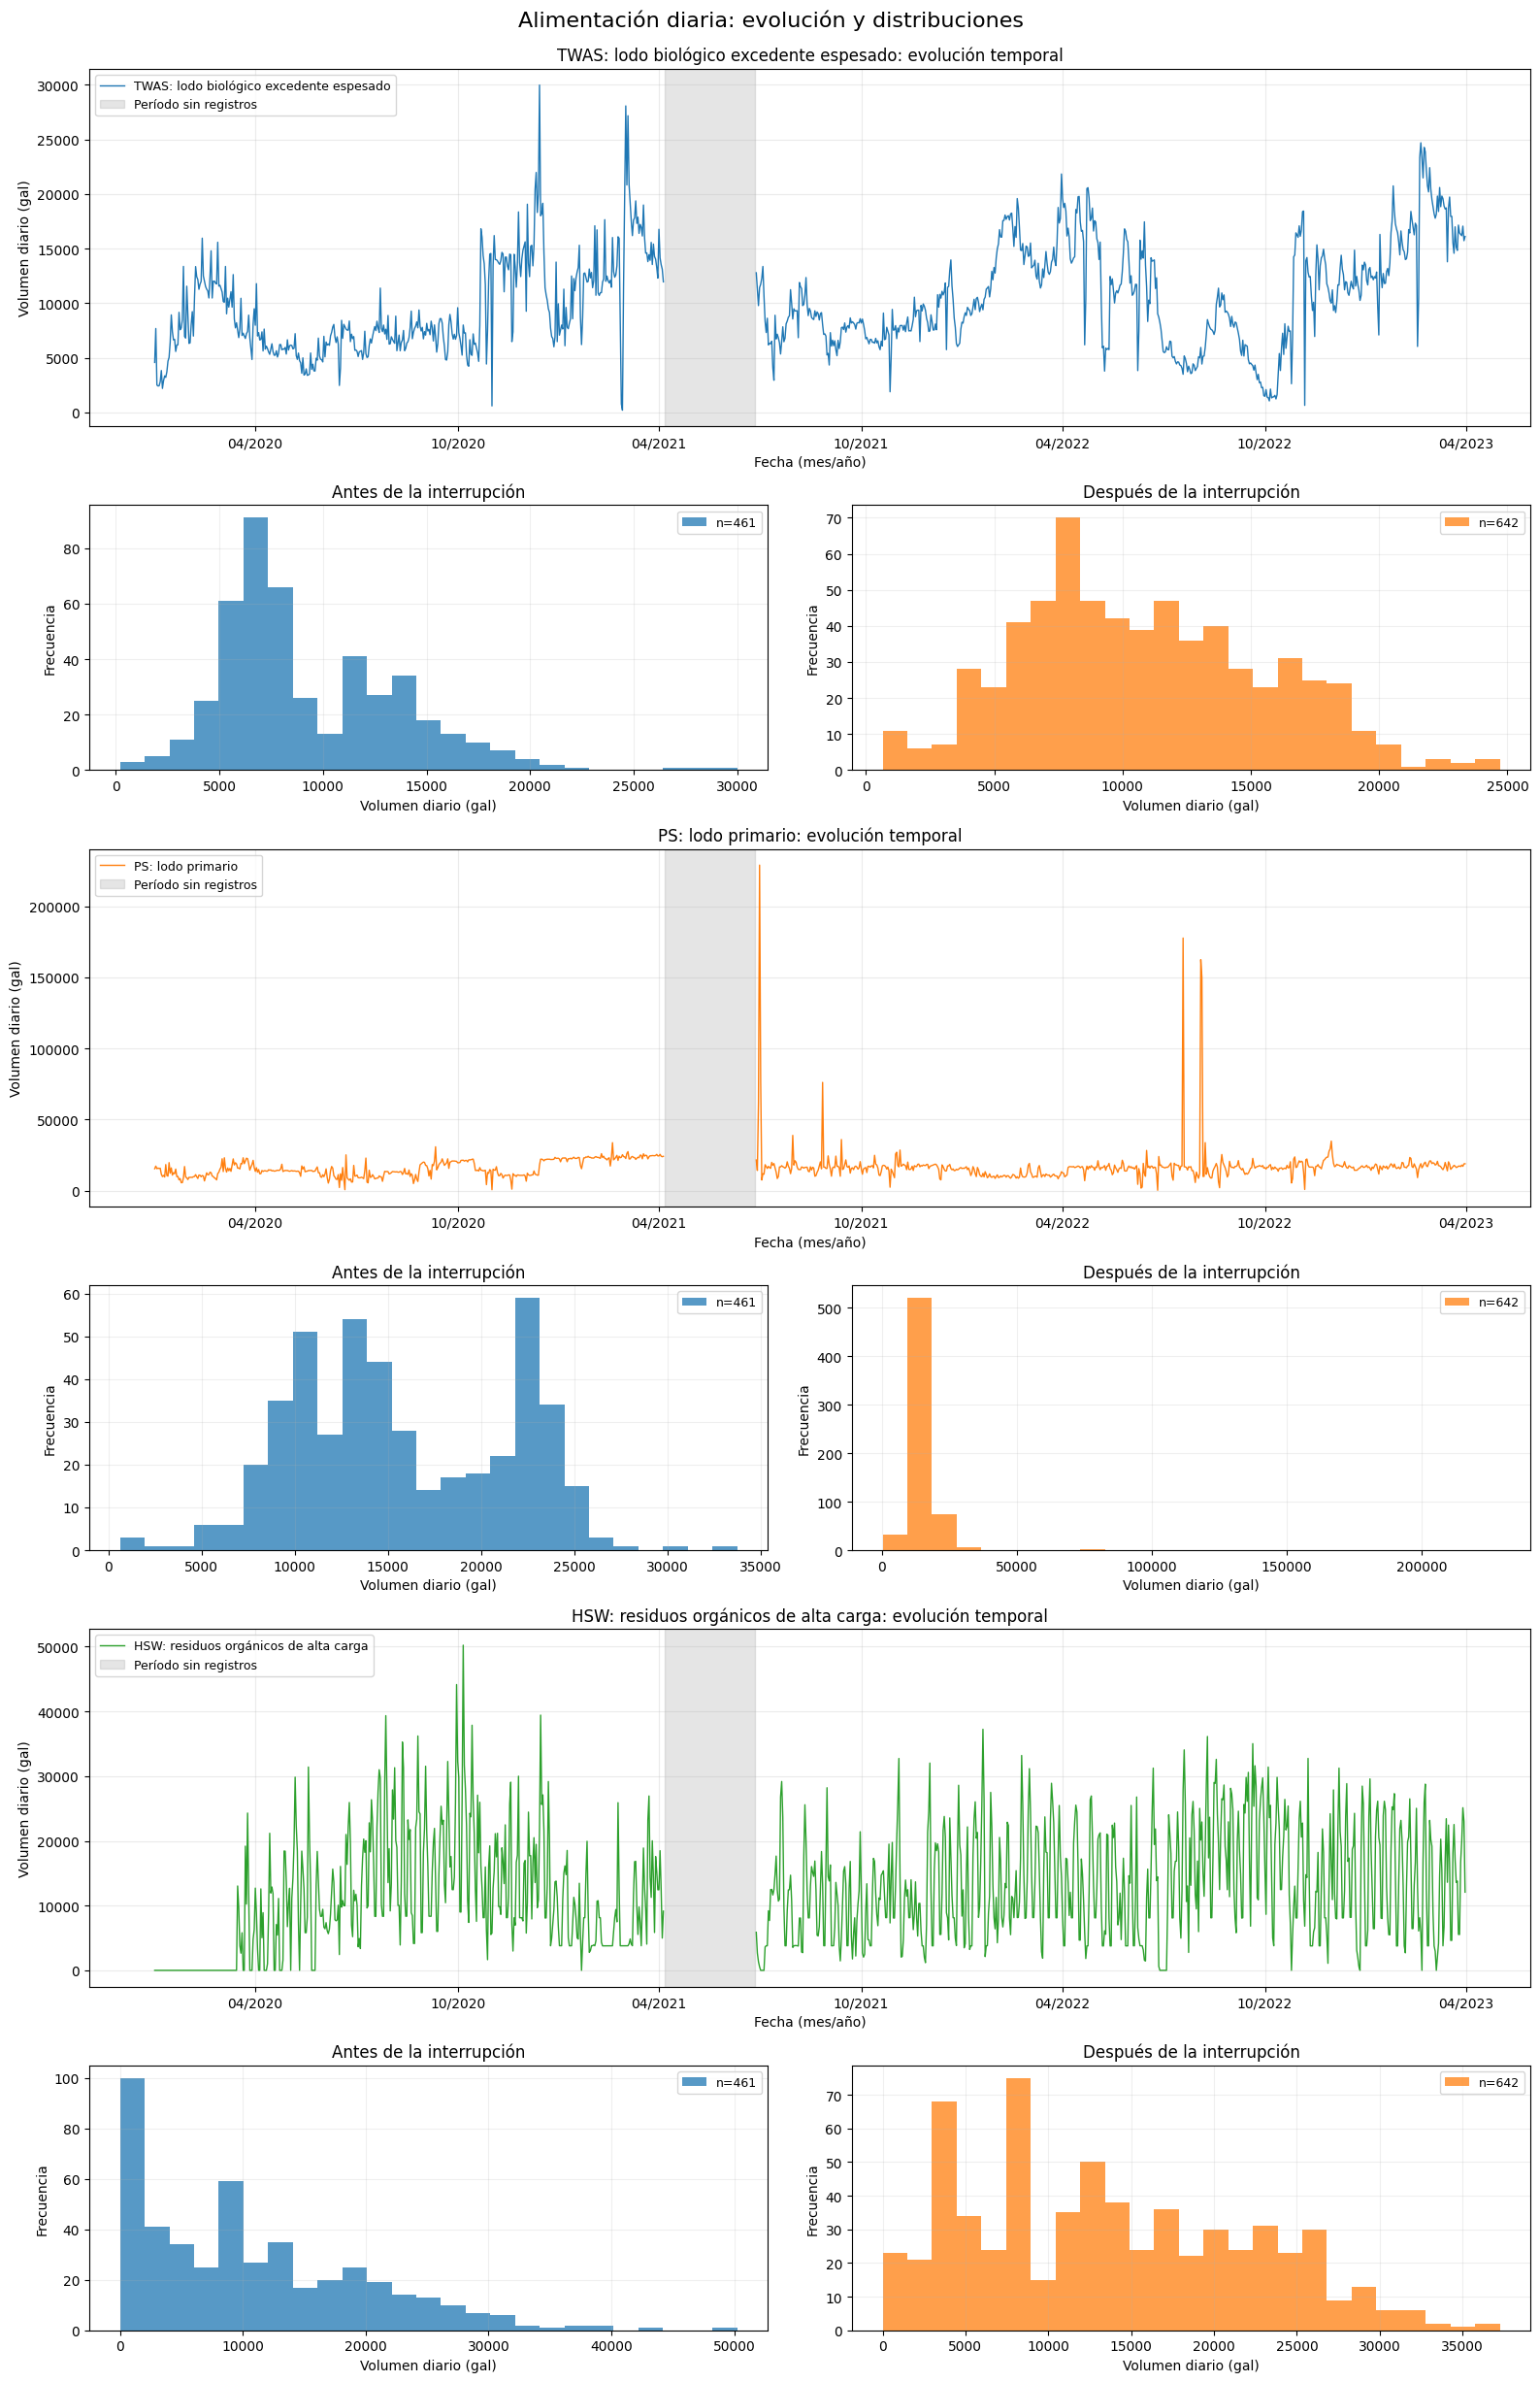

In [6]:
fig = plt.figure(figsize=(16, 25))
rejilla = fig.add_gridspec(6, 2, height_ratios=[1.35, 1, 1.35, 1, 1.35, 1])
columnas = ['V-TWAS_gal', 'V-PS_gal', 'V-HSW_gal']
etiquetas = ['TWAS: lodo biológico excedente espesado', 'PS: lodo primario', 'HSW: residuos orgánicos de alta carga']
colores = ['tab:blue', 'tab:orange', 'tab:green']

for grupo, (columna, etiqueta, color) in enumerate(zip(columnas, etiquetas, colores)):
    fila_serie = grupo * 2
    fila_histogramas = fila_serie + 1
    eje_serie = fig.add_subplot(rejilla[fila_serie, :])
    eje_serie.plot(lab_graficos.index, lab_graficos[columna], color=color, linewidth=1, label=etiqueta)
    eje_serie.axvspan(inicio_interrupcion, fin_interrupcion, color='gray', alpha=0.2, label='Período sin registros')
    eje_serie.set_title(f'{etiqueta}: evolución temporal')
    eje_serie.set_ylabel('Volumen diario (gal)')
    formato_fecha(eje_serie)
    histograma_unico(fig.add_subplot(rejilla[fila_histogramas, 0]), lab_antes, columna, 'tab:blue', 'Antes de la interrupción', 'Volumen diario (gal)')
    histograma_unico(fig.add_subplot(rejilla[fila_histogramas, 1]), lab_despues, columna, 'tab:orange', 'Después de la interrupción', 'Volumen diario (gal)')

fig.suptitle('Alimentación diaria: evolución y distribuciones', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(carpeta_graficos / '02_alimentacion.png', dpi=160, bbox_inches='tight')
plt.show()


### Temperatura y pH de los digestores

A continuación, comparo la temperatura y el pH de los digestores 1 y 2 usando LABS. Mantengo la temperatura en °F, como aparece en la fuente, y dentro del análisis agrego entre paréntesis su equivalencia en °C. También dejo visibles los datos ausentes. A la derecha presento un histograma independiente para cada digestor, separando los registros anteriores y posteriores a la interrupción. Estos gráficos permiten observar cambios en la distribución, pero por sí solos no confirman una falla del proceso.

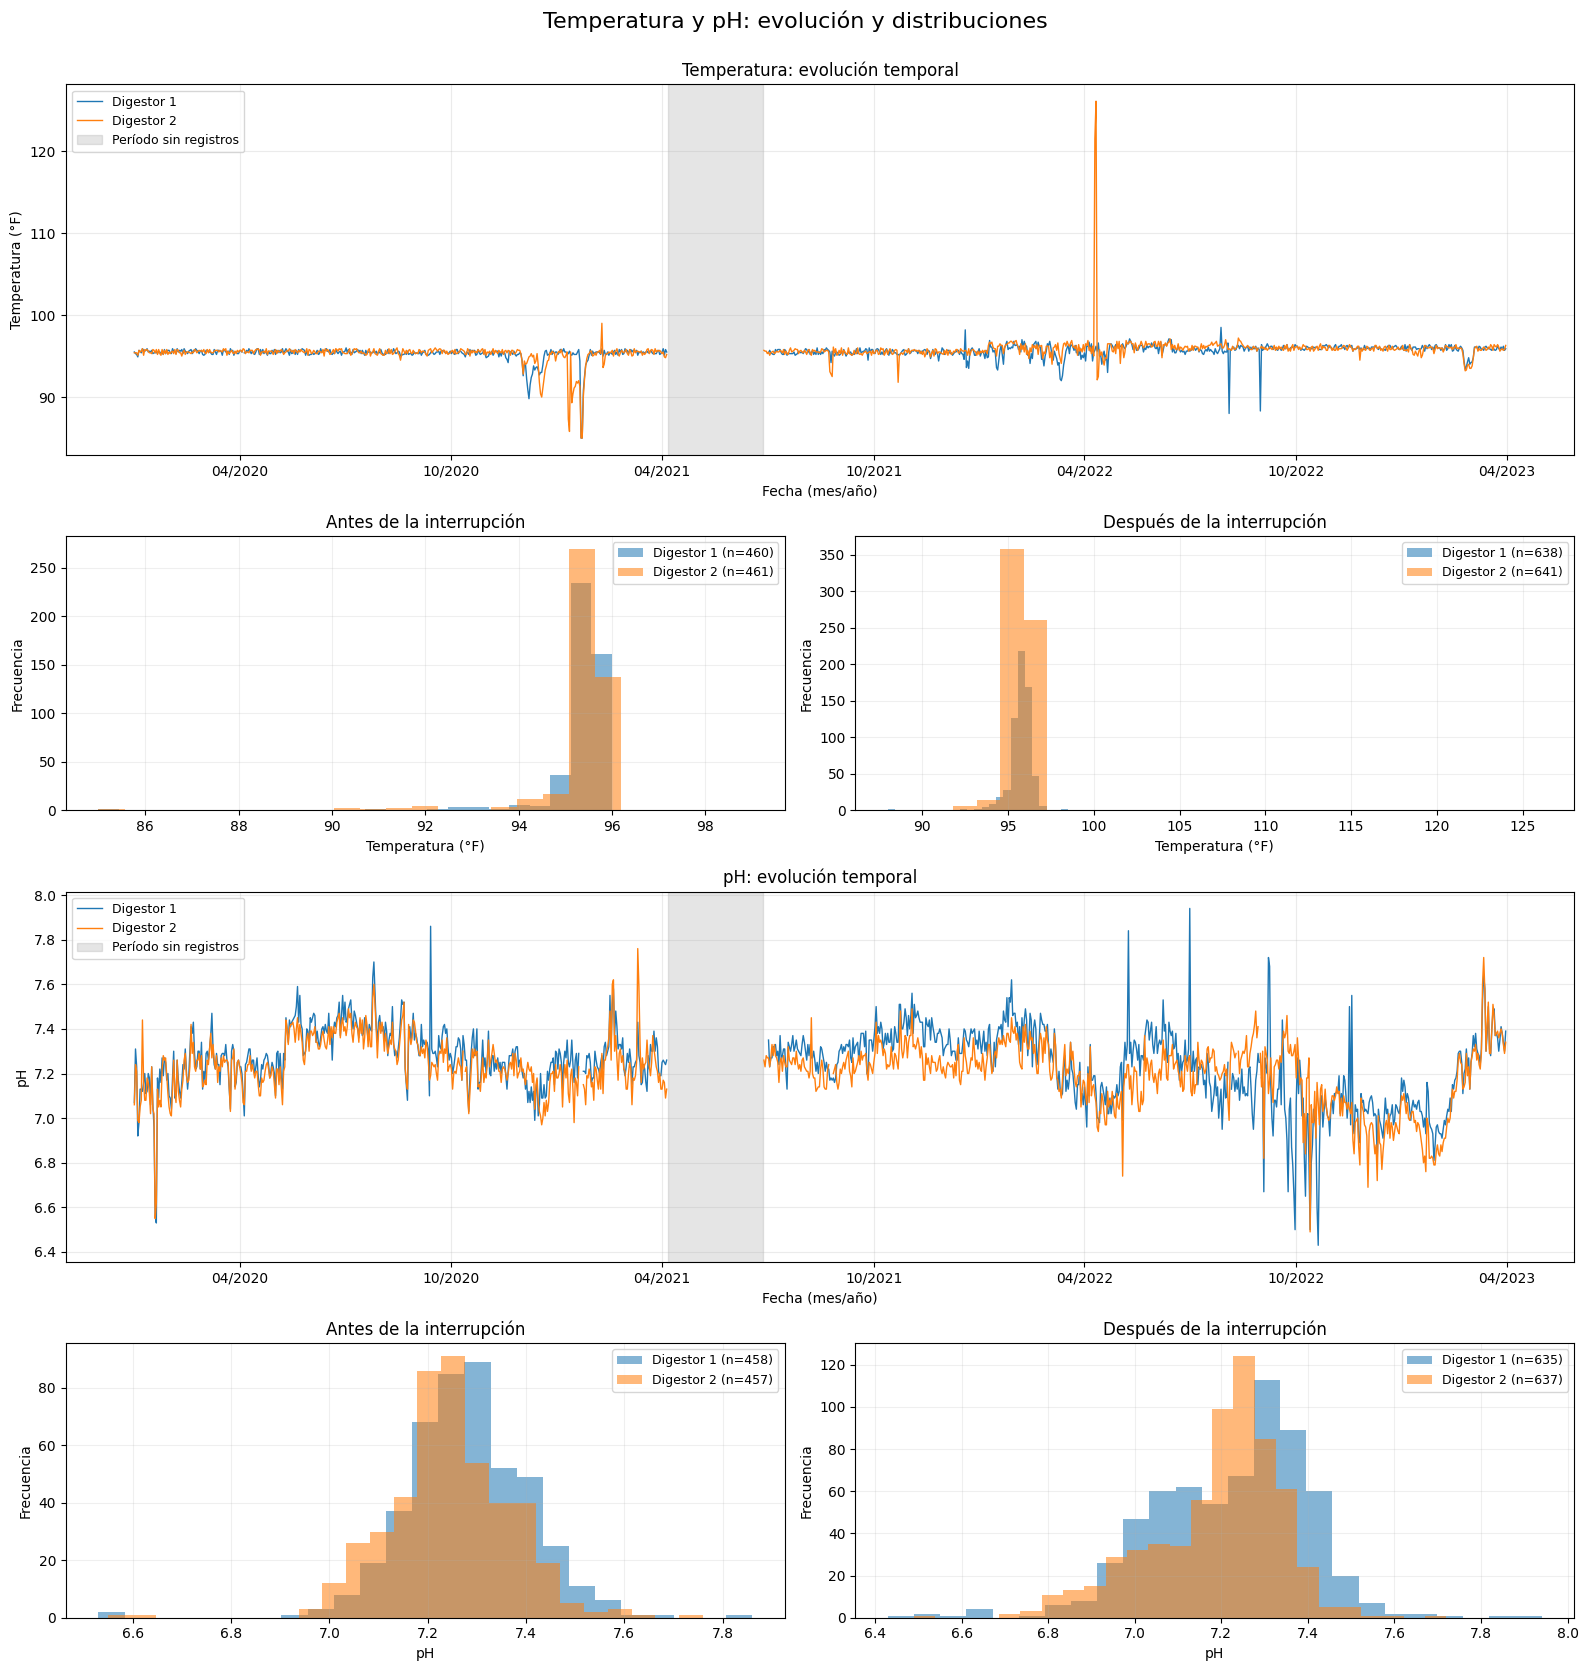

In [7]:
fig = plt.figure(figsize=(16, 17))
rejilla = fig.add_gridspec(4, 2, height_ratios=[1.35, 1, 1.35, 1])
configuracion = [
    ('Dig1-T_degF', 'Dig2-T_degF', 'Temperatura (°F)', 'Temperatura'),
    ('Dig1-pH', 'Dig2-pH', 'pH', 'pH')
]

for grupo, (columna_1, columna_2, unidad, titulo) in enumerate(configuracion):
    fila_serie = grupo * 2
    fila_histogramas = fila_serie + 1
    eje_serie = fig.add_subplot(rejilla[fila_serie, :])
    eje_serie.plot(lab_graficos.index, lab_graficos[columna_1], color='tab:blue', linewidth=1, label='Digestor 1')
    eje_serie.plot(lab_graficos.index, lab_graficos[columna_2], color='tab:orange', linewidth=1, label='Digestor 2')
    eje_serie.axvspan(inicio_interrupcion, fin_interrupcion, color='gray', alpha=0.2, label='Período sin registros')
    eje_serie.set_title(f'{titulo}: evolución temporal')
    eje_serie.set_ylabel(unidad)
    formato_fecha(eje_serie)
    histograma_digestores(fig.add_subplot(rejilla[fila_histogramas, 0]), lab_antes, columna_1, columna_2, 'Antes de la interrupción', unidad)
    histograma_digestores(fig.add_subplot(rejilla[fila_histogramas, 1]), lab_despues, columna_1, columna_2, 'Después de la interrupción', unidad)

fig.suptitle('Temperatura y pH: evolución y distribuciones', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(carpeta_graficos / '03_condiciones.png', dpi=160, bbox_inches='tight')
plt.show()


### Variables de laboratorio relacionadas con la estabilidad

A continuación, se presentan los gráficos de los **ácidos grasos volátiles (AGV; VFA, por sus siglas en inglés)**, la **alcalinidad** y la **relación FOS/TAC**, que representa la relación entre los ácidos orgánicos volátiles y la capacidad alcalina total. Comparo ambos digestores y acompaño cada serie con histogramas anteriores y posteriores a la interrupción.

Conservo los valores ausentes sin interpolarlos y no aplico un umbral universal de estabilidad. Los dos períodos contienen diferente cantidad de días, por lo que la altura de las barras representa **frecuencia absoluta** y debe interpretarse junto con el número de observaciones indicado en cada leyenda.

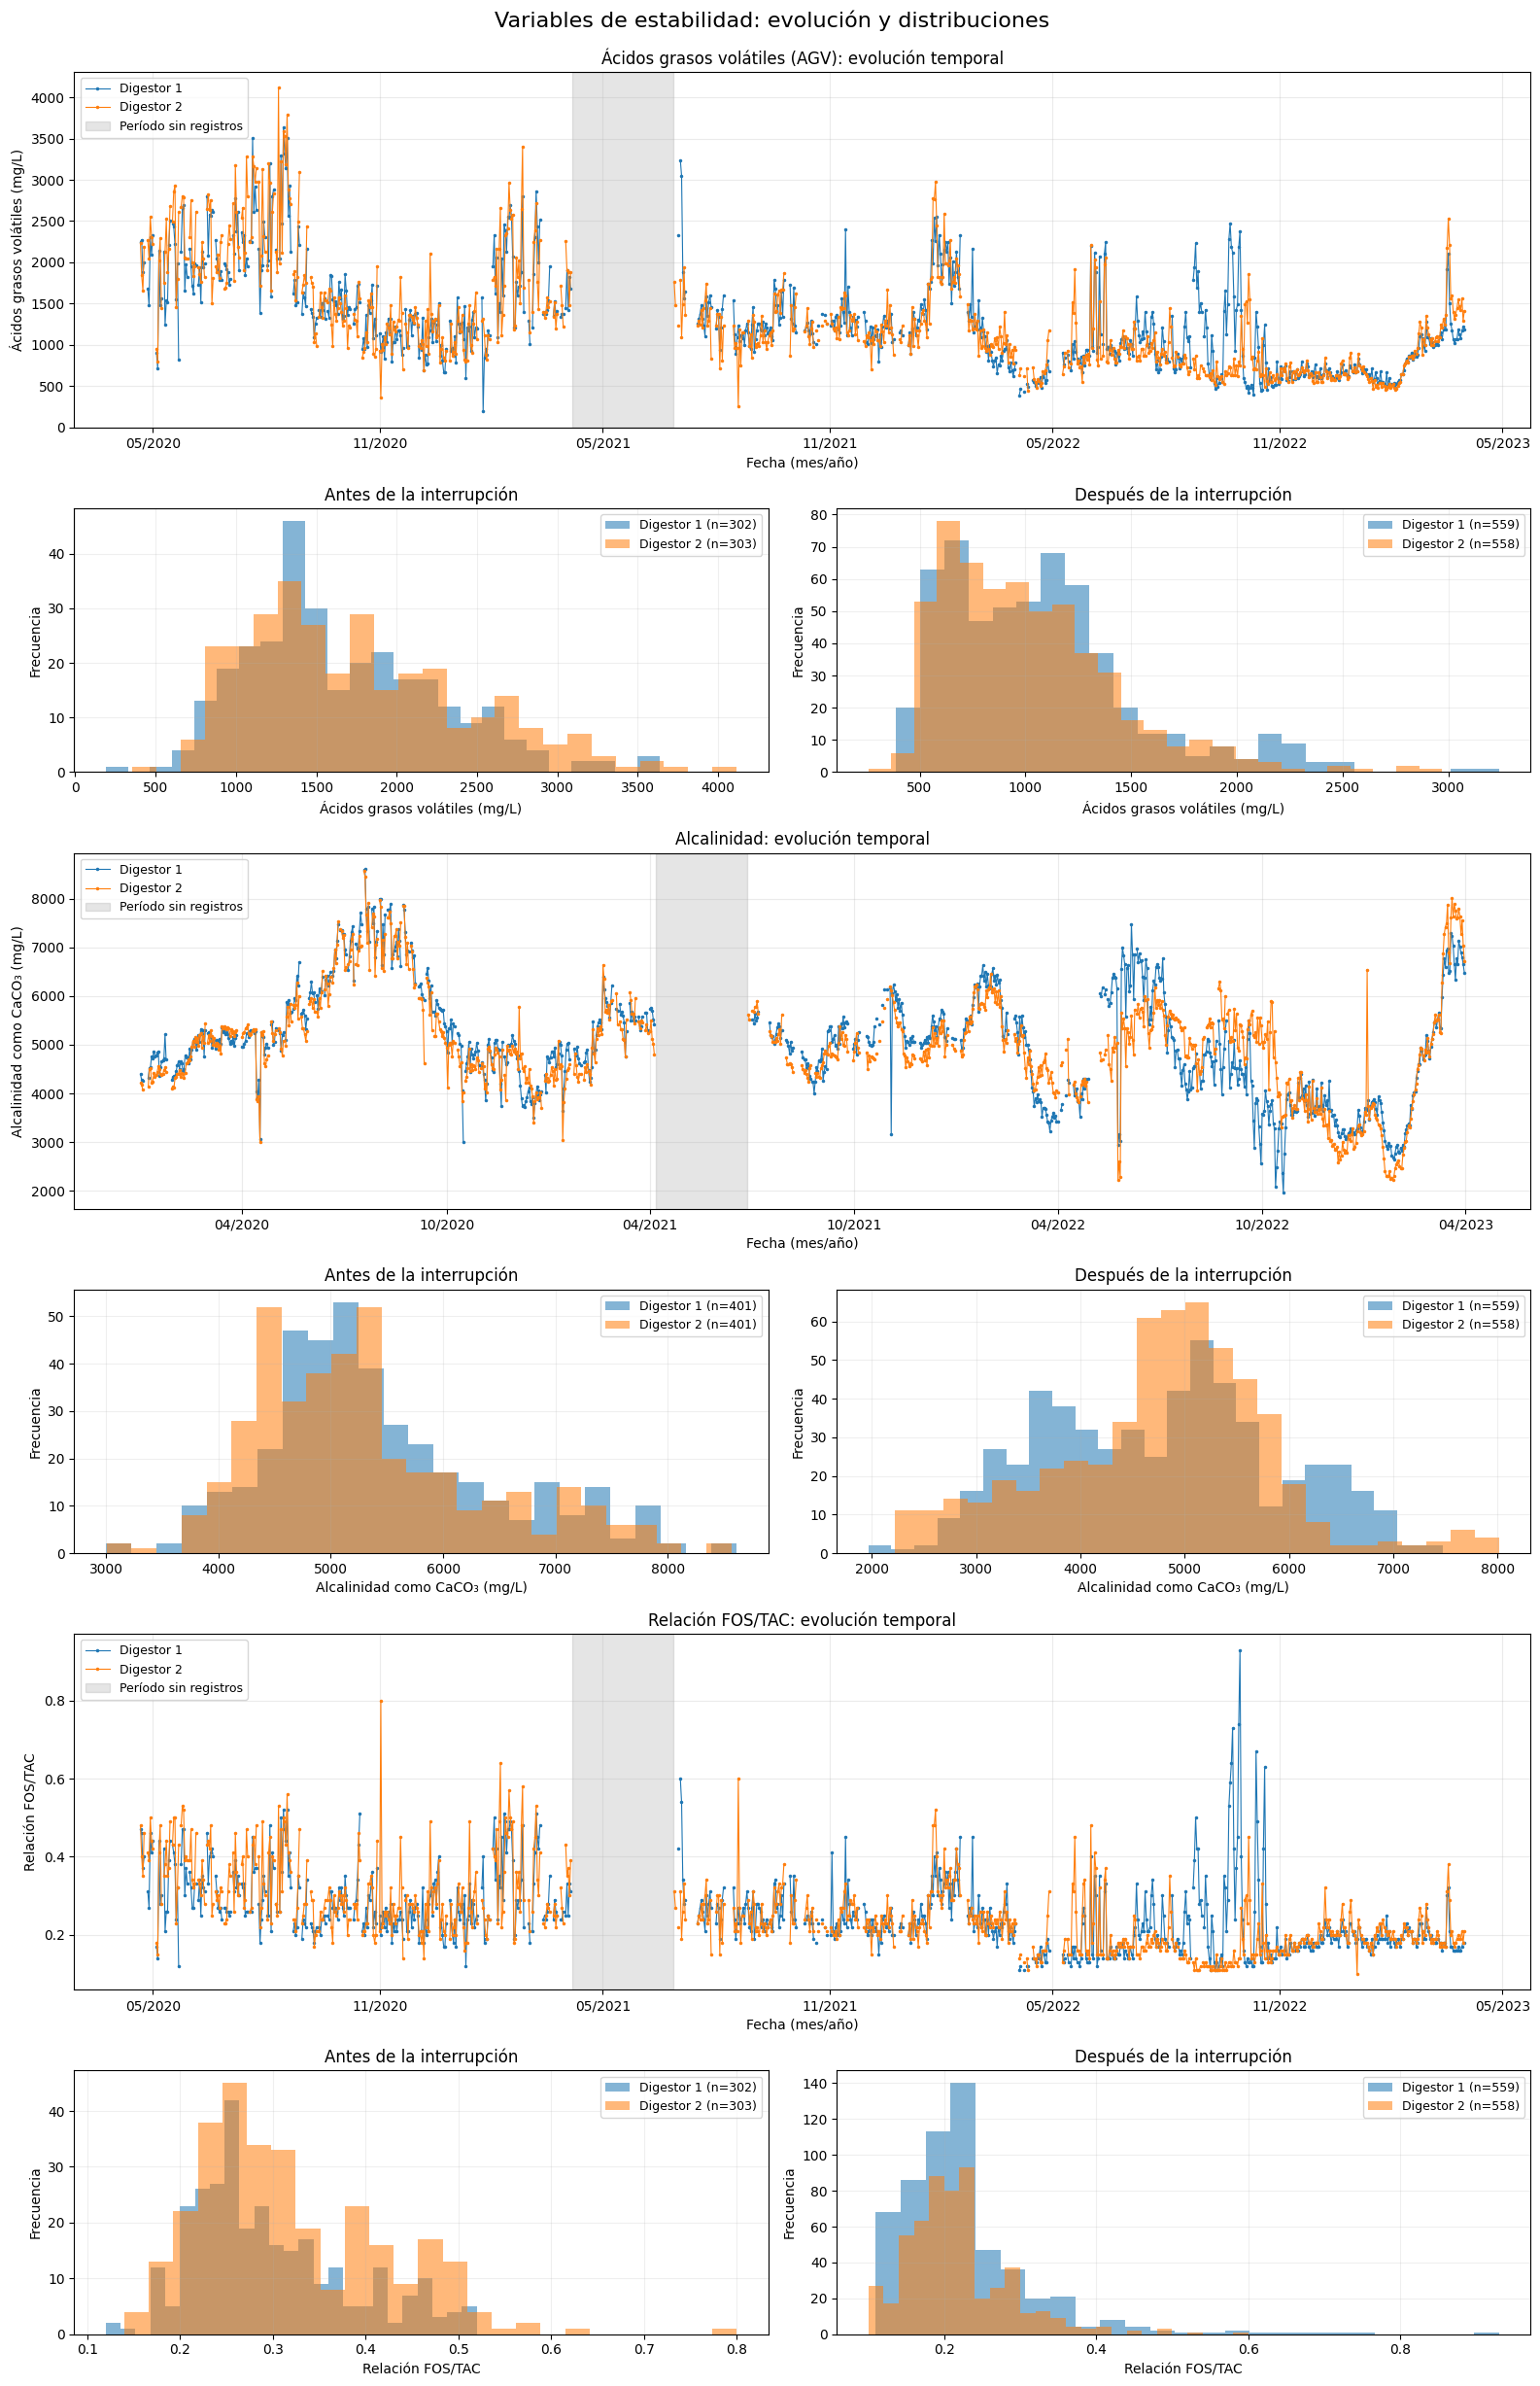

In [8]:
fig = plt.figure(figsize=(16, 25))
rejilla = fig.add_gridspec(6, 2, height_ratios=[1.35, 1, 1.35, 1, 1.35, 1])
configuracion = [
    ('Dig1-VFA_mgL', 'Dig2-VFA_mgL', 'Ácidos grasos volátiles (mg/L)', 'Ácidos grasos volátiles (AGV)'),
    ('Dig1-alk_mgL', 'Dig2-alk_mgL', 'Alcalinidad como CaCO₃ (mg/L)', 'Alcalinidad'),
    ('Dig1-FOS-TAC', 'Dig2-FOS-TAC', 'Relación FOS/TAC', 'Relación FOS/TAC')
]

for grupo, (columna_1, columna_2, unidad, titulo) in enumerate(configuracion):
    fila_serie = grupo * 2
    fila_histogramas = fila_serie + 1
    eje_serie = fig.add_subplot(rejilla[fila_serie, :])
    eje_serie.plot(lab_graficos.index, lab_graficos[columna_1], color='tab:blue', linewidth=0.8, marker='.', markersize=3, label='Digestor 1')
    eje_serie.plot(lab_graficos.index, lab_graficos[columna_2], color='tab:orange', linewidth=0.8, marker='.', markersize=3, label='Digestor 2')
    eje_serie.axvspan(inicio_interrupcion, fin_interrupcion, color='gray', alpha=0.2, label='Período sin registros')
    eje_serie.set_title(f'{titulo}: evolución temporal')
    eje_serie.set_ylabel(unidad)
    formato_fecha(eje_serie)
    histograma_digestores(fig.add_subplot(rejilla[fila_histogramas, 0]), lab_antes, columna_1, columna_2, 'Antes de la interrupción', unidad)
    histograma_digestores(fig.add_subplot(rejilla[fila_histogramas, 1]), lab_despues, columna_1, columna_2, 'Después de la interrupción', unidad)

fig.suptitle('Variables de estabilidad: evolución y distribuciones', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(carpeta_graficos / '04_estabilidad.png', dpi=160, bbox_inches='tight')
plt.show()


## Análisis de los gráficos

### 1. Producción de biogás

Al observar la evolución temporal del biogás en la tabla LABS, se puede ver que **la producción no se mantiene constante durante todo el período**, sino que atraviesa varias etapas. Durante los primeros meses de 2020 los valores son relativamente bajos y luego aumentan de forma progresiva hasta alcanzar un nivel más alto durante el tercer trimestre del mismo año. Posteriormente, la producción vuelve a disminuir y, entre finales de 2020 y los primeros meses de 2021, se mantiene la mayor parte del tiempo alrededor de un nivel intermedio, aunque continúan apareciendo variaciones diarias importantes.

Entre el **6 de abril y el 27 de junio de 2021** aparece una interrupción de **83 días sin registros en LABS**. Este espacio no debe interpretarse como una caída de la producción hasta cero, porque realmente no hay mediciones que permitan conocer qué ocurrió durante ese periodo. Por esta misma razón, tampoco sería correcto unir directamente el último punto anterior con el primero posterior o rellenar el hueco mediante una interpolación, porque la fuente no aporta información que permita justificarla.

Después de la interrupción, la producción vuelve inicialmente a un nivel similar al observado antes del hueco, pero desde finales de 2021 se aprecia un desplazamiento hacia valores más altos. Este cambio se ve con mayor claridad durante el primer trimestre de 2022. A partir de ese momento la señal continúa siendo variable, pero la mayor parte de los registros se mantiene alrededor de un nivel superior al del comienzo del experimento. La mediana pasa de **87,70 CFM antes de la interrupción a 111,25 CFM después**, lo que representa un aumento aproximado de **26,9 %**.

Los histogramas permiten ver este cambio desde otra perspectiva. Antes de la interrupción hay una mayor concentración de días alrededor de valores bajos e intermedios, mientras que después se incrementa la frecuencia de observaciones cercanas a **100-140 CFM**. Sin embargo, las dos distribuciones todavía se superponen y en ambos periodos aparecen días de producción muy baja y días con valores altos. Por lo tanto, **no se trata de dos comportamientos completamente separados**, sino de un cambio gradual en la zona donde se concentra la mayor parte de las mediciones.

La información SCADA permite revisar con más detalle una parte del segundo periodo, desde marzo de 2022 hasta febrero de 2023. En los **337 días con cobertura completa**, el promedio diario presenta una mediana de **112,16 CFM**, muy cercana al nivel central observado en LABS después de la interrupción. Aun así, la serie SCADA muestra fluctuaciones continuas, con medias diarias entre aproximadamente **29 y 229 CFM**. Los **11 días incompletos** fueron marcados por separado porque su promedio se calculó con menos de 1.440 minutos y no debe compararse exactamente de la misma manera que un día completo.

En general, ambas fuentes muestran que **el caudal de biogás posee continuidad temporal, pero también una variabilidad diaria considerable**. Además, esta medición corresponde al total de la planta y no a cada digestor por separado. Tampoco se dispone de la concentración de metano, por lo que en esta etapa puedo analizar y pronosticar el caudal total de biogás, pero no calcular directamente cuánto metano produjo cada digestor.

### 2. Volúmenes diarios de alimentación

Al revisar la alimentación se observa que los tres materiales no fueron agregados siempre en las mismas cantidades. Cada uno presenta cambios por etapas, lo que indica que **la planta fue modificando su régimen de alimentación a lo largo del tiempo**.

El volumen de **lodo activado residual espesado (TWAS)** comienza con valores relativamente moderados durante la primera mitad de 2020 y aumenta con mayor claridad hacia finales de ese año y comienzos de 2021. Después de la interrupción vuelve a disminuir durante algunos meses, aumenta nuevamente al inicio de 2022, presenta una caída marcada durante el tercer trimestre y termina el periodo con una recuperación. Su mediana aumenta de **7.785 a 10.238 galones diarios**, equivalente a un incremento aproximado de **31,5 %** después del hueco.

El **lodo primario (PS)** presenta un comportamiento diferente. Aunque la mayor parte de las observaciones se mantiene dentro de un rango relativamente definido, después de la interrupción aparecen algunos registros extremadamente altos. El caso más evidente corresponde al **1 de julio de 2021**, cuando se registraron **229.022 galones**. Este valor se aleja considerablemente del comportamiento habitual y también modifica la escala del histograma. La fuente no permite determinar si corresponde a una operación real, a una acumulación registrada en un solo día o a un problema de medición. Por esa razón, conservo el registro original y lo marco como ausente únicamente en la copia destinada al modelado. Sin contar únicamente con ese extremo, la distribución muestra un aumento más moderado: la mediana pasa de **14.329 a 16.277,5 galones diarios**, alrededor de **13,6 %**.

En el caso de los **residuos orgánicos de alta carga (HSW)**, los primeros registros de 2020 se encuentran en cero porque este material todavía no se había incorporado de forma regular. Posteriormente su utilización aumenta y la serie empieza a mostrar una alimentación mucho más variable, con días de poca o ninguna adición y otros con volúmenes elevados. Después del hueco la distribución se desplaza hacia cantidades mayores y su mediana aumenta de **8.669 a 12.483,5 galones diarios**, aproximadamente **44,0 %**.

Al observar de forma individual los histogramas de alimentación, se ve que el cambio no es igual para los tres materiales. En **TWAS**, antes de la interrupción el 50 % central de los registros se encuentra aproximadamente entre **6.280 y 12.305 galones**, con una mayor acumulación en la parte baja y una cola hacia los valores altos. Después del hueco, ese mismo 50 % central se desplaza hasta aproximadamente **7.332,5-14.066,75 galones** y la distribución se vuelve más equilibrada. Esto muestra que no solamente aumenta la mediana, sino que los volúmenes intermedios también pasan a concentrarse en un rango superior.

El histograma de **lodo primario (PS)** requiere una lectura diferente. Antes de la interrupción, se ven con claridad 3 valores cuya frecuencia se repite más veces, alrededor de los 11.000, los 14.000 y los 23.000 galones. Después se concentra en un intervalo más estrecho, cercano a **14.000,5-17.443,75 galones**, pero aparece una cola extremadamente larga hacia la derecha debido principalmente al registro de **229.022 galones**. Por esta razón, el aumento de la media y la gran dispersión del segundo periodo están fuertemente influenciados por unos pocos valores altos y no representan el comportamiento de la mayoría de los días.

En **HSW** el desplazamiento es más claro. Antes del hueco existen **96 días con volumen cero**, equivalentes aproximadamente al **20,8 %** del periodo, mientras que después solamente aparecen **15 días en cero**, cerca del **2,3 %**. Además, el 50 % central pasa de aproximadamente **3.792-16.573 galones** a **6.714,25-20.194 galones**. El histograma, por lo tanto, refleja tanto una mayor cantidad habitual de HSW como una incorporación mucho más constante de este material en la alimentación.

La altura de las barras debe interpretarse con cuidado porque existen **461 días antes del hueco y 642 después**. En otras palabras, una barra más alta no significa necesariamente una mayor proporción si el segundo periodo también contiene más observaciones. Aun así, la posición y la forma de las distribuciones confirman que TWAS y HSW se desplazan hacia rangos superiores, mientras que PS mantiene un centro relativamente definido acompañado por algunos registros extremos.

Al comparar estas señales con el biogás, se observa que el periodo posterior combina **una alimentación habitualmente mayor y una producción de biogás también más alta**. Esta coincidencia tiene sentido desde el punto de vista del proceso, pero todavía no demuestra que el aumento de una corriente específica sea la causa directa del incremento del biogás. Con estos datos no es posible atribuir causalidad a una corriente específica, porque intervienen los desfases temporales, la composición y el efecto combinado de los sustratos.

### 3. Temperatura y pH de los digestores

Las temperaturas de ambos digestores muestran el comportamiento más estable de todo el conjunto de variables analizadas. Durante casi todo el periodo se mantienen alrededor de **95-96 °F (35,0-35,6 °C)** y las dos líneas avanzan de forma muy similar. La mediana pasa de **95,4 a 95,8 °F (35,2 a 35,4 °C) en el Digestor 1** y de **95,5 a 95,8 °F (35,3 a 35,4 °C) en el Digestor 2**, por lo que el cambio entre los dos periodos es pequeño. Esta concentración también aparece claramente en los histogramas y es consistente con una operación predominantemente mesofílica.

Los histogramas permiten comprobar que esta estabilidad no depende solamente del promedio. Antes de la interrupción, el 50 % central de las temperaturas se encuentra entre **95,2 y 95,6 °F (35,1 y 35,3 °C) en el Digestor 1** y entre **95,3 y 95,7 °F (35,2 y 35,4 °C) en el Digestor 2**. Después, ambos intervalos se desplazan ligeramente hacia arriba, hasta **95,5-96,1 °F (35,3-35,6 °C)** y **95,6-96,2 °F (35,3-35,7 °C)**, respectivamente. Las barras permanecen muy concentradas alrededor de estos valores; por lo tanto, los extremos observados en la serie temporal corresponden a casos aislados y no a un cambio general de la temperatura de operación.

No obstante, aparecen algunos valores aislados que requieren un tratamiento explícito. El **21 de enero de 2021** ambos digestores registran **85 °F (29,4 °C)**, mientras que el **11 de abril de 2022** el Digestor 2 alcanza **126,1 °F (52,3 °C)** sin que el Digestor 1 muestre un cambio similar. Debido a que estos puntos se alejan del comportamiento general, no conviene eliminarlos automáticamente ni interpretarlos de inmediato como cambios reales del proceso. La fuente no permite distinguir si corresponden a una intervención, una lectura puntual del sensor o un error de registro. Para no imponer una interpretación, conservo los registros originales y marco esos tres valores como ausentes únicamente en la copia de modelado; la imputación posterior utiliza la mediana aprendida dentro de cada conjunto de entrenamiento.

El **pH** también permanece la mayor parte del tiempo en una zona cercana a la neutralidad y ligeramente alcalina. Durante 2020 ambos digestores presentan un incremento gradual hasta valores cercanos a **7,3-7,4** y posteriormente regresan a niveles un poco más bajos. Después de la interrupción se observa una recuperación inicial, pero a lo largo de 2022 aparece una disminución progresiva, especialmente durante el último trimestre, cuando las medianas se sitúan alrededor de **7,03 en el Digestor 1 y 7,01 en el Digestor 2**. Durante los primeros meses de 2023 el pH vuelve a aumentar parcialmente.

Los histogramas muestran que los valores de pH de ambos digestores se concentran en rangos muy parecidos, pero también permiten distinguir un cambio que la mediana por sí sola no muestra con claridad. Antes de la interrupción, el 50 % central se encuentra entre **7,21 y 7,36 en el Digestor 1** y entre **7,17 y 7,32 en el Digestor 2**. Después, los intervalos pasan a **7,10-7,35** y **7,11-7,28**, respectivamente. Es decir, la parte inferior de ambas distribuciones se desplaza hacia valores menores y el Digestor 1 presenta una dispersión algo más amplia. Aunque la mediana general solamente cambia de **7,28 a 7,26 en el Digestor 1** y de **7,24 a 7,22 en el Digestor 2**, el cambio más importante se encuentra en **la aparición más frecuente de valores bajos durante una parte de 2022 y su recuperación posterior**.

En conjunto, las dos variables muestran que los digestores operaron bajo condiciones térmicas muy similares y con un pH relativamente controlado. El comportamiento casi paralelo entre ambos equipos sugiere que varios cambios responden a condiciones compartidas de operación. Aun así, los valores aislados y los descensos de pH deben conservarse para contrastarlos posteriormente con la alimentación, el biogás y las variables de estabilidad.

### 4. Variables relacionadas con la estabilidad del proceso

Los **ácidos grasos volátiles (AGV; VFA, por sus siglas en inglés)** presentan una evolución diferente antes y después de la interrupción. Durante gran parte de 2020 se observan valores elevados y una variabilidad considerable, especialmente alrededor del tercer trimestre. Posteriormente disminuyen, vuelven a aumentar en algunos momentos de 2021 y, después del hueco, pasan a concentrarse con mayor frecuencia en valores más bajos. La mediana del Digestor 1 disminuye de **1.523 a 1.014 mg/L**, mientras que la del Digestor 2 pasa de **1.634,8 a 954 mg/L**.

Los histogramas de AGV confirman un desplazamiento completo de las distribuciones hacia la izquierda. Antes del hueco, el 50 % central se encuentra aproximadamente entre **1.245 y 2.041,88 mg/L en el Digestor 1** y entre **1.236,4 y 2.183 mg/L en el Digestor 2**. Después, estos intervalos disminuyen hasta **705,5-1.270 mg/L** y **694,25-1.228 mg/L**, respectivamente. Los valores altos no desaparecen por completo, pero pasan a formar una cola menos frecuente; por eso el cambio observado no depende únicamente de unos pocos puntos, sino de una reducción general en la concentración habitual de AGV.

La **alcalinidad**, expresada como CaCO₃, aumenta durante la primera mitad de 2020 y alcanza sus niveles más altos alrededor del tercer trimestre. Después disminuye, se recupera parcialmente y continúa mostrando ciclos a lo largo de 2021 y 2022. Hacia finales de 2022 se presenta una caída visible en ambos digestores y luego una recuperación parcial durante los primeros meses de 2023. Al comparar las distribuciones completas, la mediana baja de **5.210 a 4.869 mg/L en el Digestor 1** y de **5.154 a 4.869,69 mg/L en el Digestor 2**.

En los histogramas de alcalinidad también se aprecia el desplazamiento hacia valores menores, aunque las distribuciones continúan siendo amplias. Antes de la interrupción, el 50 % central se encuentra aproximadamente entre **4.768 y 5.928 mg/L en el Digestor 1** y entre **4.529,07 y 5.800 mg/L en el Digestor 2**. Después pasa a **3.829-5.501 mg/L** y **4.204,25-5.398,5 mg/L**. La disminución es especialmente visible en la parte baja del Digestor 1, mientras que el Digestor 2 conserva una distribución algo más concentrada. Esto indica que la alcalinidad posterior no solamente posee una mediana menor, sino también una mayor presencia de días con capacidad alcalina reducida.

Los histogramas de la relación **FOS/TAC**, que compara los ácidos orgánicos volátiles con la capacidad alcalina total, siguen en términos generales el cambio observado en los AGV. Antes de la interrupción, el 50 % central se encuentra entre **0,24 y 0,34 en el Digestor 1** y entre **0,24 y 0,39 en el Digestor 2**. Después, ambos intervalos se estrechan y se desplazan hacia abajo, hasta **0,17-0,25** y **0,17-0,24**, respectivamente. La mediana disminuye de **0,27 a 0,21 en el Digestor 1** y de **0,29 a 0,20 en el Digestor 2**. Aun así, las distribuciones posteriores mantienen una cola hacia la derecha debido a picos puntuales, como el valor de **0,93 registrado en el Digestor 1 el 30 de septiembre de 2022**. Por lo tanto, el comportamiento habitual es menor y más concentrado después del hueco, pero continúan existiendo episodios aislados, que interpreto junto con las mediciones cercanas.

Al observar las tres variables en conjunto, el periodo posterior al hueco presenta **menores concentraciones habituales de AGV y una relación FOS/TAC más baja**, aunque también posee una alcalinidad algo menor. Esto podría ser compatible con un cambio en la alimentación, una utilización más eficiente de los ácidos o un régimen operativo diferente. Sin embargo, no sería correcto afirmar únicamente con estas gráficas que el proceso mejoró o que permaneció estable, ya que faltan mediciones de laboratorio en determinados días y no se ha definido un umbral universal que permita clasificar cada registro.

También es importante observar que ambos digestores muestran movimientos parecidos. Esto refuerza la idea de que buena parte de la variación está asociada a cambios generales de la planta y no solamente a un evento aislado dentro de uno de los digestores. Durante el último trimestre de 2022 coinciden una reducción del pH y de la alcalinidad con valores relativamente bajos de AGV y FOS/TAC. Esa combinación no permite una explicación operacional concluyente por sí sola; su interpretación considera la alimentación, la continuidad de las mediciones y los posibles desfases entre variables.

### Conclusión del análisis gráfico

**Producción de biogás.** El segundo periodo presenta una producción habitual más alta: la mediana aumenta aproximadamente un **26,9 %**, y la distribución contiene más días alrededor de **100-140 CFM**. A nivel global, esto indica que la planta fue capaz de sostener un caudal de biogás superior después de la interrupción, aunque con una variabilidad diaria importante. Un aumento del caudal puede estar relacionado con una mayor cantidad de materia orgánica disponible y con una conversión biológica más activa, pero estos datos no permiten separar la contribución de cada digestor ni demostrar que el cambio provenga de una sola variable. Además, el hueco de 83 días divide la serie en dos regímenes y obliga a comprobar que los modelos no interpreten esa falta de registros como una caída real de la producción.

**Alimentación y carga disponible.** Después del hueco aumentan las cantidades habituales de **TWAS, lodo primario y HSW**, y el HSW se incorpora de una forma mucho más constante. En términos operativos, una mayor alimentación puede aportar más sustrato biodegradable y ayudar a explicar el aumento del biogás; sin embargo, el efecto no tiene por qué aparecer el mismo día y dependerá también de la composición del material y del tiempo que necesiten los microorganismos para degradarlo. El registro de **229.022 galones de lodo primario** se considera un valor atípico que no representa el régimen habitual de alimentación. Al preparar los datos para el modelado se evaluará su omisión o su sustitución por la mediana del periodo, siguiendo el mismo criterio planteado para los valores extremos de temperatura.

**Temperatura y pH.** La temperatura permanece concentrada alrededor de **95-96 °F (35,0-35,6 °C)** en ambos digestores, lo que representa una condición mesofílica bastante estable. Esta estabilidad es favorable porque evita cambios bruscos en la actividad de los microorganismos y permite interpretar que las variaciones del biogás no estuvieron acompañadas por un cambio térmico general. Los registros aislados de **85 °F (29,4 °C)** y **126,1 °F (52,3 °C)** no representan el comportamiento habitual y se tratan como atípicos en la copia de modelado. El pH, por su parte, se desplaza ligeramente hacia valores menores y muestra un descenso más visible a finales de 2022. Una reducción del pH puede indicar un cambio en el equilibrio entre la formación y el consumo de ácidos; no confirma por sí sola una inestabilidad, pero sí señala periodos que se interpretan junto con la alimentación, la alcalinidad, los AGV y la respuesta posterior del biogás.

**AGV, alcalinidad y relación FOS/TAC.** Después de la interrupción disminuyen los valores habituales de **AGV** y de **FOS/TAC**. En principio, una menor acumulación de ácidos puede ser compatible con una conversión más eficiente hacia biogás o con una carga que los digestores logran procesar mejor. Sin embargo, la **alcalinidad también disminuye**, lo que significa que existe una reserva amortiguadora menor para neutralizar futuros aumentos de acidez. Por esta razón, no interpretaré el descenso de todas estas variables como una mejora automática: el proceso parece trabajar con menos ácidos acumulados, pero también con una capacidad de protección algo menor, especialmente durante el tramo final de 2022. Como ambos digestores presentan movimientos muy parecidos, el cambio parece estar relacionado principalmente con condiciones compartidas de la planta. Por ello, el modelado estudia estas variables en conjunto y conserva los desfases temporales que permiten evaluar su capacidad para anticipar cambios en la producción de biogás.


# 2. Preparación de los datos para forecasting

Después de terminar el análisis exploratorio, preparo una copia de LABS para convertir la serie diaria en un problema de predicción supervisada. Mantengo los archivos originales sin modificaciones y documento cada decisión antes de entrenar los modelos.

En esta etapa voy a confirmar la continuidad temporal, retirar del modelado las variables con demasiados valores ausentes, identificar los registros atípicos que ya aparecieron durante el EDA y construir objetivos independientes para **D+1, D+3, D+7, D+15 y D+30**.


## 2.1 Confirmo la continuidad de la serie

La auditoría temporal ya se realizó durante la preparación de los gráficos. LABS contiene **1.103 días observados** entre el 1 de enero de 2020 y el 31 de marzo de 2023. Dentro de ese intervalo faltan **83 días consecutivos**, desde el 6 de abril hasta el 27 de junio de 2021.

No voy a rellenar este hueco ni a utilizar los días anteriores para estimar lo ocurrido dentro de él. Los retardos, las medias móviles y los objetivos se construirán por separado dentro de cada tramo observado, de forma que ninguna característica atraviese el periodo sin datos.

SCADA se conservará para un experimento diario independiente. No mezclaré directamente sus registros por minuto con las observaciones diarias de LABS.


## 2.2 Defino el tratamiento de ausentes y valores atípicos

Las variables de temperatura, pH, DBO de entrada y sólidos volátiles de TWAS tienen pocos valores ausentes. Para evitar que los extremos desplacen el valor utilizado para completarlas, usaré la **mediana calculada únicamente con los datos de entrenamiento**. De esta manera, la información de validación y prueba no participa en la preparación del modelo.

Las columnas `HSW-VS_percent`, `PS-VS_percent` y `HSW-COD_mgL` quedan fuera del modelado porque tienen entre 32 % y 43 % de valores ausentes. Las mantengo intactas en la tabla original, pero no las utilizaré como características.

Las variables de alcalinidad, AGV y FOS/TAC se conservarán en un segundo dataset. Para este modelo ampliado solamente utilizaré fechas que dispongan de las seis mediciones de estabilidad. Así podré comparar un modelo operativo con más observaciones y otro que incorpora información de laboratorio.

Los valores atípicos identificados durante el EDA no se eliminan de la fuente. En la copia de modelado los marco como ausentes para que reciban el mismo tratamiento mediante la mediana del entrenamiento.


In [9]:
# Creo una copia específica para modelado y mantengo df_lab sin modificaciones
df_lab_modelo = df_lab.copy()

# Excluyo del modelado las variables con más de 30 % de valores ausentes
columnas_excluidas = [
    'HSW-VS_percent',
    'PS-VS_percent',
    'HSW-COD_mgL'
]

# Estas variables se completarán con la mediana aprendida en entrenamiento
columnas_imputacion_mediana = [
    'Dig1-T_degF', 'Dig2-T_degF',
    'Dig1-pH', 'Dig2-pH',
    'BOD-influent_mgL', 'TWAS-VS_percent'
]

# Estas seis mediciones se utilizarán en el modelo ampliado de estabilidad
columnas_estabilidad = [
    'Dig1-alk_mgL', 'Dig2-alk_mgL',
    'Dig1-VFA_mgL', 'Dig2-VFA_mgL',
    'Dig1-FOS-TAC', 'Dig2-FOS-TAC'
]

# Marco los tres registros atípicos que ya fueron discutidos durante el EDA
mascara_temperatura_baja = (
    (df_lab_modelo['Fecha'] == pd.Timestamp('2021-01-21')) &
    ((df_lab_modelo['Dig1-T_degF'] == 85) | (df_lab_modelo['Dig2-T_degF'] == 85))
)
mascara_temperatura_alta = (
    (df_lab_modelo['Fecha'] == pd.Timestamp('2022-04-11')) &
    (df_lab_modelo['Dig2-T_degF'] == 126.1)
)
mascara_lodo_primario = (
    (df_lab_modelo['Fecha'] == pd.Timestamp('2021-07-01')) &
    (df_lab_modelo['V-PS_gal'] == 229022)
)

df_lab_modelo.loc[mascara_temperatura_baja, ['Dig1-T_degF', 'Dig2-T_degF']] = np.nan
df_lab_modelo.loc[mascara_temperatura_alta, 'Dig2-T_degF'] = np.nan
df_lab_modelo.loc[mascara_lodo_primario, 'V-PS_gal'] = pd.NA

# Compruebo cuántas filas pueden utilizar las seis variables de estabilidad
filas_estabilidad_completas = df_lab_modelo[columnas_estabilidad].notna().all(axis=1)

resumen_preparacion = pd.DataFrame({
    'Concepto': [
        'Filas originales de LABS',
        'Filas con las seis variables de estabilidad',
        'Filas sin alguna variable de estabilidad',
        'Porcentaje conservado para el modelo ampliado'
    ],
    'Resultado': [
        len(df_lab_modelo),
        int(filas_estabilidad_completas.sum()),
        int((~filas_estabilidad_completas).sum()),
        f'{filas_estabilidad_completas.mean() * 100:.2f} %'
    ]
})

display(resumen_preparacion)

display(pd.DataFrame({
    'Valores ausentes': df_lab_modelo[columnas_imputacion_mediana].isna().sum(),
    'Mediana descriptiva': df_lab_modelo[columnas_imputacion_mediana].median()
}))

print('Columnas excluidas del modelado:')
for columna in columnas_excluidas:
    print('-', columna)


,Concepto,Resultado
0,Filas originales de LABS,1103
1,Filas con las seis variables de estabilidad,855
2,Filas sin alguna variable de estabilidad,248
3,Porcentaje conservado para el modelo ampliado,77.52 %


,Valores ausentes,Mediana descriptiva
Dig1-T_degF,6,95.60
Dig2-T_degF,3,95.70
Dig1-pH,10,7.27
Dig2-pH,9,7.23
BOD-influent_mgL,2,450.00
TWAS-VS_percent,57,3.12


Columnas excluidas del modelado:
- HSW-VS_percent
- PS-VS_percent
- HSW-COD_mgL


### Resultado de la preparación inicial

Después de exigir que alcalinidad, AGV y FOS/TAC estén presentes simultáneamente, quedan **855 de las 1.103 filas originales**. Esto equivale al **77,52 %** de los registros y permite construir un modelo ampliado sin rellenar mediciones de laboratorio que no fueron realizadas.

La tabla operativa no pierde estas fechas. En ella conservaré el historial de biogás, los volúmenes de alimentación, las temperaturas, el pH, el tiempo de retención de sólidos y las condiciones generales de entrada. Los pocos valores ausentes y los registros atípicos marcados se completarán dentro de cada pipeline utilizando solamente la mediana del entrenamiento.


## 2.3 Construyo los objetivos y las características históricas

Cada fila representará la información disponible al terminar un día de operación. A partir de esa fecha crearé cinco objetivos independientes: el biogás observado 1, 3, 7, 15 y 30 días después.

También generaré retardos y resúmenes móviles del propio biogás. Estas características se calculan únicamente con el día actual y los días anteriores del mismo tramo continuo. No utilizaré ventanas centradas ni permitiré que una media móvil atraviese el hueco sin registros.

El primer dataset utilizará variables operativas. El segundo agregará alcalinidad, AGV y FOS/TAC solamente en las fechas completas.


In [10]:
# Ordeno nuevamente la copia y asigno un identificador a cada tramo continuo
df_lab_modelo = df_lab_modelo.sort_values('Fecha').reset_index(drop=True)
df_lab_modelo['Tramo'] = df_lab_modelo['Fecha'].diff().dt.days.ne(1).cumsum()

# Conservo el biogás del día de origen y creo retardos dentro de cada tramo
df_lab_modelo['Biogas_actual'] = df_lab_modelo['Biogas']
for retraso in [1, 2, 3, 7]:
    df_lab_modelo[f'Biogas_lag_{retraso}'] = (
        df_lab_modelo.groupby('Tramo')['Biogas'].shift(retraso)
    )

# Calculo medias y desviaciones usando únicamente el día actual y el pasado
for ventana in [3, 7]:
    df_lab_modelo[f'Biogas_media_{ventana}d'] = (
        df_lab_modelo.groupby('Tramo')['Biogas']
        .transform(lambda serie: serie.rolling(ventana, min_periods=ventana).mean())
    )
    df_lab_modelo[f'Biogas_desv_{ventana}d'] = (
        df_lab_modelo.groupby('Tramo')['Biogas']
        .transform(lambda serie: serie.rolling(ventana, min_periods=ventana).std())
    )

# Creo una serie con fecha como índice para buscar el objetivo exacto de cada horizonte
biogas_por_fecha = df_lab_modelo.set_index('Fecha')['Biogas']
horizontes = [1, 3, 7, 15, 30]

for horizonte in horizontes:
    fechas_objetivo = df_lab_modelo['Fecha'] + pd.to_timedelta(horizonte, unit='D')
    df_lab_modelo[f'Fecha_objetivo_D{horizonte}'] = fechas_objetivo
    df_lab_modelo[f'Biogas_D{horizonte}'] = biogas_por_fecha.reindex(fechas_objetivo).to_numpy()

# Defino las características del modelo operativo
caracteristicas_historicas = [
    'Biogas_actual',
    'Biogas_lag_1', 'Biogas_lag_2', 'Biogas_lag_3', 'Biogas_lag_7',
    'Biogas_media_3d', 'Biogas_media_7d',
    'Biogas_desv_3d', 'Biogas_desv_7d'
]

caracteristicas_operativas = [
    'V-TWAS_gal', 'V-PS_gal', 'V-HSW_gal',
    'Dig1-T_degF', 'Dig2-T_degF',
    'Dig1-pH', 'Dig2-pH',
    'SRT', 'Q-influent_MGD',
    'BOD-influent_mgL', 'TWAS-VS_percent'
]

variables_modelo_operativo = caracteristicas_historicas + caracteristicas_operativas
variables_modelo_estabilidad = variables_modelo_operativo + columnas_estabilidad

# Construyo un dataset operativo y otro de estabilidad para cada horizonte
datasets_lab = {}
resumen_horizontes = []

for horizonte in horizontes:
    columna_objetivo = f'Biogas_D{horizonte}'
    columna_fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    columnas_base = ['Fecha', columna_fecha_objetivo, columna_objetivo]

    operativo = df_lab_modelo[columnas_base + variables_modelo_operativo].copy()
    operativo = operativo.dropna(
        subset=caracteristicas_historicas + [columna_objetivo]
    ).reset_index(drop=True)

    estabilidad = df_lab_modelo[columnas_base + variables_modelo_estabilidad].copy()
    estabilidad = estabilidad.dropna(
        subset=caracteristicas_historicas + columnas_estabilidad + [columna_objetivo]
    ).reset_index(drop=True)

    datasets_lab[('Operativo', horizonte)] = operativo
    datasets_lab[('Estabilidad', horizonte)] = estabilidad

    resumen_horizontes.append({
        'Horizonte': f'D+{horizonte}',
        'Dataset operativo': len(operativo),
        'Dataset de estabilidad': len(estabilidad)
    })

display(pd.DataFrame(resumen_horizontes))

# Compruebo manualmente las fechas de las primeras filas del horizonte D+3
display(
    datasets_lab[('Operativo', 3)][
        ['Fecha', 'Fecha_objetivo_D3', 'Biogas_actual', 'Biogas_D3']
    ].head()
)


,Horizonte,Dataset operativo,Dataset de estabilidad
0,D+1,1087,850
1,D+3,1083,846
2,D+7,1075,839
3,D+15,1059,825
4,D+30,1029,799


,Fecha,Fecha_objetivo_D3,Biogas_actual,Biogas_D3
0,2020-01-08,2020-01-11,50.7,56.7
1,2020-01-09,2020-01-12,48.2,47.4
2,2020-01-10,2020-01-13,56.2,84.4
3,2020-01-11,2020-01-14,56.7,87.4
4,2020-01-12,2020-01-15,47.4,82.3


## 2.4 Separo entrenamiento, validación y prueba respetando el tiempo

La división se realizará con la fecha objetivo, no de forma aleatoria. El entrenamiento termina el 31 de marzo de 2022, la validación comprende desde abril hasta septiembre de 2022 y la prueba final comienza el 1 de octubre de 2022.

Esta separación deja dos periodos futuros completos para comparar los modelos. La prueba permanecerá reservada hasta que haya escogido las variables, el algoritmo y sus parámetros utilizando únicamente entrenamiento y validación.


In [11]:
# Defino cortes temporales fijos para todos los horizontes
fin_entrenamiento = pd.Timestamp('2022-03-31')
fin_validacion = pd.Timestamp('2022-09-30')

particiones_lab = {}
resumen_particiones = []

for (tipo_dataset, horizonte), tabla in datasets_lab.items():
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'

    entrenamiento = tabla[tabla[fecha_objetivo] <= fin_entrenamiento].copy()
    validacion = tabla[
        (tabla[fecha_objetivo] > fin_entrenamiento) &
        (tabla[fecha_objetivo] <= fin_validacion)
    ].copy()
    prueba = tabla[tabla[fecha_objetivo] > fin_validacion].copy()

    particiones_lab[(tipo_dataset, horizonte)] = {
        'Entrenamiento': entrenamiento,
        'Validación': validacion,
        'Prueba': prueba
    }

    resumen_particiones.append({
        'Dataset': tipo_dataset,
        'Horizonte': f'D+{horizonte}',
        'Entrenamiento': len(entrenamiento),
        'Validación': len(validacion),
        'Prueba': len(prueba)
    })

resumen_particiones = pd.DataFrame(resumen_particiones)
display(resumen_particiones)

print('La prueba permanece reservada. Todavía no se utilizará para escoger modelos.')


,Dataset,Horizonte,Entrenamiento,Validación,Prueba
0,Operativo,D+1,722,183,182
1,Estabilidad,D+1,513,155,182
2,Operativo,D+3,718,183,182
3,Estabilidad,D+3,509,155,182
4,Operativo,D+7,710,183,182
5,Estabilidad,D+7,502,155,182
6,Operativo,D+15,694,183,182
7,Estabilidad,D+15,488,155,182
8,Operativo,D+30,664,183,182
9,Estabilidad,D+30,462,155,182


La prueba permanece reservada. Todavía no se utilizará para escoger modelos.


# 3. Modelos de referencia

Antes de entrenar modelos de Machine Learning necesito comprobar cuánto se puede predecir utilizando reglas sencillas. La primera referencia repetirá el último caudal observado y la segunda utilizará la media de los últimos siete días.

Estas referencias son importantes porque el biogás tiene continuidad temporal. Un modelo más complejo solamente aportará valor si reduce el error obtenido por estas reglas sobre exactamente las mismas fechas.

Para comparar de forma justa el dataset operativo con el dataset de estabilidad, utilizaré las fechas de validación que ambos tienen disponibles.


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calcular_metricas(real, predicho):
    return {
        'MAE': mean_absolute_error(real, predicho),
        'RMSE': np.sqrt(mean_squared_error(real, predicho)),
        'R2': r2_score(real, predicho)
    }

resultados_validacion = []

for horizonte in horizontes:
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'

    # Tomo las fechas disponibles en el dataset de estabilidad como comparación común
    validacion_estabilidad = particiones_lab[('Estabilidad', horizonte)]['Validación']
    fechas_comunes = set(validacion_estabilidad[fecha_objetivo])

    for tipo_dataset in ['Operativo', 'Estabilidad']:
        validacion = particiones_lab[(tipo_dataset, horizonte)]['Validación']
        validacion = validacion[validacion[fecha_objetivo].isin(fechas_comunes)].copy()

        referencias = {
            'Persistencia': validacion['Biogas_actual'],
            'Media de 7 días': validacion['Biogas_media_7d']
        }

        for nombre, prediccion in referencias.items():
            metricas = calcular_metricas(validacion[objetivo], prediccion)
            resultados_validacion.append({
                'Dataset': tipo_dataset,
                'Horizonte': horizonte,
                'Modelo': nombre,
                'Configuración': 'Referencia simple',
                'Muestras': len(validacion),
                **metricas
            })

resultados_validacion = pd.DataFrame(resultados_validacion)
display(
    resultados_validacion[
        (resultados_validacion['Dataset'] == 'Operativo') &
        (resultados_validacion['Modelo'].isin(['Persistencia', 'Media de 7 días']))
    ][['Horizonte', 'Modelo', 'Muestras', 'MAE', 'RMSE', 'R2']]
    .round(3)
)


,Horizonte,Modelo,Muestras,MAE,RMSE,R2
0,1,Persistencia,155,17.344,22.313,0.486
1,1,Media de 7 días,155,23.886,31.020,0.007
4,3,Persistencia,155,33.065,43.258,-0.873
5,3,Media de 7 días,155,29.319,37.619,-0.417
8,7,Persistencia,155,34.321,44.266,-0.781
9,7,Media de 7 días,155,34.513,42.280,-0.625
12,15,Persistencia,155,32.026,38.937,-0.576
13,15,Media de 7 días,155,27.437,33.918,-0.196
16,30,Persistencia,155,40.255,49.866,-1.505
17,30,Media de 7 días,155,32.770,39.661,-0.585


# 4. Entrenamiento y comparación de modelos

Entrenaré cuatro algoritmos. La Regresión Lineal servirá como modelo interpretable. Random Forest permitirá representar relaciones no lineales. HistGradientBoosting y XGBoost construirán secuencias de árboles que corrigen progresivamente sus errores.

No realizaré una búsqueda masiva de parámetros. Probaré dos configuraciones moderadas para cada modelo de árboles y conservaré `random_state=12345` para que los resultados puedan reproducirse. La mediana se aprenderá dentro de cada pipeline usando únicamente el entrenamiento.


In [13]:
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

def crear_modelos():
    return {
        'Regresión lineal': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('escala', StandardScaler()),
            ('modelo', LinearRegression())
        ]),
        'Random Forest A': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('modelo', RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=2,
                max_features='sqrt',
                random_state=12345,
                n_jobs=-1
            ))
        ]),
        'Random Forest B': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('modelo', RandomForestRegressor(
                n_estimators=350,
                max_depth=12,
                min_samples_leaf=4,
                max_features=0.8,
                random_state=12345,
                n_jobs=-1
            ))
        ]),
        'HistGradientBoosting A': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('modelo', HistGradientBoostingRegressor(
                max_iter=250,
                learning_rate=0.05,
                max_leaf_nodes=15,
                l2_regularization=0.5,
                random_state=12345
            ))
        ]),
        'HistGradientBoosting B': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('modelo', HistGradientBoostingRegressor(
                max_iter=200,
                learning_rate=0.08,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=12345
            ))
        ]),
        'XGBoost A': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('modelo', XGBRegressor(
                n_estimators=400,
                max_depth=3,
                learning_rate=0.03,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='reg:squarederror',
                random_state=12345,
                n_jobs=-1
            ))
        ]),
        'XGBoost B': Pipeline([
            ('mediana', SimpleImputer(strategy='median')),
            ('modelo', XGBRegressor(
                n_estimators=250,
                max_depth=2,
                learning_rate=0.05,
                min_child_weight=5,
                subsample=0.9,
                colsample_bytree=0.9,
                objective='reg:squarederror',
                random_state=12345,
                n_jobs=-1
            ))
        ])
    }

modelos_disponibles = crear_modelos()
modelos_validacion = {}

for horizonte in horizontes:
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    fechas_comunes = set(
        particiones_lab[('Estabilidad', horizonte)]['Validación'][fecha_objetivo]
    )

    for tipo_dataset, variables in [
        ('Operativo', variables_modelo_operativo),
        ('Estabilidad', variables_modelo_estabilidad)
    ]:
        entrenamiento = particiones_lab[(tipo_dataset, horizonte)]['Entrenamiento']
        validacion = particiones_lab[(tipo_dataset, horizonte)]['Validación']
        validacion = validacion[validacion[fecha_objetivo].isin(fechas_comunes)].copy()

        X_entrenamiento = entrenamiento[variables]
        y_entrenamiento = entrenamiento[objetivo]
        X_validacion = validacion[variables]
        y_validacion = validacion[objetivo]

        for nombre_modelo, modelo_base in modelos_disponibles.items():
            modelo = clone(modelo_base)
            modelo.fit(X_entrenamiento, y_entrenamiento)
            prediccion = modelo.predict(X_validacion)
            metricas = calcular_metricas(y_validacion, prediccion)

            resultados_validacion.loc[len(resultados_validacion)] = {
                'Dataset': tipo_dataset,
                'Horizonte': horizonte,
                'Modelo': nombre_modelo,
                'Configuración': str(modelo.get_params()),
                'Muestras': len(validacion),
                **metricas
            }
            modelos_validacion[(tipo_dataset, horizonte, nombre_modelo)] = modelo

comparacion_validacion = resultados_validacion.sort_values(
    ['Horizonte', 'MAE', 'RMSE']
).reset_index(drop=True)

display(
    comparacion_validacion[
        ['Dataset', 'Horizonte', 'Modelo', 'Muestras', 'MAE', 'RMSE', 'R2']
    ].round(3)
)


,Dataset,Horizonte,Modelo,Muestras,MAE,RMSE,R2
0,Operativo,1,Regresión lineal,155,15.263,19.026,0.626
1,Operativo,1,Random Forest B,155,15.472,20.081,0.584
2,Operativo,1,Random Forest A,155,15.839,20.429,0.569
3,Estabilidad,1,Regresión lineal,155,16.015,20.661,0.559
4,Estabilidad,1,Random Forest B,155,16.221,20.828,0.552
...,...,...,...,...,...,...,...
85,Estabilidad,30,HistGradientBoosting B,155,32.311,41.038,-0.697
86,Operativo,30,Media de 7 días,155,32.770,39.661,-0.585
87,Estabilidad,30,Media de 7 días,155,32.770,39.661,-0.585
88,Operativo,30,Persistencia,155,40.255,49.866,-1.505


## 4.1 Selecciono el modelo con validación

Para cada horizonte escogeré la combinación de dataset, algoritmo y parámetros con menor MAE en validación. La prueba todavía no interviene en esta decisión.

También calcularé cuánto mejora el modelo seleccionado frente a la persistencia. Una mejora positiva significa que el modelo reduce el error absoluto medio; una mejora negativa indicaría que repetir el último valor continúa siendo una referencia más difícil de superar.


In [14]:
seleccion_validacion = []

for horizonte in horizontes:
    candidatos = comparacion_validacion[
        (comparacion_validacion['Horizonte'] == horizonte) &
        (~comparacion_validacion['Modelo'].isin(['Persistencia', 'Media de 7 días']))
    ].copy()
    mejor = candidatos.sort_values(['MAE', 'RMSE']).iloc[0]

    persistencia = comparacion_validacion[
        (comparacion_validacion['Horizonte'] == horizonte) &
        (comparacion_validacion['Dataset'] == mejor['Dataset']) &
        (comparacion_validacion['Modelo'] == 'Persistencia')
    ].iloc[0]

    mejora = (persistencia['MAE'] - mejor['MAE']) / persistencia['MAE'] * 100

    seleccion_validacion.append({
        'Horizonte': horizonte,
        'Dataset seleccionado': mejor['Dataset'],
        'Modelo seleccionado': mejor['Modelo'],
        'MAE validación': mejor['MAE'],
        'RMSE validación': mejor['RMSE'],
        'R2 validación': mejor['R2'],
        'MAE persistencia': persistencia['MAE'],
        'Mejora frente a persistencia (%)': mejora
    })

seleccion_validacion = pd.DataFrame(seleccion_validacion)
display(seleccion_validacion.round(3))


,Horizonte,Dataset seleccionado,Modelo seleccionado,MAE validación,RMSE validación,R2 validación,MAE persistencia,Mejora frente a persistencia (%)
0,1,Operativo,Regresión lineal,15.263,19.026,0.626,17.344,12.000
1,3,Operativo,Regresión lineal,24.432,31.814,-0.013,33.065,26.107
2,7,Estabilidad,Random Forest B,26.241,33.856,-0.042,34.321,23.543
3,15,Estabilidad,Regresión lineal,24.739,33.248,-0.149,32.026,22.755
4,30,Operativo,Random Forest A,26.602,33.979,-0.163,40.255,33.915


# 5. Evaluación final sobre el periodo de prueba

Después de fijar el modelo de cada horizonte, uniré entrenamiento y validación para volver a entrenarlo. La prueba se utilizará una sola vez y siempre se comparará con persistencia sobre las mismas fechas.

Además de MAE, RMSE y R², conservaré cada predicción individual para analizar posteriormente los errores y preparar la exportación a Power BI.


In [15]:
resultados_prueba = []
predicciones_prueba = []
modelos_finales = {}

for _, seleccion in seleccion_validacion.iterrows():
    horizonte = int(seleccion['Horizonte'])
    tipo_dataset = seleccion['Dataset seleccionado']
    nombre_modelo = seleccion['Modelo seleccionado']
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    variables = (
        variables_modelo_operativo
        if tipo_dataset == 'Operativo'
        else variables_modelo_estabilidad
    )

    partes = particiones_lab[(tipo_dataset, horizonte)]
    entrenamiento_ampliado = pd.concat(
        [partes['Entrenamiento'], partes['Validación']],
        ignore_index=True
    )
    prueba = partes['Prueba'].copy()

    modelo = clone(modelos_disponibles[nombre_modelo])
    modelo.fit(entrenamiento_ampliado[variables], entrenamiento_ampliado[objetivo])
    prediccion_modelo = modelo.predict(prueba[variables])
    prediccion_persistencia = prueba['Biogas_actual'].to_numpy()

    metricas_modelo = calcular_metricas(prueba[objetivo], prediccion_modelo)
    metricas_persistencia = calcular_metricas(prueba[objetivo], prediccion_persistencia)
    mejora = (
        (metricas_persistencia['MAE'] - metricas_modelo['MAE']) /
        metricas_persistencia['MAE'] * 100
    )

    resultados_prueba.append({
        'Horizonte': horizonte,
        'Dataset': tipo_dataset,
        'Modelo': nombre_modelo,
        'Muestras': len(prueba),
        **metricas_modelo,
        'MAE persistencia': metricas_persistencia['MAE'],
        'RMSE persistencia': metricas_persistencia['RMSE'],
        'R2 persistencia': metricas_persistencia['R2'],
        'Mejora MAE frente a persistencia (%)': mejora
    })

    for fecha_origen, fecha_destino, real, estimado, referencia in zip(
        prueba['Fecha'],
        prueba[fecha_objetivo],
        prueba[objetivo],
        prediccion_modelo,
        prediccion_persistencia
    ):
        predicciones_prueba.append({
            'fecha_origen': fecha_origen,
            'fecha_objetivo': fecha_destino,
            'horizonte_dias': horizonte,
            'dataset': tipo_dataset,
            'modelo': nombre_modelo,
            'real_CFM': real,
            'predicho_CFM': estimado,
            'persistencia_CFM': referencia,
            'error_CFM': real - estimado,
            'error_absoluto_CFM': abs(real - estimado),
            'conjunto': 'Prueba'
        })

    modelos_finales[horizonte] = modelo

resultados_prueba = pd.DataFrame(resultados_prueba).sort_values('Horizonte')
predicciones_prueba = pd.DataFrame(predicciones_prueba)

display(resultados_prueba.round(3))


,Horizonte,Dataset,Modelo,Muestras,MAE,RMSE,R2,MAE persistencia,RMSE persistencia,R2 persistencia,Mejora MAE frente a persistencia (%)
0,1,Operativo,Regresión lineal,182,20.581,26.445,0.600,24.902,32.101,0.411,17.353
1,3,Operativo,Regresión lineal,182,36.209,45.645,-0.191,48.165,61.046,-1.130,24.824
2,7,Estabilidad,Random Forest B,182,33.711,42.304,-0.023,43.666,54.210,-0.679,22.798
3,15,Estabilidad,Regresión lineal,182,40.871,51.117,-0.493,43.105,54.839,-0.719,5.182
4,30,Operativo,Random Forest A,182,34.712,43.386,-0.076,50.715,62.292,-1.218,31.555


# 6. Interpretación de los resultados

Además de comparar el modelo seleccionado con persistencia, incorporaré la media de los últimos siete días en la evaluación final. Después representaré las predicciones sobre el tiempo y revisaré cómo cambia el error según el horizonte.

En los gráficos mantendré las fechas objetivo en el eje horizontal. De esta manera, cada predicción queda colocada en el día que realmente intentaba estimar.


,Horizonte,Dataset,Modelo,Muestras,MAE,RMSE,R2,MAE persistencia,RMSE persistencia,R2 persistencia,Mejora MAE frente a persistencia (%),MAE media 7 días,RMSE media 7 días,R2 media 7 días
0,1,Operativo,Regresión lineal,182,20.581,26.445,0.600,24.902,32.101,0.411,17.353,34.757,42.981,-0.056
1,3,Operativo,Regresión lineal,182,36.209,45.645,-0.191,48.165,61.046,-1.130,24.824,40.722,49.300,-0.389
2,7,Estabilidad,Random Forest B,182,33.711,42.304,-0.023,43.666,54.210,-0.679,22.798,43.420,51.945,-0.542
3,15,Estabilidad,Regresión lineal,182,40.871,51.117,-0.493,43.105,54.839,-0.719,5.182,35.948,44.437,-0.129
4,30,Operativo,Random Forest A,182,34.712,43.386,-0.076,50.715,62.292,-1.218,31.555,39.675,48.857,-0.364


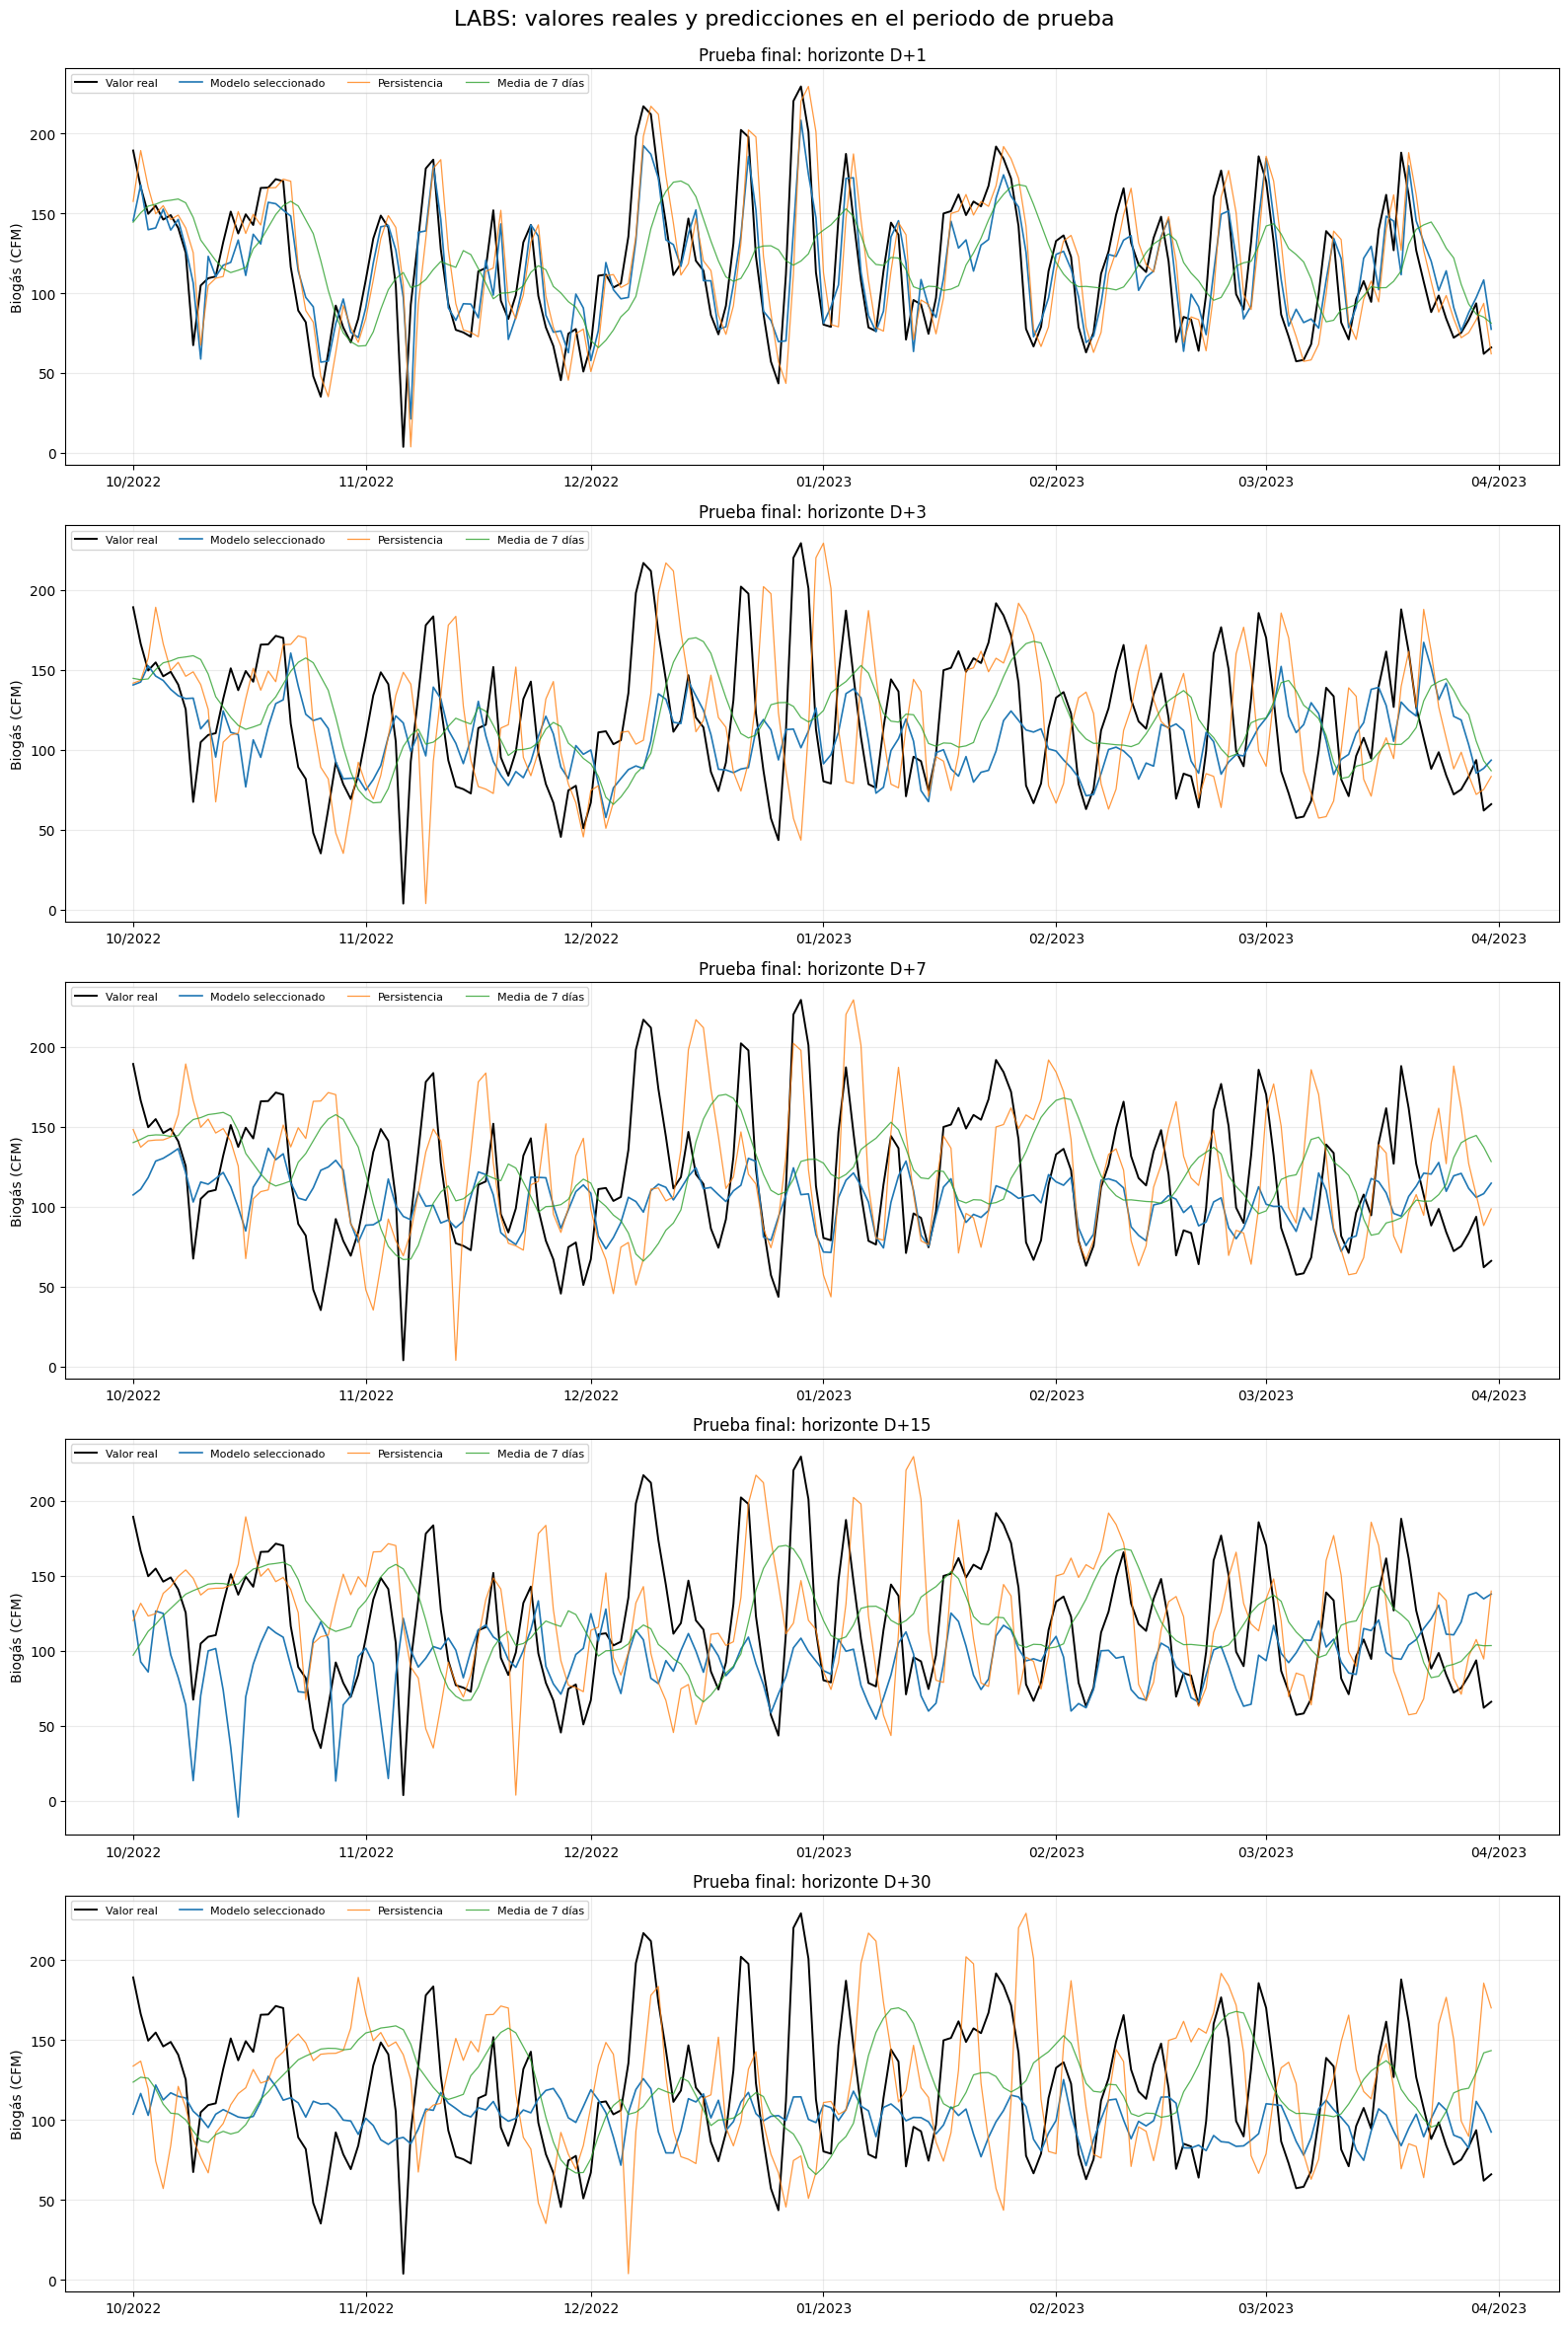

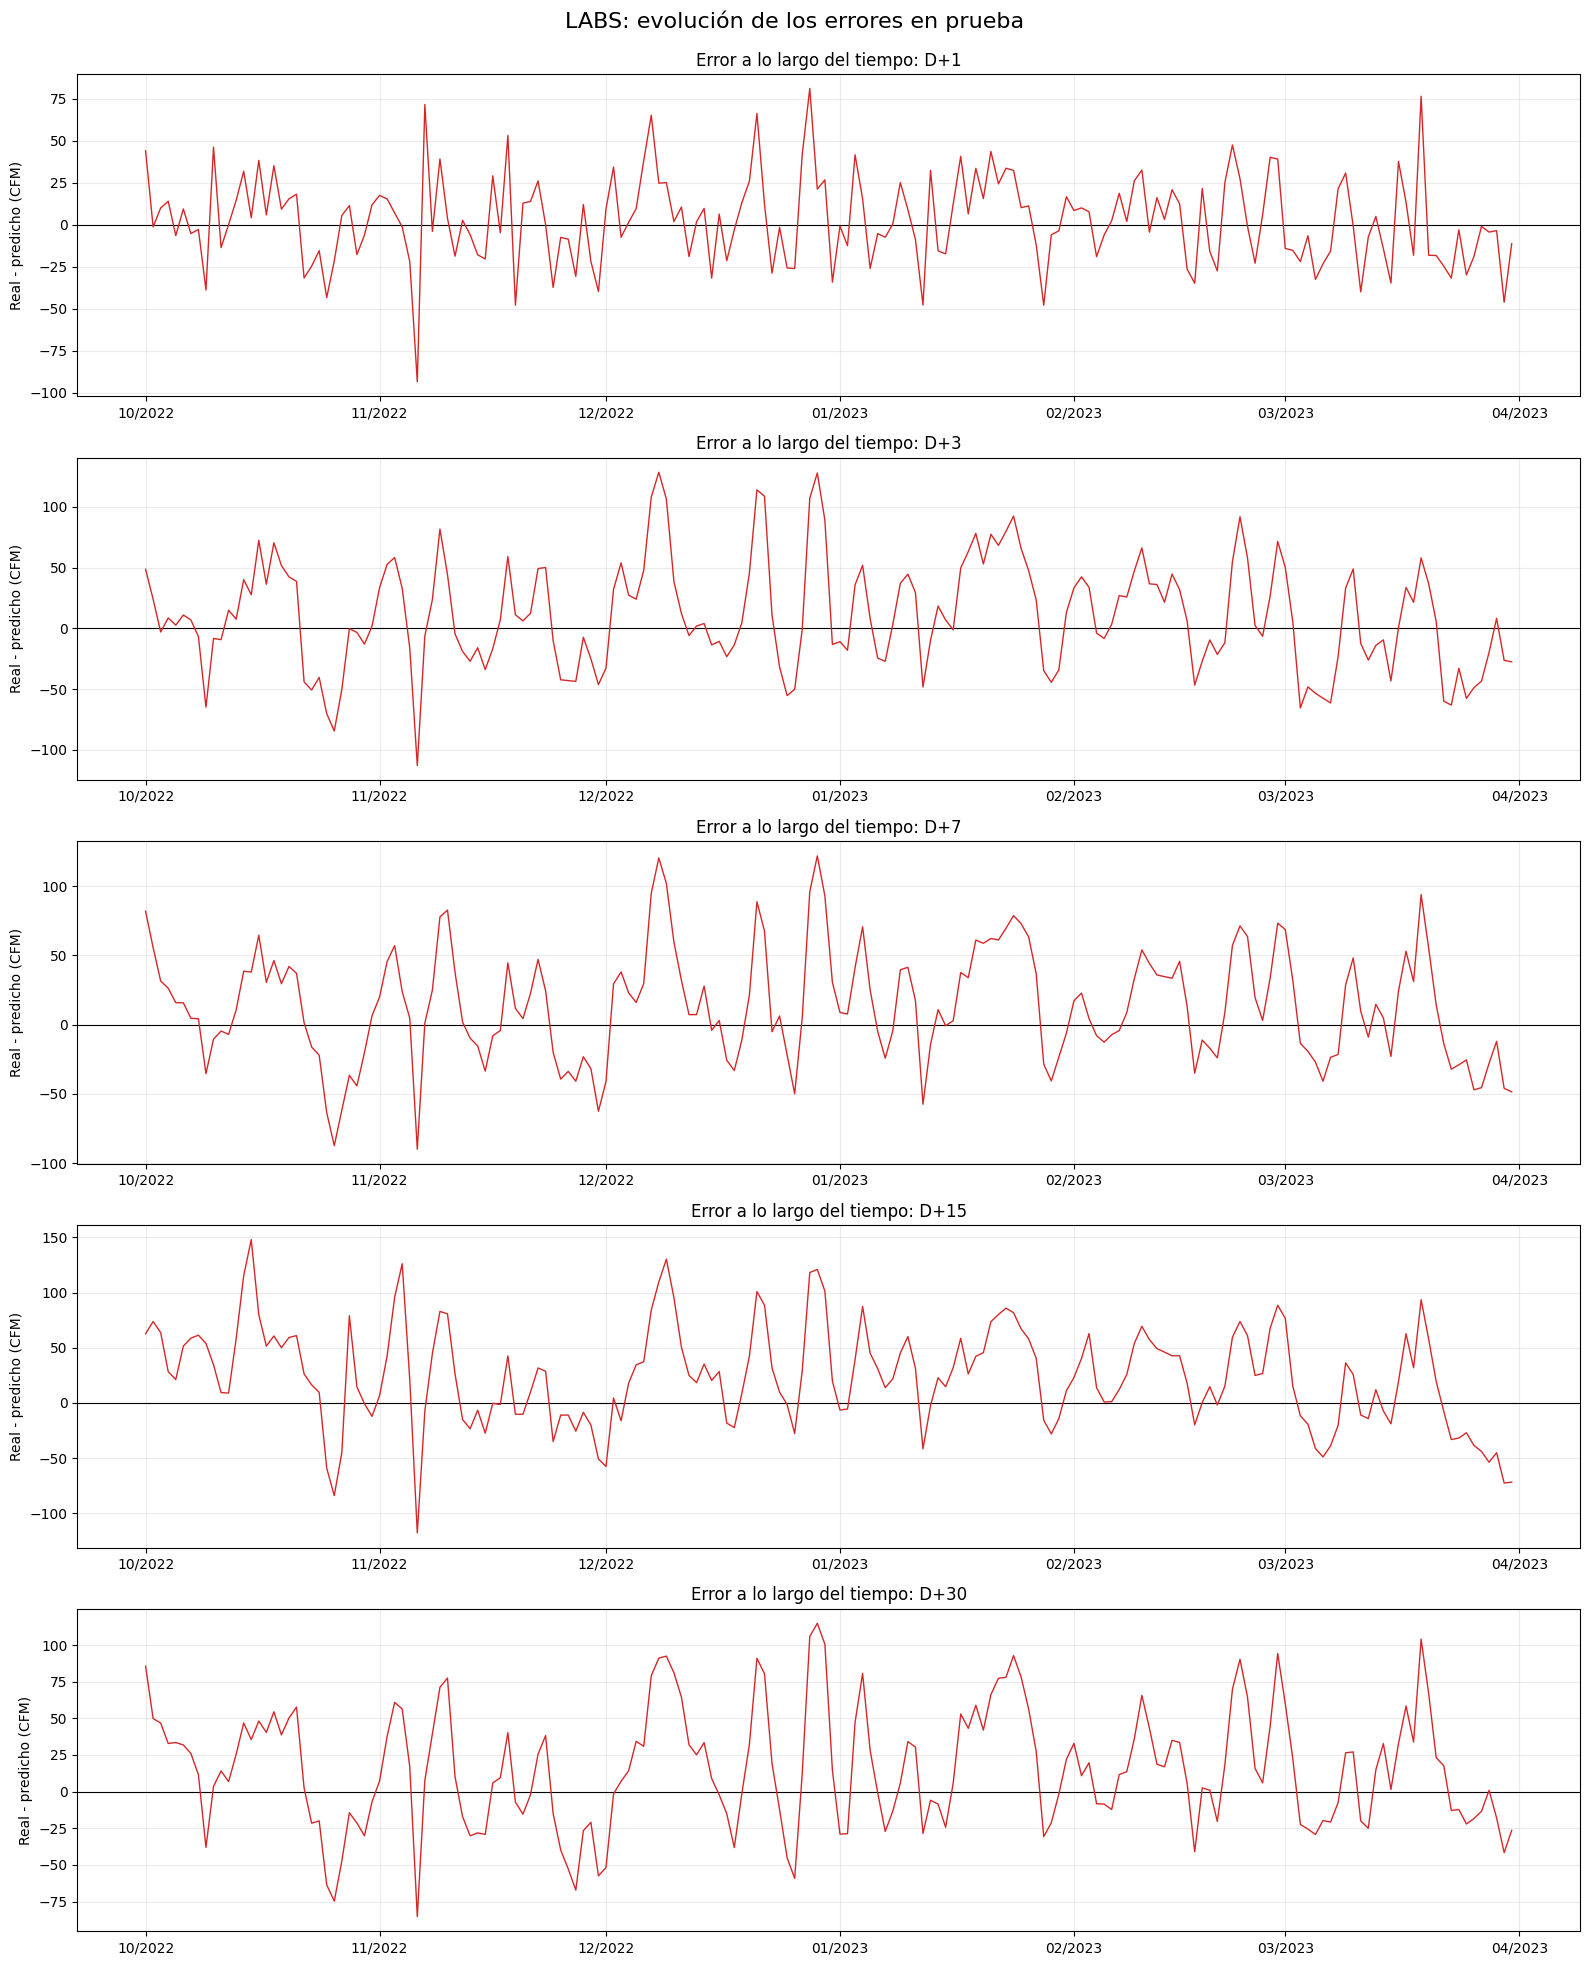

In [16]:
# Agrego la segunda referencia al resultado final y a la tabla de predicciones
resultados_prueba['MAE media 7 días'] = np.nan
resultados_prueba['RMSE media 7 días'] = np.nan
resultados_prueba['R2 media 7 días'] = np.nan
predicciones_prueba['media_7d_CFM'] = np.nan

for indice, fila in resultados_prueba.iterrows():
    horizonte = int(fila['Horizonte'])
    tipo_dataset = fila['Dataset']
    objetivo = f'Biogas_D{horizonte}'
    prueba = particiones_lab[(tipo_dataset, horizonte)]['Prueba'].copy()

    metricas_media = calcular_metricas(prueba[objetivo], prueba['Biogas_media_7d'])
    resultados_prueba.loc[indice, 'MAE media 7 días'] = metricas_media['MAE']
    resultados_prueba.loc[indice, 'RMSE media 7 días'] = metricas_media['RMSE']
    resultados_prueba.loc[indice, 'R2 media 7 días'] = metricas_media['R2']

    mascara = predicciones_prueba['horizonte_dias'] == horizonte
    predicciones_prueba.loc[mascara, 'media_7d_CFM'] = prueba['Biogas_media_7d'].to_numpy()

display(resultados_prueba.round(3))

# Comparo las cinco series en un único conjunto de gráficos
fig, ejes = plt.subplots(5, 1, figsize=(16, 24), sharex=False)

for eje, horizonte in zip(ejes, horizontes):
    tabla = predicciones_prueba[
        predicciones_prueba['horizonte_dias'] == horizonte
    ].sort_values('fecha_objetivo')

    eje.plot(tabla['fecha_objetivo'], tabla['real_CFM'], color='black', linewidth=1.4, label='Valor real')
    eje.plot(tabla['fecha_objetivo'], tabla['predicho_CFM'], color='tab:blue', linewidth=1.2, label='Modelo seleccionado')
    eje.plot(tabla['fecha_objetivo'], tabla['persistencia_CFM'], color='tab:orange', linewidth=0.9, alpha=0.8, label='Persistencia')
    eje.plot(tabla['fecha_objetivo'], tabla['media_7d_CFM'], color='tab:green', linewidth=0.9, alpha=0.8, label='Media de 7 días')
    eje.set_title(f'Prueba final: horizonte D+{horizonte}')
    eje.set_ylabel('Biogás (CFM)')
    eje.grid(alpha=0.25)
    eje.legend(loc='upper left', ncol=4, fontsize=8)
    eje.xaxis.set_major_locator(mdates.MonthLocator())
    eje.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

fig.suptitle('LABS: valores reales y predicciones en el periodo de prueba', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(carpeta_graficos / '05_forecasting_labs_prueba.png', dpi=160, bbox_inches='tight')
plt.show()

# Reviso el error real menos predicho a lo largo del tiempo
fig, ejes = plt.subplots(5, 1, figsize=(16, 20), sharex=False)

for eje, horizonte in zip(ejes, horizontes):
    tabla = predicciones_prueba[
        predicciones_prueba['horizonte_dias'] == horizonte
    ].sort_values('fecha_objetivo')
    eje.axhline(0, color='black', linewidth=0.8)
    eje.plot(tabla['fecha_objetivo'], tabla['error_CFM'], color='tab:red', linewidth=1)
    eje.set_title(f'Error a lo largo del tiempo: D+{horizonte}')
    eje.set_ylabel('Real - predicho (CFM)')
    eje.grid(alpha=0.25)
    eje.xaxis.set_major_locator(mdates.MonthLocator())
    eje.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

fig.suptitle('LABS: evolución de los errores en prueba', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(carpeta_graficos / '06_errores_labs_prueba.png', dpi=160, bbox_inches='tight')
plt.show()


### Análisis de la evaluación final

El horizonte **D+1** ofrece el resultado más consistente. La Regresión Lineal alcanza un MAE de **20,58 CFM**, mejora la persistencia aproximadamente un **17,4 %** y conserva un **R² de 0,60**. Esto indica que el historial reciente y las condiciones operativas permiten explicar una parte relevante de los cambios del día siguiente.

En **D+3** la Regresión Lineal reduce el MAE de persistencia aproximadamente un **24,8 %**, pero su R² pasa a **-0,19**. En **D+7**, Random Forest con las variables de estabilidad reduce el MAE alrededor de un **22,8 %**, aunque su R² se mantiene cerca de cero. Los modelos superan la referencia de repetir el último valor, pero todavía tienen dificultades para representar los cambios diarios de mayor magnitud.

El horizonte **D+15** es el más débil frente a persistencia: la mejora del MAE es solamente de **5,2 %** y el R² desciende hasta **-0,49**. En **D+30**, Random Forest reduce el MAE aproximadamente un **31,6 %**, pero el R² continúa siendo ligeramente negativo. La mejora porcentual es alta porque la persistencia se deteriora considerablemente a treinta días, no porque el modelo reproduzca con precisión todos los picos futuros.

Por lo tanto, el resultado principal del proyecto se encuentra en el pronóstico de corto plazo. Los horizontes más largos pueden aportar una referencia general, pero no deberían presentarse con el mismo nivel de confianza que D+1.


## 6.1 Reviso la importancia de las variables

Para interpretar cada modelo calcularé la importancia por permutación sobre validación. Esta técnica mide cuánto aumenta el error cuando se desordena una característica. Una importancia alta indica utilidad predictiva dentro del modelo, pero no demuestra que la variable sea la causa del cambio en el biogás.


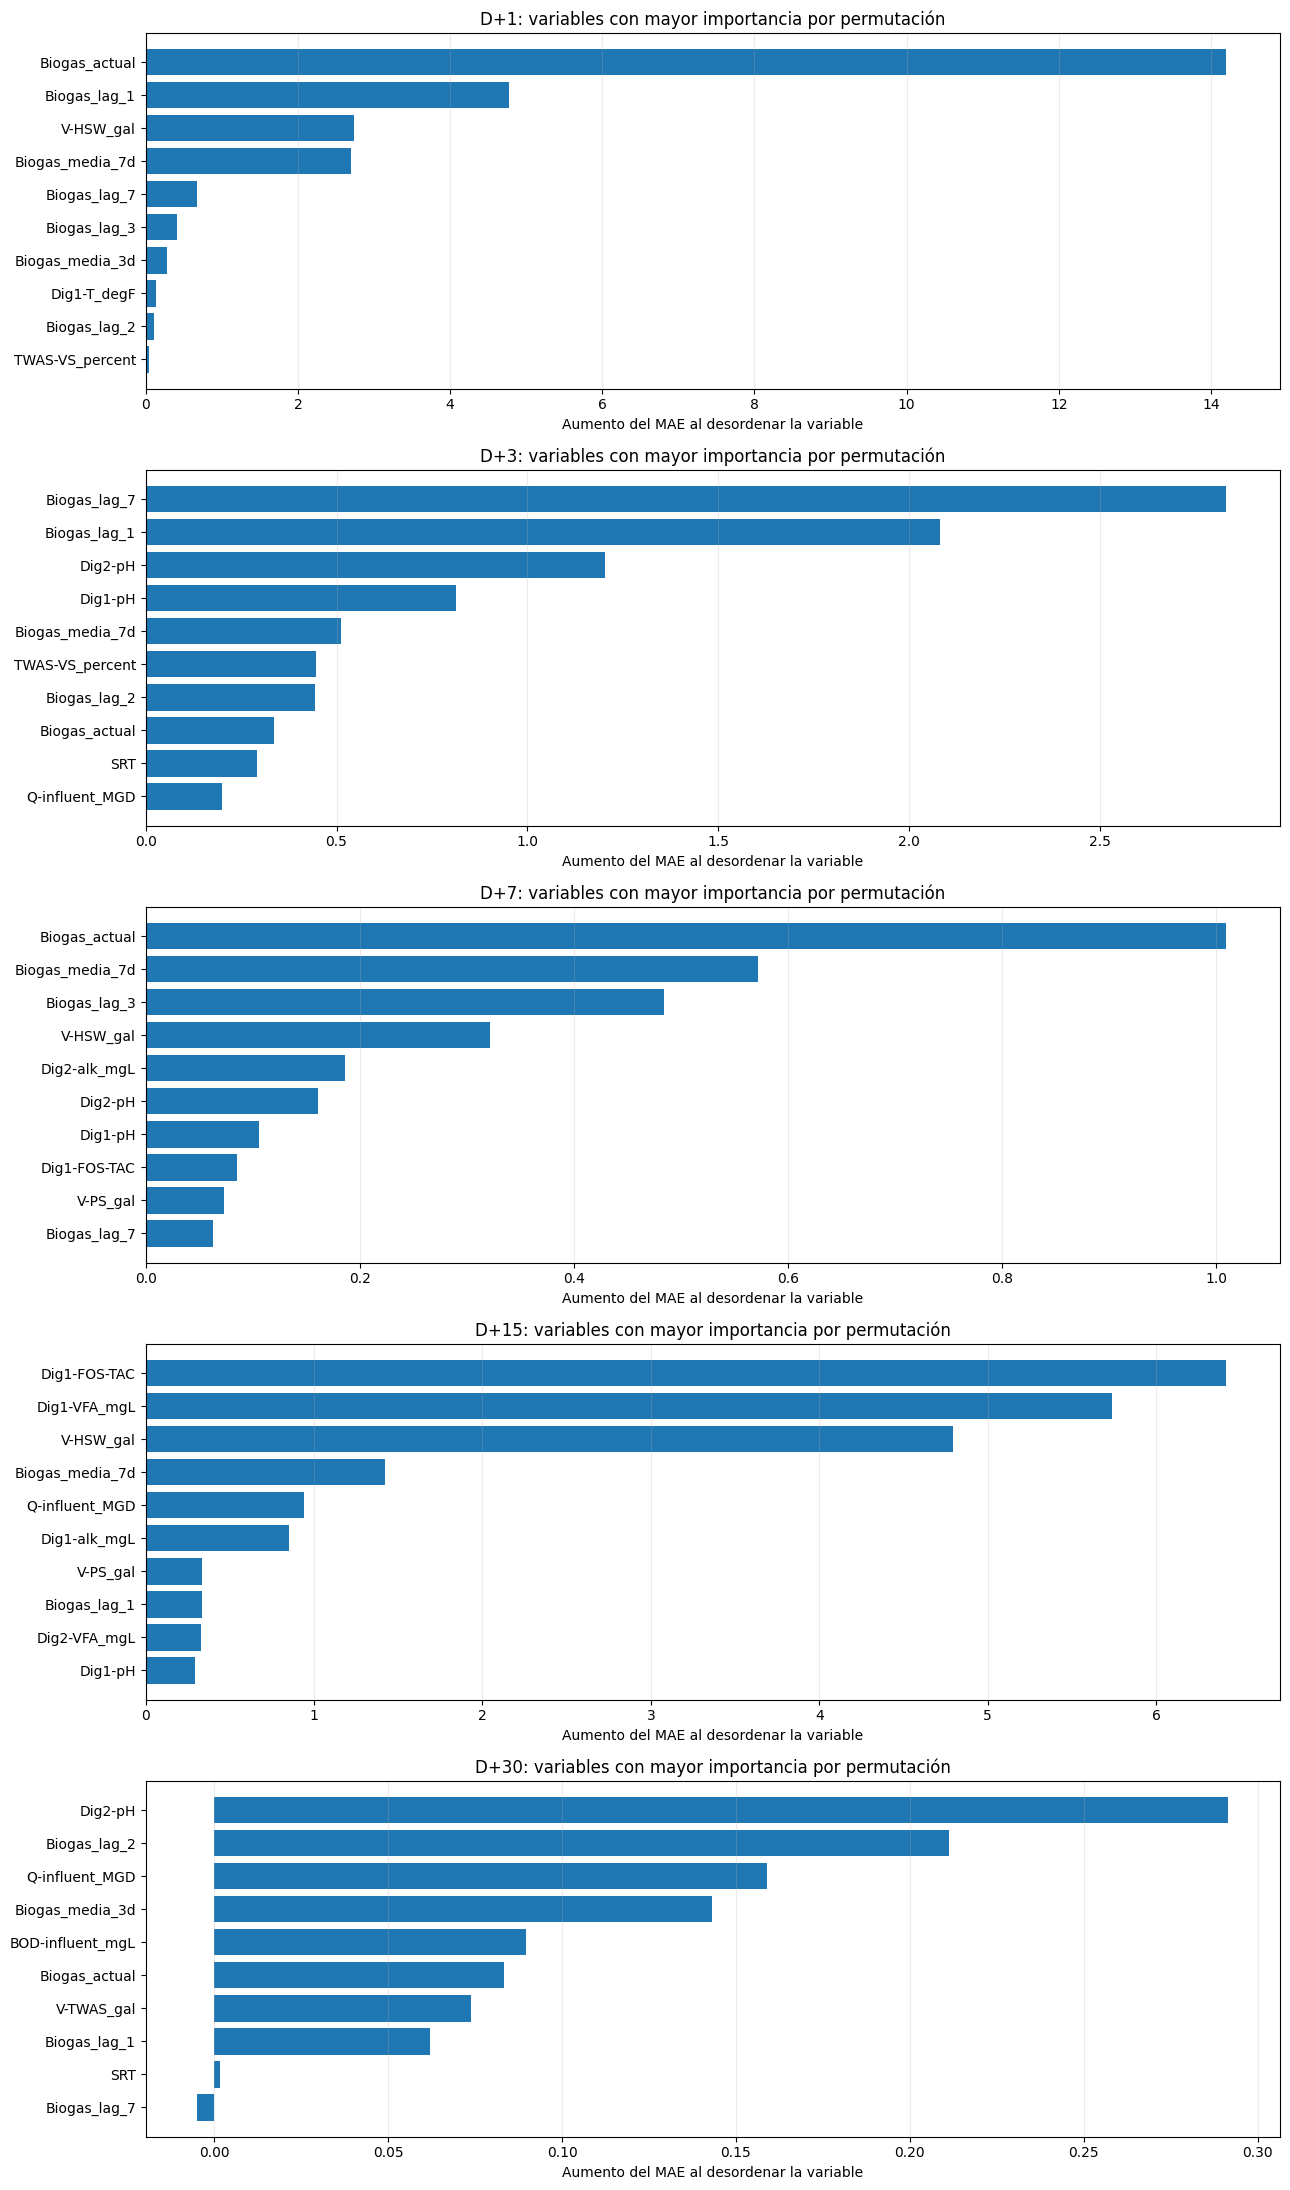

,Horizonte,Dataset,Modelo,Variable,Importancia_MAE,Desviación
0,1,Operativo,Regresión lineal,Biogas_actual,14.198,0.811
1,1,Operativo,Regresión lineal,Biogas_lag_1,4.769,0.745
11,1,Operativo,Regresión lineal,V-HSW_gal,2.734,0.364
6,1,Operativo,Regresión lineal,Biogas_media_7d,2.691,0.596
4,1,Operativo,Regresión lineal,Biogas_lag_7,0.676,0.215
3,1,Operativo,Regresión lineal,Biogas_lag_3,0.405,0.207
5,1,Operativo,Regresión lineal,Biogas_media_3d,0.279,0.186
12,1,Operativo,Regresión lineal,Dig1-T_degF,0.138,0.092
24,3,Operativo,Regresión lineal,Biogas_lag_7,2.830,0.377
21,3,Operativo,Regresión lineal,Biogas_lag_1,2.081,0.557


In [17]:
from sklearn.inspection import permutation_importance

importancias_modelos = []

for _, seleccion in seleccion_validacion.iterrows():
    horizonte = int(seleccion['Horizonte'])
    tipo_dataset = seleccion['Dataset seleccionado']
    nombre_modelo = seleccion['Modelo seleccionado']
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    variables = (
        variables_modelo_operativo
        if tipo_dataset == 'Operativo'
        else variables_modelo_estabilidad
    )

    validacion = particiones_lab[(tipo_dataset, horizonte)]['Validación'].copy()
    fechas_comunes = set(
        particiones_lab[('Estabilidad', horizonte)]['Validación'][fecha_objetivo]
    )
    validacion = validacion[validacion[fecha_objetivo].isin(fechas_comunes)]
    modelo = modelos_validacion[(tipo_dataset, horizonte, nombre_modelo)]

    resultado = permutation_importance(
        modelo,
        validacion[variables],
        validacion[objetivo],
        scoring='neg_mean_absolute_error',
        n_repeats=10,
        random_state=12345,
        n_jobs=1
    )

    for variable, importancia, desviacion in zip(
        variables, resultado.importances_mean, resultado.importances_std
    ):
        importancias_modelos.append({
            'Horizonte': horizonte,
            'Dataset': tipo_dataset,
            'Modelo': nombre_modelo,
            'Variable': variable,
            'Importancia_MAE': importancia,
            'Desviación': desviacion
        })

importancias_modelos = pd.DataFrame(importancias_modelos)

fig, ejes = plt.subplots(5, 1, figsize=(13, 22))
for eje, horizonte in zip(ejes, horizontes):
    top = (
        importancias_modelos[importancias_modelos['Horizonte'] == horizonte]
        .sort_values('Importancia_MAE', ascending=False)
        .head(10)
        .sort_values('Importancia_MAE')
    )
    eje.barh(top['Variable'], top['Importancia_MAE'], color='tab:blue')
    eje.set_title(f'D+{horizonte}: variables con mayor importancia por permutación')
    eje.set_xlabel('Aumento del MAE al desordenar la variable')
    eje.grid(axis='x', alpha=0.25)

fig.tight_layout()
fig.savefig(carpeta_graficos / '07_importancia_variables_labs.png', dpi=160, bbox_inches='tight')
plt.show()

display(
    importancias_modelos.sort_values(
        ['Horizonte', 'Importancia_MAE'], ascending=[True, False]
    ).groupby('Horizonte').head(8).round(3)
)


## A.1 Disponibilidad de los análisis de laboratorio

El modelo de estabilidad incorpora **alcalinidad, ácidos grasos volátiles (AGV) y FOS/TAC** porque estas variables ayudan a describir el equilibrio del proceso biológico. Sin embargo, una fecha de muestreo no confirma que el resultado del laboratorio estuviera disponible al momento de realizar la predicción.

Por esta razón mantengo dos alternativas. El **modelo operativo** utiliza el historial del biogás y variables de operación que pueden consultarse con mayor frecuencia. El **modelo de estabilidad** solamente utiliza las 855 fechas que contienen las seis mediciones de laboratorio. Este segundo modelo permite estudiar si esas variables aportan información, pero su aplicación diaria dependería del tiempo real que tarde el laboratorio en entregar cada resultado.

En una implementación real utilizaría el modelo operativo como referencia principal cuando los análisis no estén disponibles al cierre del día. Solo incorporaría alcalinidad, AGV y FOS/TAC después de confirmar que se conocen antes de generar el pronóstico. De esta manera evito utilizar información que, aunque aparece asociada a una fecha, podría haberse conocido posteriormente.


## A.2 Compruebo la estabilidad mediante backtesting temporal

La evaluación anterior utiliza una sola división cronológica. Para comprobar que el resultado no dependa únicamente de ese periodo, repetiré el entrenamiento mediante **cuatro ventanas expansivas**. En cada corte entrenaré con toda la información disponible hasta una fecha y validaré sobre los tres meses siguientes.

Mantendré el modelo y el conjunto de variables seleccionados anteriormente para cada horizonte. Este ejercicio no vuelve a escoger hiperparámetros ni utiliza la prueba final. Su propósito es observar si el comportamiento se repite en distintos momentos y compararlo con persistencia y con la media de los siete días anteriores.


In [18]:
# Defino cuatro cortes trimestrales y amplío el entrenamiento en cada repetición
cortes_backtesting = [
    ('Corte 1', pd.Timestamp('2021-09-30'), pd.Timestamp('2021-12-31')),
    ('Corte 2', pd.Timestamp('2021-12-31'), pd.Timestamp('2022-03-31')),
    ('Corte 3', pd.Timestamp('2022-03-31'), pd.Timestamp('2022-06-30')),
    ('Corte 4', pd.Timestamp('2022-06-30'), pd.Timestamp('2022-09-30'))
]

resultados_backtesting = []
importancias_backtesting = []

for _, seleccion in seleccion_validacion.iterrows():
    horizonte = int(seleccion['Horizonte'])
    tipo_dataset = seleccion['Dataset seleccionado']
    nombre_modelo = seleccion['Modelo seleccionado']
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    variables = (
        variables_modelo_operativo
        if tipo_dataset == 'Operativo'
        else variables_modelo_estabilidad
    )
    tabla = datasets_lab[(tipo_dataset, horizonte)].copy()

    for nombre_corte, fin_entrenamiento_bt, fin_validacion_bt in cortes_backtesting:
        entrenamiento_bt = tabla[
            tabla[fecha_objetivo] <= fin_entrenamiento_bt
        ].copy()
        validacion_bt = tabla[
            (tabla[fecha_objetivo] > fin_entrenamiento_bt) &
            (tabla[fecha_objetivo] <= fin_validacion_bt)
        ].copy()

        modelo_bt = clone(modelos_disponibles[nombre_modelo])
        modelo_bt.fit(entrenamiento_bt[variables], entrenamiento_bt[objetivo])
        predicho_bt = modelo_bt.predict(validacion_bt[variables])

        metricas_modelo = calcular_metricas(validacion_bt[objetivo], predicho_bt)
        metricas_persistencia = calcular_metricas(
            validacion_bt[objetivo], validacion_bt['Biogas_actual']
        )
        metricas_media_7d = calcular_metricas(
            validacion_bt[objetivo], validacion_bt['Biogas_media_7d']
        )

        resultados_backtesting.append({
            'Horizonte': horizonte,
            'Corte': nombre_corte,
            'Fin entrenamiento': fin_entrenamiento_bt,
            'Fin validación': fin_validacion_bt,
            'Dataset': tipo_dataset,
            'Modelo': nombre_modelo,
            'Muestras entrenamiento': len(entrenamiento_bt),
            'Muestras validación': len(validacion_bt),
            'MAE modelo': metricas_modelo['MAE'],
            'RMSE modelo': metricas_modelo['RMSE'],
            'R2 modelo': metricas_modelo['R2'],
            'MAE persistencia': metricas_persistencia['MAE'],
            'MAE media 7 días': metricas_media_7d['MAE'],
            'Mejora frente a persistencia (%)': (
                (metricas_persistencia['MAE'] - metricas_modelo['MAE']) /
                metricas_persistencia['MAE'] * 100
            ),
            'Mejora frente a media 7 días (%)': (
                (metricas_media_7d['MAE'] - metricas_modelo['MAE']) /
                metricas_media_7d['MAE'] * 100
            )
        })

        # Reviso también si las variables importantes se repiten entre los cortes
        importancia_bt = permutation_importance(
            modelo_bt,
            validacion_bt[variables],
            validacion_bt[objetivo],
            scoring='neg_mean_absolute_error',
            n_repeats=5,
            random_state=12345,
            n_jobs=1
        )

        tabla_importancia = pd.DataFrame({
            'Variable': variables,
            'Importancia_MAE': importancia_bt.importances_mean
        }).sort_values('Importancia_MAE', ascending=False)
        tabla_importancia['Posición'] = range(1, len(tabla_importancia) + 1)

        for _, fila_importancia in tabla_importancia.iterrows():
            importancias_backtesting.append({
                'Horizonte': horizonte,
                'Corte': nombre_corte,
                'Dataset': tipo_dataset,
                'Modelo': nombre_modelo,
                'Variable': fila_importancia['Variable'],
                'Importancia_MAE': fila_importancia['Importancia_MAE'],
                'Posición': int(fila_importancia['Posición']),
                'Aparece_top_5': int(fila_importancia['Posición'] <= 5)
            })

resultados_backtesting = pd.DataFrame(resultados_backtesting)
importancias_backtesting = pd.DataFrame(importancias_backtesting)

resumen_backtesting = (
    resultados_backtesting.groupby(['Horizonte', 'Dataset', 'Modelo'], as_index=False)
    .agg(
        Cortes=('Corte', 'count'),
        MAE_medio_modelo=('MAE modelo', 'mean'),
        Desviación_MAE=('MAE modelo', 'std'),
        MAE_medio_persistencia=('MAE persistencia', 'mean'),
        MAE_media_7d=('MAE media 7 días', 'mean'),
        Mejora_media_persistencia=('Mejora frente a persistencia (%)', 'mean'),
        Mejora_media_media_7d=('Mejora frente a media 7 días (%)', 'mean')
    )
)

cortes_ganados = (
    resultados_backtesting.assign(
        Gana_persistencia=lambda tabla: tabla['MAE modelo'] < tabla['MAE persistencia'],
        Gana_media_7d=lambda tabla: tabla['MAE modelo'] < tabla['MAE media 7 días']
    )
    .groupby('Horizonte', as_index=False)
    .agg(
        Cortes_ganados_persistencia=('Gana_persistencia', 'sum'),
        Cortes_ganados_media_7d=('Gana_media_7d', 'sum')
    )
)

resumen_backtesting = resumen_backtesting.merge(cortes_ganados, on='Horizonte')

resumen_importancias_backtesting = (
    importancias_backtesting.groupby(['Horizonte', 'Variable'], as_index=False)
    .agg(
        Importancia_media=('Importancia_MAE', 'mean'),
        Apariciones_top_5=('Aparece_top_5', 'sum'),
        Posición_media=('Posición', 'mean')
    )
    .sort_values(
        ['Horizonte', 'Apariciones_top_5', 'Importancia_media'],
        ascending=[True, False, False]
    )
)

display(resultados_backtesting.round(3))
display(resumen_backtesting.round(3))
display(resumen_importancias_backtesting.groupby('Horizonte').head(8).round(3))


,Horizonte,Corte,Fin entrenamiento,Fin validación,Dataset,Modelo,Muestras entrenamiento,Muestras validación,MAE modelo,RMSE modelo,R2 modelo,MAE persistencia,MAE media 7 días,Mejora frente a persistencia (%),Mejora frente a media 7 días (%)
0,1,Corte 1,2021-09-30,2021-12-31,Operativo,Regresión lineal,540,92,20.103,26.961,0.507,23.279,29.561,13.643,31.994
1,1,Corte 2,2021-12-31,2022-03-31,Operativo,Regresión lineal,632,90,17.180,21.668,0.635,23.079,28.599,25.560,39.928
2,1,Corte 3,2022-03-31,2022-06-30,Operativo,Regresión lineal,722,91,18.790,23.504,0.561,20.568,29.931,8.646,37.223
3,1,Corte 4,2022-06-30,2022-09-30,Operativo,Regresión lineal,813,92,12.894,16.524,0.647,14.247,19.156,9.498,32.690
4,3,Corte 1,2021-09-30,2021-12-31,Operativo,Regresión lineal,536,92,29.721,37.981,0.022,38.277,35.959,22.352,17.346
5,3,Corte 2,2021-12-31,2022-03-31,Operativo,Regresión lineal,628,90,31.128,39.579,-0.219,44.862,30.778,30.614,-1.138
6,3,Corte 3,2022-03-31,2022-06-30,Operativo,Regresión lineal,718,91,29.365,37.942,-0.143,39.444,34.569,25.554,15.055
7,3,Corte 4,2022-06-30,2022-09-30,Operativo,Regresión lineal,809,92,20.015,25.796,0.139,26.129,23.160,23.399,13.578
8,7,Corte 1,2021-09-30,2021-12-31,Estabilidad,Random Forest B,355,69,32.555,41.718,-0.066,43.952,46.178,25.930,29.501
9,7,Corte 2,2021-12-31,2022-03-31,Estabilidad,Random Forest B,424,78,36.078,43.631,-1.118,32.188,32.945,-12.084,-9.508


,Horizonte,Dataset,Modelo,Cortes,MAE_medio_modelo,Desviación_MAE,MAE_medio_persistencia,MAE_media_7d,Mejora_media_persistencia,Mejora_media_media_7d,Cortes_ganados_persistencia,Cortes_ganados_media_7d
0,1,Operativo,Regresión lineal,4,17.242,3.136,20.293,26.812,14.337,35.459,4,4
1,3,Operativo,Regresión lineal,4,27.557,5.085,37.178,31.116,25.480,11.210,4,3
2,7,Estabilidad,Random Forest B,4,30.638,5.713,36.566,37.308,14.514,16.554,3,3
3,15,Estabilidad,Regresión lineal,4,31.769,9.023,35.888,32.449,10.248,2.744,3,3
4,30,Operativo,Random Forest A,4,32.811,9.747,41.727,34.578,21.588,5.205,3,3


,Horizonte,Variable,Importancia_media,Apariciones_top_5,Posición_media
1,1,Biogas_actual,16.042,4,1.00
4,1,Biogas_lag_1,6.174,4,2.00
9,1,Biogas_media_7d,2.765,4,3.25
17,1,V-HSW_gal,1.522,4,3.75
7,1,Biogas_lag_7,0.644,2,5.75
6,1,Biogas_lag_3,0.451,1,7.00
8,1,Biogas_media_3d,0.301,1,9.50
5,1,Biogas_lag_2,0.213,0,9.25
27,3,Biogas_lag_7,2.220,4,2.00
24,3,Biogas_lag_1,1.961,4,2.50


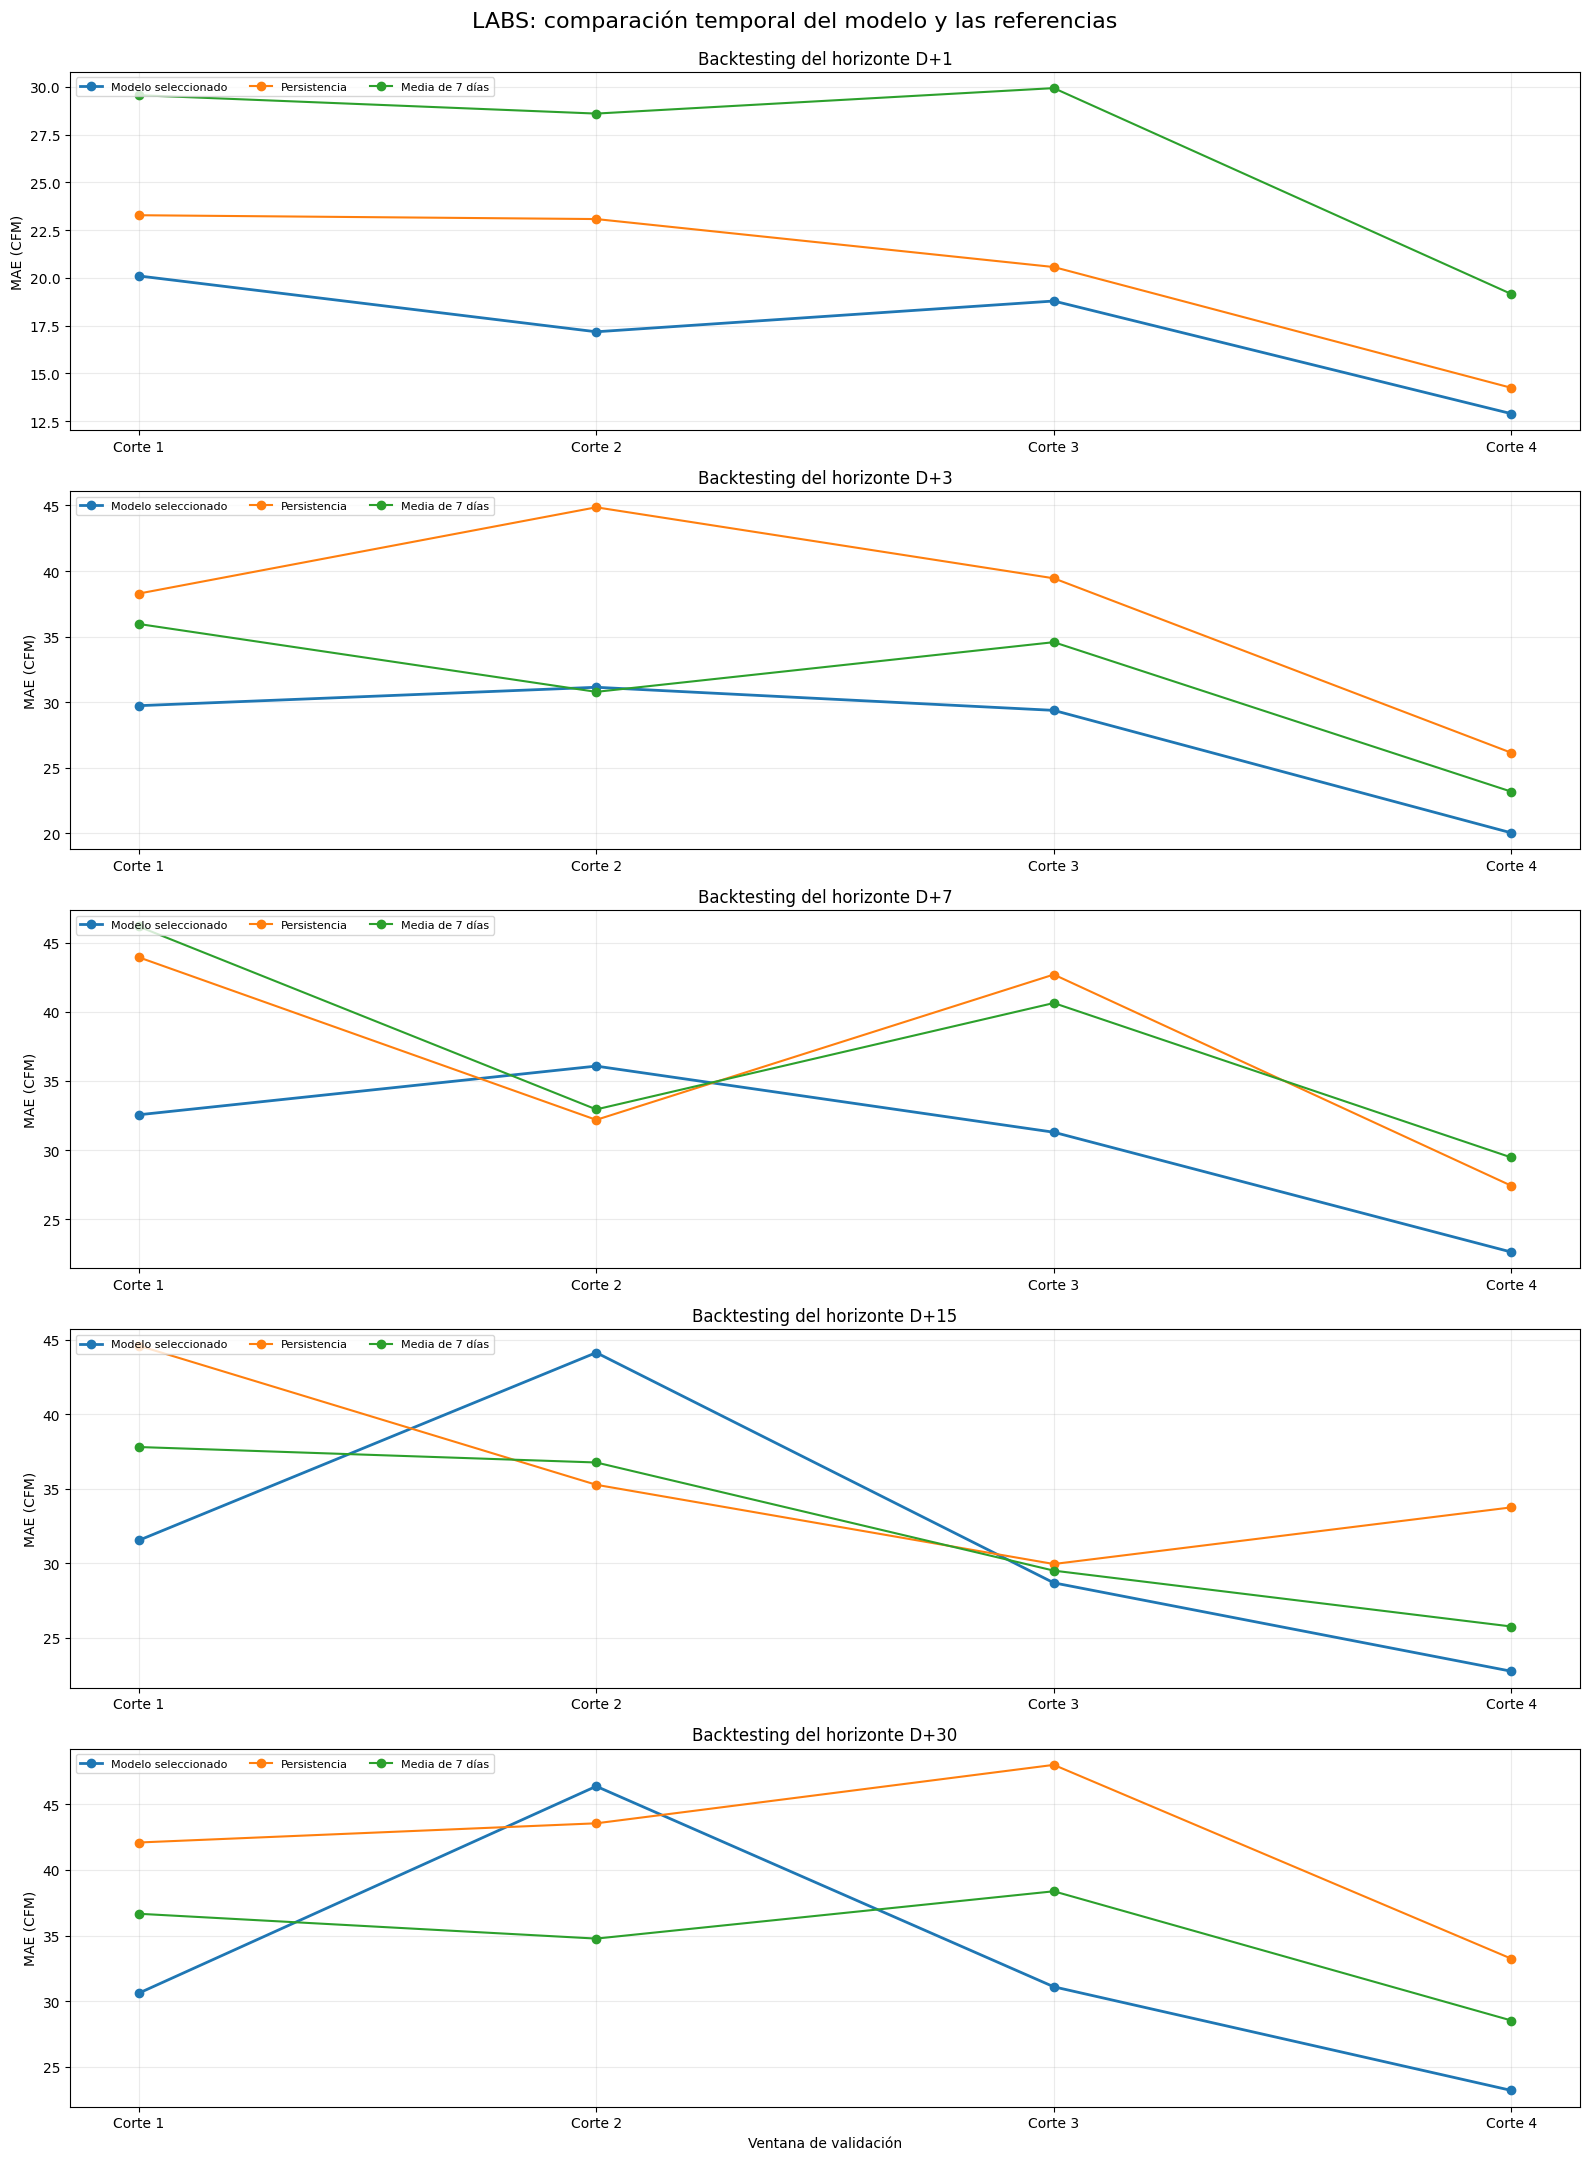

In [19]:
# Comparo el MAE del modelo con las dos referencias en cada corte
fig, ejes = plt.subplots(5, 1, figsize=(16, 22), sharex=True)

for eje, horizonte in zip(ejes, horizontes):
    tabla = resultados_backtesting[
        resultados_backtesting['Horizonte'] == horizonte
    ].copy()

    eje.plot(tabla['Corte'], tabla['MAE modelo'], marker='o', linewidth=2, label='Modelo seleccionado')
    eje.plot(tabla['Corte'], tabla['MAE persistencia'], marker='o', linewidth=1.5, label='Persistencia')
    eje.plot(tabla['Corte'], tabla['MAE media 7 días'], marker='o', linewidth=1.5, label='Media de 7 días')
    eje.set_title(f'Backtesting del horizonte D+{horizonte}')
    eje.set_ylabel('MAE (CFM)')
    eje.grid(alpha=0.25)
    eje.legend(loc='upper left', ncol=3, fontsize=8)
    eje.tick_params(axis='x', labelbottom=True)

ejes[-1].set_xlabel('Ventana de validación')
fig.suptitle('LABS: comparación temporal del modelo y las referencias', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])

carpeta_graficos_backtesting = ruta_proyecto / 'images' / 'backtesting'
carpeta_graficos_backtesting.mkdir(parents=True, exist_ok=True)
fig.savefig(
    carpeta_graficos_backtesting / '01_backtesting_temporal_labs.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()


## A.3 Completo los gráficos de evaluación

Además de observar las predicciones a lo largo del tiempo, compararé directamente cada valor real con su estimación. La línea diagonal representa una predicción perfecta. Los puntos por encima de esa línea corresponden a valores reales mayores que los pronosticados, mientras que los puntos situados por debajo representan sobreestimaciones.

También dividiré la producción observada en niveles bajos, medios y altos. Esta comparación permite comprobar si el error aumenta cuando la planta produce más biogás. Finalmente, revisaré la distribución de `real - predicho`: los errores positivos indican subestimación y los negativos indican sobreestimación.


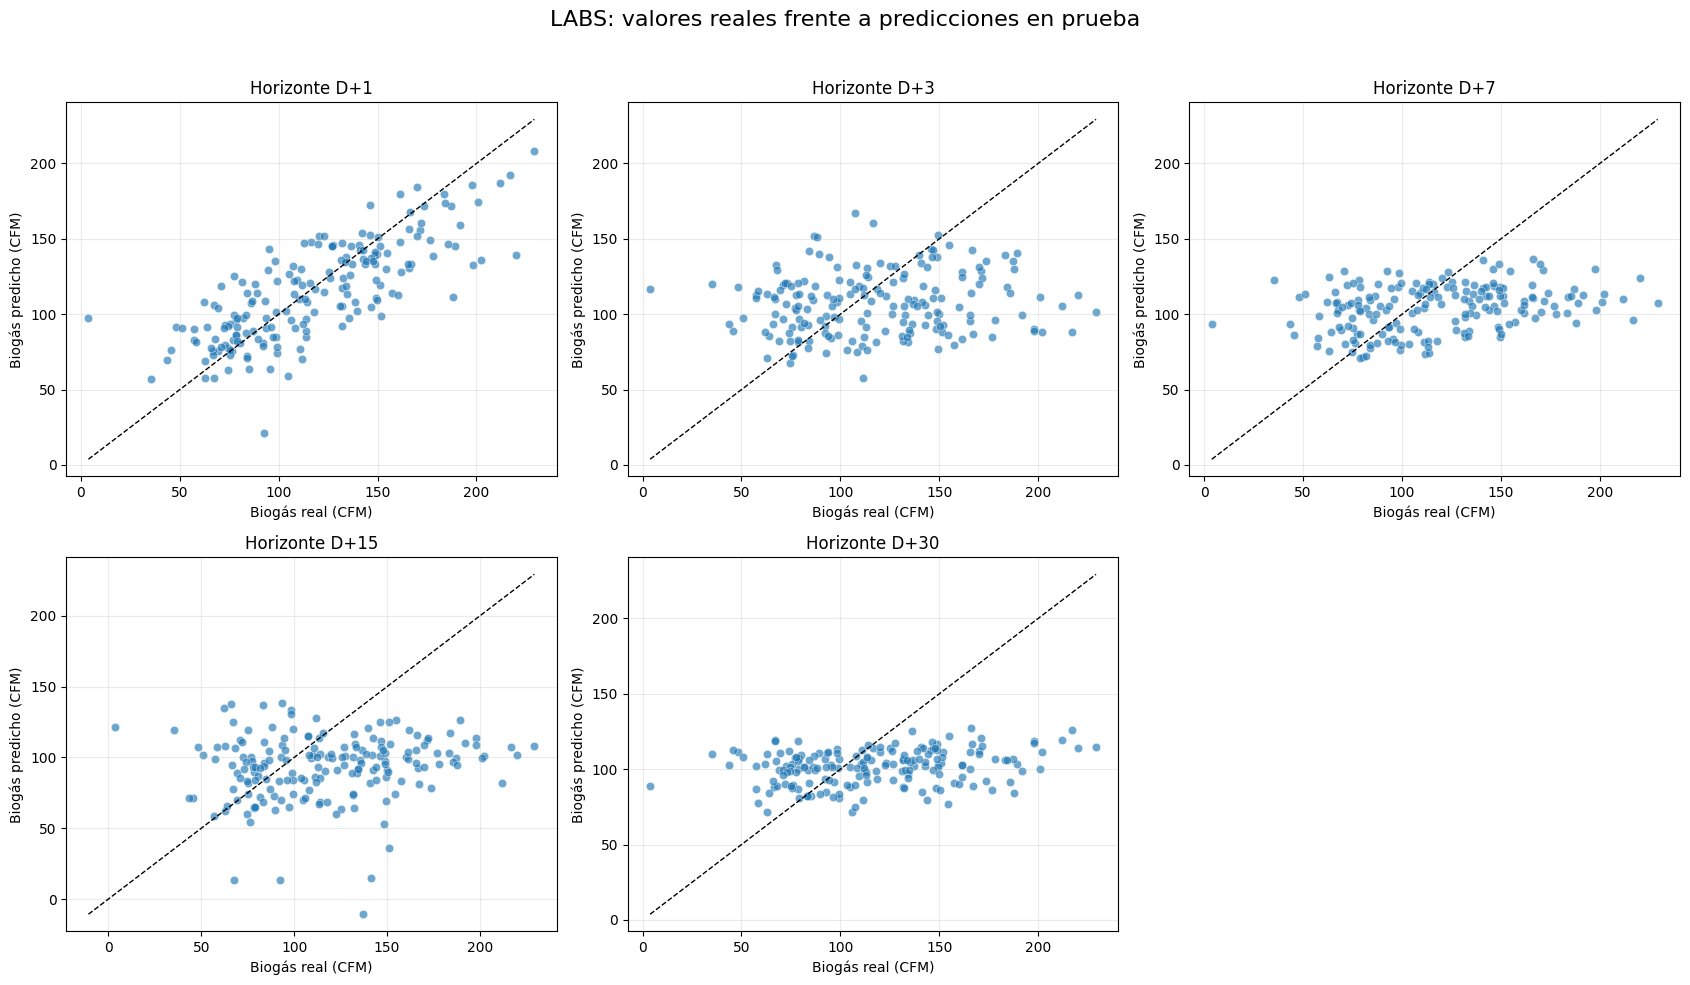

,Nivel producción,Muestras,Biogás_medio_CFM,MAE_CFM,Error_medio_CFM,Horizonte
0,Bajo,61,72.541,20.080,-14.273,1
1,Medio,60,114.748,18.079,1.502,1
2,Alto,61,165.090,23.543,20.433,1
3,Bajo,61,72.541,32.580,-31.122,3
4,Medio,60,114.748,22.369,8.698,3
5,Alto,61,165.090,53.450,53.353,3
6,Bajo,61,72.541,28.051,-26.155,7
7,Medio,60,114.748,18.308,11.867,7
8,Alto,61,165.090,54.521,54.521,7
9,Bajo,61,72.541,26.714,-16.126,15


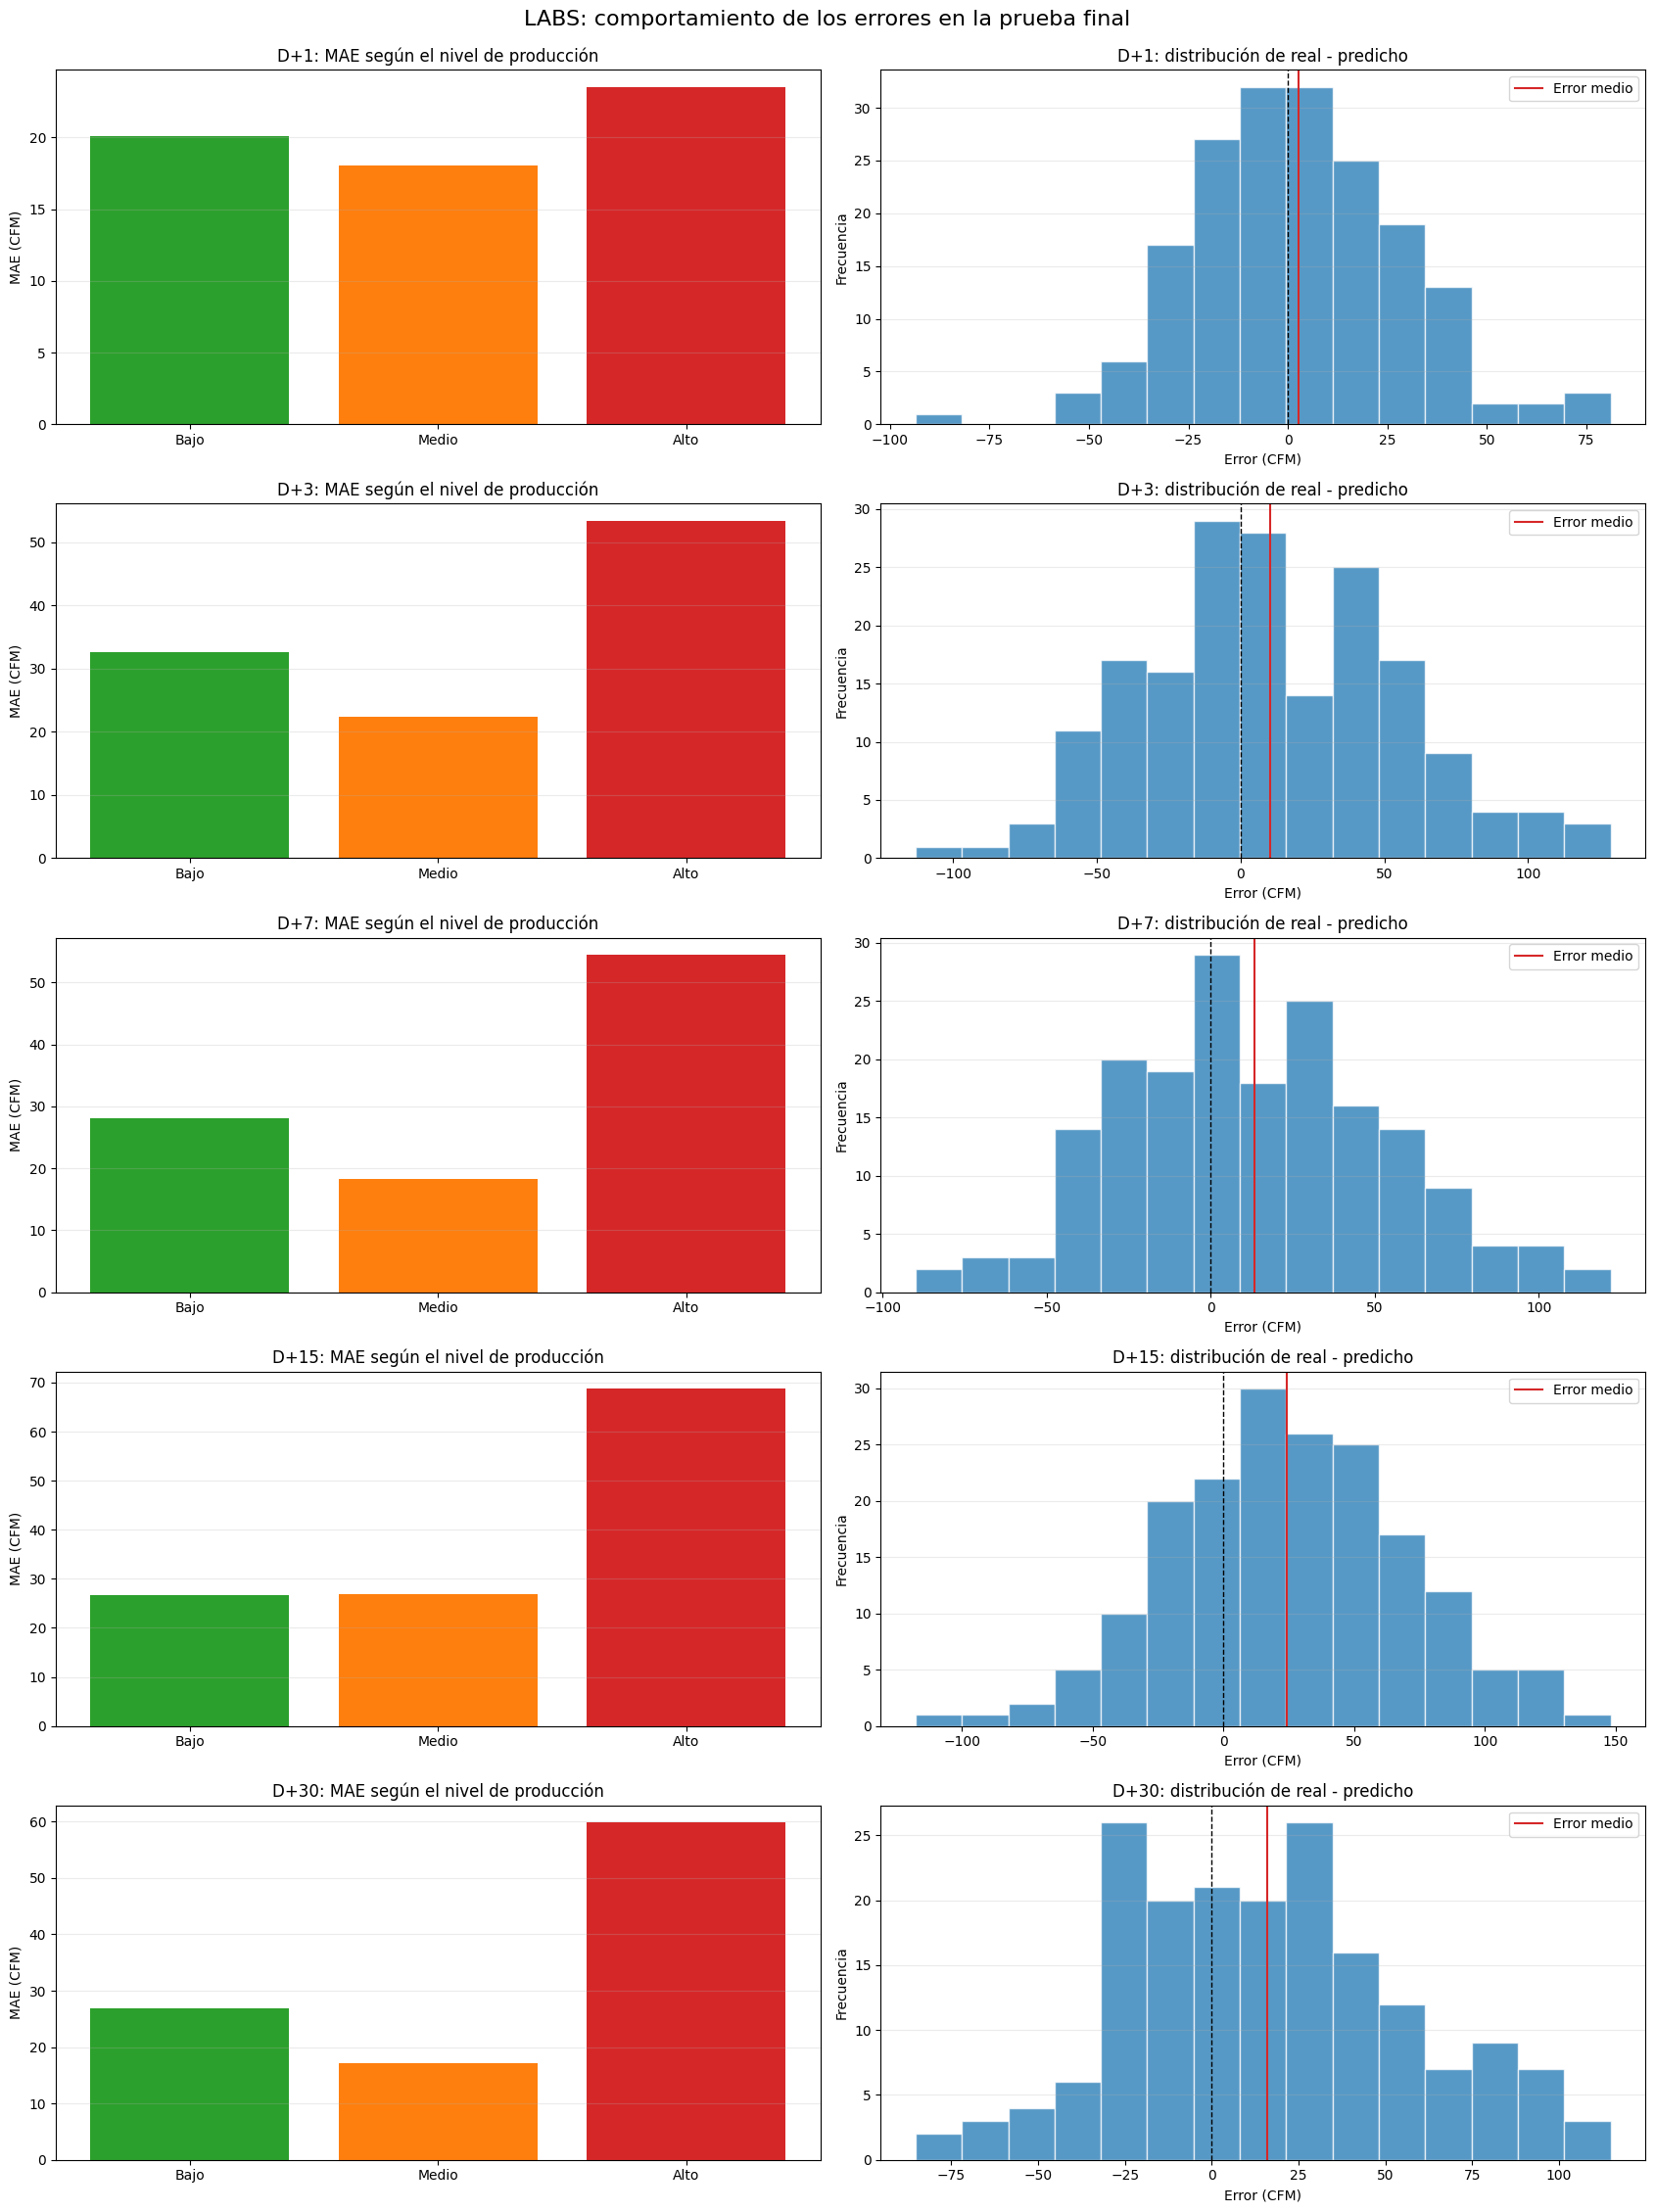

In [20]:
# Represento los valores reales frente a los predichos en la prueba final
fig, ejes = plt.subplots(2, 3, figsize=(17, 10))
ejes = ejes.flatten()

for eje, horizonte in zip(ejes, horizontes):
    tabla = predicciones_prueba[
        predicciones_prueba['horizonte_dias'] == horizonte
    ].copy()
    minimo = min(tabla['real_CFM'].min(), tabla['predicho_CFM'].min())
    maximo = max(tabla['real_CFM'].max(), tabla['predicho_CFM'].max())

    eje.scatter(
        tabla['real_CFM'],
        tabla['predicho_CFM'],
        alpha=0.65,
        color='tab:blue',
        edgecolor='white',
        linewidth=0.4
    )
    eje.plot([minimo, maximo], [minimo, maximo], color='black', linestyle='--', linewidth=1)
    eje.set_title(f'Horizonte D+{horizonte}')
    eje.set_xlabel('Biogás real (CFM)')
    eje.set_ylabel('Biogás predicho (CFM)')
    eje.grid(alpha=0.25)

ejes[-1].axis('off')
fig.suptitle('LABS: valores reales frente a predicciones en prueba', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    carpeta_graficos_backtesting / '02_real_frente_predicho_labs.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

# Calculo los errores en niveles bajos, medios y altos de producción
errores_por_nivel = []

for horizonte in horizontes:
    tabla = predicciones_prueba[
        predicciones_prueba['horizonte_dias'] == horizonte
    ].copy()
    limite_bajo = tabla['real_CFM'].quantile(1 / 3)
    limite_alto = tabla['real_CFM'].quantile(2 / 3)
    tabla['Nivel producción'] = pd.cut(
        tabla['real_CFM'],
        bins=[-np.inf, limite_bajo, limite_alto, np.inf],
        labels=['Bajo', 'Medio', 'Alto'],
        include_lowest=True
    )

    resumen_nivel = (
        tabla.groupby('Nivel producción', observed=True)
        .agg(
            Muestras=('error_CFM', 'size'),
            Biogás_medio_CFM=('real_CFM', 'mean'),
            MAE_CFM=('error_absoluto_CFM', 'mean'),
            Error_medio_CFM=('error_CFM', 'mean')
        )
        .reset_index()
    )
    resumen_nivel['Horizonte'] = horizonte
    errores_por_nivel.append(resumen_nivel)

errores_por_nivel = pd.concat(errores_por_nivel, ignore_index=True)
display(errores_por_nivel.round(3))

# Muestro el MAE por nivel y la distribución de los errores
fig, ejes = plt.subplots(5, 2, figsize=(17, 23))
colores_nivel = ['tab:green', 'tab:orange', 'tab:red']

for fila, horizonte in enumerate(horizontes):
    niveles = errores_por_nivel[errores_por_nivel['Horizonte'] == horizonte]
    errores = predicciones_prueba[
        predicciones_prueba['horizonte_dias'] == horizonte
    ]['error_CFM']

    ejes[fila, 0].bar(
        niveles['Nivel producción'].astype(str),
        niveles['MAE_CFM'],
        color=colores_nivel
    )
    ejes[fila, 0].set_title(f'D+{horizonte}: MAE según el nivel de producción')
    ejes[fila, 0].set_ylabel('MAE (CFM)')
    ejes[fila, 0].grid(axis='y', alpha=0.25)

    ejes[fila, 1].hist(errores, bins=15, color='tab:blue', alpha=0.75, edgecolor='white')
    ejes[fila, 1].axvline(0, color='black', linestyle='--', linewidth=1)
    ejes[fila, 1].axvline(errores.mean(), color='tab:red', linewidth=1.5, label='Error medio')
    ejes[fila, 1].set_title(f'D+{horizonte}: distribución de real - predicho')
    ejes[fila, 1].set_xlabel('Error (CFM)')
    ejes[fila, 1].set_ylabel('Frecuencia')
    ejes[fila, 1].grid(axis='y', alpha=0.25)
    ejes[fila, 1].legend()

fig.suptitle('LABS: comportamiento de los errores en la prueba final', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(
    carpeta_graficos_backtesting / '03_diagnostico_errores_labs.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()


### A.4 Resultados del backtesting y de los diagnósticos

El backtesting confirma que **D+1 es el horizonte más estable**. La Regresión Lineal obtiene un MAE medio de **17,24 CFM**, frente a **20,29 CFM** de persistencia y **26,81 CFM** de la media de siete días. Supera ambas referencias en los cuatro cortes y mantiene R² entre **0,51 y 0,65**. Por lo tanto, el resultado favorable de D+1 no depende solamente del periodo de validación utilizado inicialmente.

En **D+3**, el MAE medio aumenta a **27,56 CFM**. El modelo supera la persistencia en los cuatro cortes y la media de siete días en tres, pero el R² se acerca a cero o resulta negativo en tres periodos. El modelo reduce el error absoluto, aunque ya representa con menor precisión los cambios diarios de la serie.

Los horizontes **D+7, D+15 y D+30** son menos uniformes. D+7 supera las dos referencias en tres de los cuatro cortes, pero falla en el segundo. D+15 también gana tres cortes, aunque su mejora media frente a la media de siete días es solamente de **2,74 %** y en la prueba final esa referencia sencilla continúa siendo mejor. D+30 presenta la mayor variación entre cortes, con una desviación del MAE de **9,75 CFM**. Estos resultados mantienen los horizontes largos como experimentales y no justifican presentarlos con el mismo nivel de confianza que D+1.

Los gráficos de dispersión muestran otro patrón importante. En D+1 las predicciones acompañan razonablemente la diagonal, aunque tienden a **sobreestimar los valores bajos** y a **subestimar los altos**. El MAE es de **20,08 CFM** en producción baja, **18,08 CFM** en producción media y **23,54 CFM** en producción alta. Desde D+3 esta compresión hacia valores cercanos al promedio se vuelve mucho más evidente. En producción alta, el MAE alcanza **53,45 CFM** en D+3, **54,52 CFM** en D+7, **68,81 CFM** en D+15 y **59,88 CFM** en D+30. Esto indica que los horizontes largos no reproducen bien los picos de producción.

La importancia por permutación también cambia con el horizonte. En D+1 se repiten en los cuatro cortes el biogás actual, el retardo de un día, la media de siete días y el volumen de HSW. En D+3 se mantienen los retardos de uno y siete días y la media semanal. D+15 da mayor importancia a FOS/TAC del digestor 1 y al volumen de HSW, pero estas variables pertenecen al conjunto de estabilidad y dependen de la disponibilidad del laboratorio. En D+30 ninguna variable conserva una importancia dominante en todos los cortes, lo que coincide con la menor estabilidad del pronóstico.

En conjunto, el backtesting **sí aporta información adicional**. Refuerza la elección de D+1 como resultado principal, mantiene D+3 como una posibilidad secundaria y confirma que D+7, D+15 y D+30 deben comunicarse con mayor cautela. También muestra que el problema principal de los horizontes largos no es solamente un MAE mayor, sino la tendencia a suavizar la serie y perder los valores extremos.


# 7. Experimento diario con SCADA

SCADA se analizará como un experimento independiente. Primero agregaré las señales por día y conservaré una columna de cobertura. No rellenaré los minutos desconocidos ni utilizaré días incompletos como objetivo.

Este experimento permite comprobar si una fuente de mayor frecuencia aporta información útil después de resumirla diariamente. Sin embargo, cubre menos de un año, por lo que sus resultados tendrán más incertidumbre que los obtenidos con LABS.


In [21]:
# Selecciono señales directamente relacionadas con alimentación y operación del digestor
variables_scada = [
    'D1_TEMPERATURE', 'D2_TEMPERATURE',
    'Q-PS_MGD', 'Q-influent_MGD', 'Q-TWAS_GPM',
    'Q-HSW1_GPM', 'Q-HSW2_GPM',
    'V-HSW-DIG2-yest_gal', 'H-HSW_ft',
    'H-Dig1_FT', 'H-Dig2_FT'
]

# Calculo la media diaria y la cantidad real de minutos disponibles
scada_diario_modelo = (
    df_scada.set_index('Timestamp')[variables_scada + ['Biogas']]
    .resample('D').mean()
)
scada_diario_modelo['Minutos_disponibles'] = (
    df_scada.set_index('Timestamp')['Biogas'].resample('D').count()
)
scada_diario_modelo['Cobertura_porcentaje'] = (
    scada_diario_modelo['Minutos_disponibles'] / 1440 * 100
)

# Solamente los días con 1.440 minutos pueden funcionar como objetivo observado
scada_diario_modelo['Dia_completo'] = scada_diario_modelo['Minutos_disponibles'] == 1440
scada_diario_modelo.loc[~scada_diario_modelo['Dia_completo'], variables_scada + ['Biogas']] = np.nan

scada_diario_modelo = scada_diario_modelo.reset_index().rename(columns={'Timestamp': 'Fecha'})
scada_diario_modelo['Tramo'] = scada_diario_modelo['Biogas'].isna().cumsum()
scada_diario_modelo['Biogas_actual'] = scada_diario_modelo['Biogas']

for retraso in [1, 2, 3, 7]:
    scada_diario_modelo[f'Biogas_lag_{retraso}'] = (
        scada_diario_modelo.groupby('Tramo')['Biogas'].shift(retraso)
    )

for ventana in [3, 7]:
    scada_diario_modelo[f'Biogas_media_{ventana}d'] = (
        scada_diario_modelo.groupby('Tramo')['Biogas']
        .transform(lambda serie: serie.rolling(ventana, min_periods=ventana).mean())
    )
    scada_diario_modelo[f'Biogas_desv_{ventana}d'] = (
        scada_diario_modelo.groupby('Tramo')['Biogas']
        .transform(lambda serie: serie.rolling(ventana, min_periods=ventana).std())
    )

biogas_scada_fecha = scada_diario_modelo.set_index('Fecha')['Biogas']
variables_modelo_scada = caracteristicas_historicas + variables_scada
datasets_scada = {}

for horizonte in horizontes:
    fecha_objetivo = scada_diario_modelo['Fecha'] + pd.to_timedelta(horizonte, unit='D')
    scada_diario_modelo[f'Fecha_objetivo_D{horizonte}'] = fecha_objetivo
    scada_diario_modelo[f'Biogas_D{horizonte}'] = biogas_scada_fecha.reindex(fecha_objetivo).to_numpy()

    tabla = scada_diario_modelo[
        ['Fecha', f'Fecha_objetivo_D{horizonte}', f'Biogas_D{horizonte}'] +
        variables_modelo_scada
    ].copy()
    tabla = tabla.dropna(
        subset=caracteristicas_historicas + variables_scada + [f'Biogas_D{horizonte}']
    ).reset_index(drop=True)
    datasets_scada[horizonte] = tabla

display(pd.DataFrame({
    'Horizonte': [f'D+{h}' for h in horizontes],
    'Muestras SCADA': [len(datasets_scada[h]) for h in horizontes]
}))

display(
    scada_diario_modelo.loc[
        ~scada_diario_modelo['Dia_completo'],
        ['Fecha', 'Minutos_disponibles', 'Cobertura_porcentaje']
    ].round(2)
)


,Horizonte,Muestras SCADA
0,D+1,281
1,D+3,279
2,D+7,274
3,D+15,268
4,D+30,251


,Fecha,Minutos_disponibles,Cobertura_porcentaje
0,2022-03-18,1439,99.93
21,2022-04-08,985,68.40
33,2022-04-20,1431,99.38
56,2022-05-13,1437,99.79
60,2022-05-17,1438,99.86
74,2022-05-31,1433,99.51
77,2022-06-03,1438,99.86
80,2022-06-06,1437,99.79
82,2022-06-08,1438,99.86
234,2022-11-07,1439,99.93


## 7.1 Entreno y evalúo los modelos de SCADA

La división temporal de SCADA será diferente porque su periodo es más corto. El entrenamiento terminará en septiembre de 2022, la validación utilizará octubre, noviembre y diciembre, y la prueba corresponderá a enero y febrero de 2023.

Aplicaré los mismos modelos y referencias utilizados con LABS para que las diferencias dependan de los datos y no de un criterio de evaluación distinto.


In [22]:
fin_entrenamiento_scada = pd.Timestamp('2022-09-30')
fin_validacion_scada = pd.Timestamp('2022-12-31')
particiones_scada = {}
resultados_scada_validacion = []

for horizonte, tabla in datasets_scada.items():
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    entrenamiento = tabla[tabla[fecha_objetivo] <= fin_entrenamiento_scada].copy()
    validacion = tabla[
        (tabla[fecha_objetivo] > fin_entrenamiento_scada) &
        (tabla[fecha_objetivo] <= fin_validacion_scada)
    ].copy()
    prueba = tabla[tabla[fecha_objetivo] > fin_validacion_scada].copy()
    particiones_scada[horizonte] = {
        'Entrenamiento': entrenamiento,
        'Validación': validacion,
        'Prueba': prueba
    }

    referencias = {
        'Persistencia': validacion['Biogas_actual'],
        'Media de 7 días': validacion['Biogas_media_7d']
    }
    for nombre, prediccion in referencias.items():
        resultados_scada_validacion.append({
            'Horizonte': horizonte,
            'Modelo': nombre,
            'Muestras': len(validacion),
            **calcular_metricas(validacion[objetivo], prediccion)
        })

    for nombre_modelo, modelo_base in modelos_disponibles.items():
        modelo = clone(modelo_base)
        modelo.fit(entrenamiento[variables_modelo_scada], entrenamiento[objetivo])
        prediccion = modelo.predict(validacion[variables_modelo_scada])
        resultados_scada_validacion.append({
            'Horizonte': horizonte,
            'Modelo': nombre_modelo,
            'Muestras': len(validacion),
            **calcular_metricas(validacion[objetivo], prediccion)
        })

resultados_scada_validacion = pd.DataFrame(resultados_scada_validacion)
seleccion_scada = (
    resultados_scada_validacion[
        ~resultados_scada_validacion['Modelo'].isin(['Persistencia', 'Media de 7 días'])
    ].sort_values(['Horizonte', 'MAE', 'RMSE'])
    .groupby('Horizonte', as_index=False).first()
)

resultados_scada_prueba = []
predicciones_scada_prueba = []

for _, seleccion in seleccion_scada.iterrows():
    horizonte = int(seleccion['Horizonte'])
    nombre_modelo = seleccion['Modelo']
    objetivo = f'Biogas_D{horizonte}'
    fecha_objetivo = f'Fecha_objetivo_D{horizonte}'
    partes = particiones_scada[horizonte]
    entrenamiento_ampliado = pd.concat(
        [partes['Entrenamiento'], partes['Validación']], ignore_index=True
    )
    prueba = partes['Prueba'].copy()

    modelo = clone(modelos_disponibles[nombre_modelo])
    modelo.fit(entrenamiento_ampliado[variables_modelo_scada], entrenamiento_ampliado[objetivo])
    predicho = modelo.predict(prueba[variables_modelo_scada])

    metricas = calcular_metricas(prueba[objetivo], predicho)
    metricas_persistencia = calcular_metricas(prueba[objetivo], prueba['Biogas_actual'])

    resultados_scada_prueba.append({
        'Horizonte': horizonte,
        'Modelo': nombre_modelo,
        'Muestras': len(prueba),
        **metricas,
        'MAE persistencia': metricas_persistencia['MAE'],
        'Mejora MAE frente a persistencia (%)': (
            (metricas_persistencia['MAE'] - metricas['MAE']) /
            metricas_persistencia['MAE'] * 100
        )
    })

    for fecha_origen, fecha_destino, real, estimado, referencia in zip(
        prueba['Fecha'], prueba[fecha_objetivo], prueba[objetivo], predicho, prueba['Biogas_actual']
    ):
        predicciones_scada_prueba.append({
            'fecha_origen': fecha_origen,
            'fecha_objetivo': fecha_destino,
            'horizonte_dias': horizonte,
            'fuente': 'SCADA diario',
            'modelo': nombre_modelo,
            'real_CFM': real,
            'predicho_CFM': estimado,
            'persistencia_CFM': referencia,
            'error_CFM': real - estimado,
            'error_absoluto_CFM': abs(real - estimado),
            'conjunto': 'Prueba'
        })

resultados_scada_prueba = pd.DataFrame(resultados_scada_prueba).sort_values('Horizonte')
predicciones_scada_prueba = pd.DataFrame(predicciones_scada_prueba)

display(seleccion_scada.round(3))
display(resultados_scada_prueba.round(3))


,Horizonte,Modelo,Muestras,MAE,RMSE,R2
0,1,Regresión lineal,83,22.494,29.030,0.579
1,3,Random Forest A,83,38.264,49.025,-0.177
2,7,Random Forest A,83,37.851,48.626,-0.138
3,15,Random Forest A,83,38.170,48.688,-0.197
4,30,Regresión lineal,83,33.890,42.862,-0.005


,Horizonte,Modelo,Muestras,MAE,RMSE,R2,MAE persistencia,Mejora MAE frente a persistencia (%)
0,1,Regresión lineal,58,17.715,21.839,0.634,24.204,26.809
1,3,Random Forest A,58,28.917,33.646,0.132,49.618,41.720
2,7,Random Forest A,58,28.566,32.870,0.172,38.813,26.401
3,15,Random Forest A,58,27.792,33.615,0.134,44.709,37.839
4,30,Regresión lineal,58,31.828,40.905,-0.283,54.108,41.178


## 7.2 Analizo los resultados de SCADA

Representaré los valores reales, las predicciones y la persistencia sobre las 58 fechas de prueba disponibles. Esta visualización permite comprobar si la mejora de las métricas se mantiene durante todo el periodo o depende solamente de algunos días.


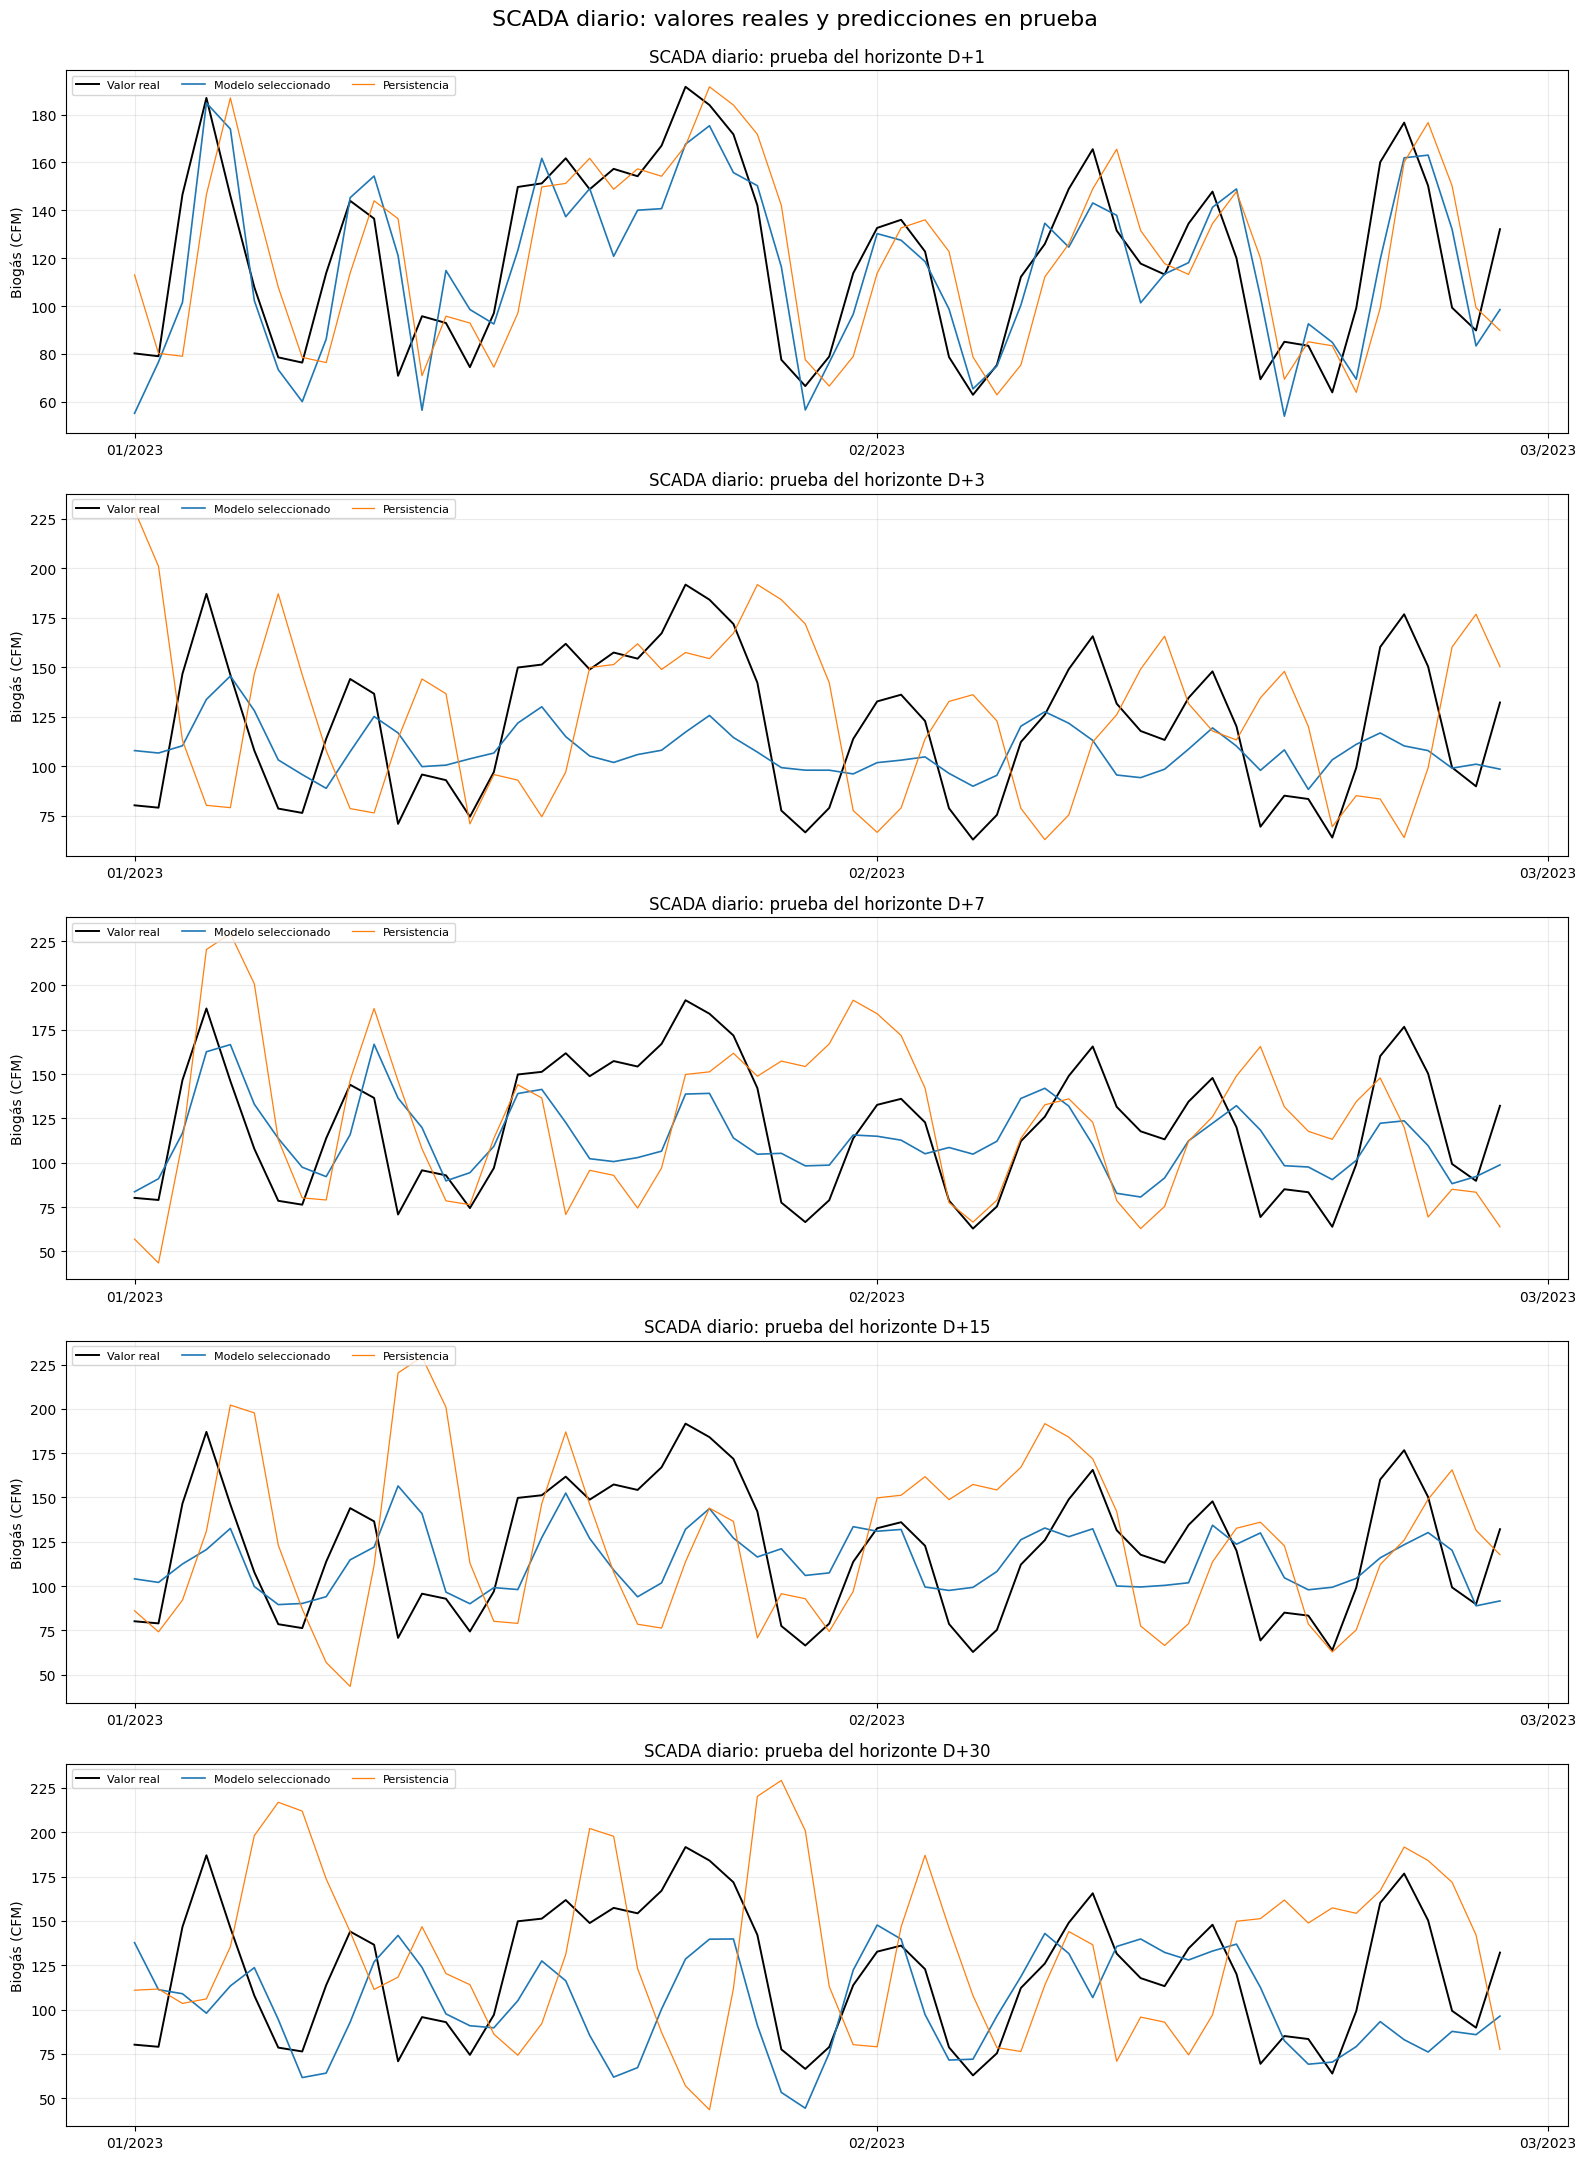

In [23]:
fig, ejes = plt.subplots(5, 1, figsize=(16, 22), sharex=False)

for eje, horizonte in zip(ejes, horizontes):
    tabla = predicciones_scada_prueba[
        predicciones_scada_prueba['horizonte_dias'] == horizonte
    ].sort_values('fecha_objetivo')

    eje.plot(tabla['fecha_objetivo'], tabla['real_CFM'], color='black', linewidth=1.4, label='Valor real')
    eje.plot(tabla['fecha_objetivo'], tabla['predicho_CFM'], color='tab:blue', linewidth=1.2, label='Modelo seleccionado')
    eje.plot(tabla['fecha_objetivo'], tabla['persistencia_CFM'], color='tab:orange', linewidth=0.9, label='Persistencia')
    eje.set_title(f'SCADA diario: prueba del horizonte D+{horizonte}')
    eje.set_ylabel('Biogás (CFM)')
    eje.grid(alpha=0.25)
    eje.legend(loc='upper left', ncol=3, fontsize=8)
    eje.xaxis.set_major_locator(mdates.MonthLocator())
    eje.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

fig.suptitle('SCADA diario: valores reales y predicciones en prueba', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(carpeta_graficos / '08_forecasting_scada_prueba.png', dpi=160, bbox_inches='tight')
plt.show()


### Análisis del experimento SCADA

El pronóstico **D+1** vuelve a ser el resultado más sólido. La Regresión Lineal alcanza un MAE de **17,72 CFM**, un R² de **0,63** y mejora la persistencia aproximadamente un **26,8 %**.

Entre **D+3 y D+15**, Random Forest mantiene MAE entre **27,79 y 28,92 CFM** y R² positivos, aunque bajos, entre **0,13 y 0,17**. Esto indica que las señales agregadas de alimentación y operación contienen información adicional, pero todavía queda una parte considerable de la variación sin explicar.

En **D+30**, la Regresión Lineal reduce el MAE de persistencia aproximadamente un **41,2 %**, pero el R² vuelve a ser negativo. De nuevo, la mejora porcentual se debe en parte a que repetir el último valor pierde utilidad a medida que aumenta el horizonte.

SCADA parece aportar resultados favorables, pero la prueba solamente contiene **58 días** y corresponde a enero y febrero de 2023. LABS y SCADA no fueron evaluados sobre la misma extensión histórica ni exactamente sobre las mismas observaciones, por lo que sus métricas no demuestran que una fuente sea superior a la otra. Este experimento debe interpretarse como una extensión del proyecto principal.


# 8. Exporto las tablas para Power BI

Finalmente exportaré tablas separadas para operación diaria, predicciones, métricas, calidad y calendario. Los valores ausentes se conservarán vacíos y las fechas utilizarán formato ISO. No sumaré LABS y SCADA como si fueran observaciones independientes de una misma tabla.

El caudal en CFM se mantendrá como caudal. No lo acumularé como volumen dentro de Power BI.


In [24]:
carpeta_powerbi = ruta_proyecto / 'data' / 'processed' / 'backtesting'
carpeta_powerbi.mkdir(parents=True, exist_ok=True)

# Operación diaria de LABS con banderas de calidad
operacion_diaria = df_lab_modelo.copy()
operacion_diaria['temperatura_baja_atipica'] = mascara_temperatura_baja.astype(int)
operacion_diaria['temperatura_alta_atipica'] = mascara_temperatura_alta.astype(int)
operacion_diaria['lodo_primario_atipico'] = mascara_lodo_primario.astype(int)
operacion_diaria['tramo_observado'] = operacion_diaria['Tramo']

# Unifico las predicciones de LABS y SCADA sin mezclar sus observaciones originales
predicciones_labs_exportar = predicciones_prueba.copy()
predicciones_labs_exportar['fuente'] = 'LABS diario'
predicciones_exportar = pd.concat(
    [predicciones_labs_exportar, predicciones_scada_prueba],
    ignore_index=True,
    sort=False
)

# Métricas finales de ambas fuentes
metricas_labs_exportar = resultados_prueba.copy()
metricas_labs_exportar['Fuente'] = 'LABS diario'
metricas_scada_exportar = resultados_scada_prueba.copy()
metricas_scada_exportar['Fuente'] = 'SCADA diario'
metricas_modelos = pd.concat(
    [metricas_labs_exportar, metricas_scada_exportar],
    ignore_index=True,
    sort=False
)

calidad_datos = pd.DataFrame([
    ['LABS', 'Calendario', 'Hueco continuo sin registros', 83, 'No se rellenó'],
    ['LABS', 'HSW-VS_percent', 'Valores ausentes', 358, 'Excluida del modelado'],
    ['LABS', 'PS-VS_percent', 'Valores ausentes', 377, 'Excluida del modelado'],
    ['LABS', 'HSW-COD_mgL', 'Valores ausentes', 471, 'Excluida del modelado'],
    ['LABS', 'Temperaturas, pH, DBO y TWAS-VS', 'Ausentes poco frecuentes', 84, 'Mediana aprendida en entrenamiento'],
    ['SCADA', 'Timestamp', 'Minutos ausentes', 484, 'No se interpolaron'],
    ['SCADA', 'Cobertura diaria', 'Días incompletos', 11, 'No se utilizaron como objetivo']
], columns=['fuente', 'variable_intervalo', 'problema', 'conteo', 'tratamiento'])

calendario = pd.DataFrame({
    'fecha': pd.date_range(df_lab_modelo['Fecha'].min(), df_lab_modelo['Fecha'].max(), freq='D')
})
calendario['año'] = calendario['fecha'].dt.year
calendario['mes'] = calendario['fecha'].dt.month
calendario['día_semana_numero'] = calendario['fecha'].dt.dayofweek + 1
calendario['día_semana'] = calendario['fecha'].dt.day_name()

# Diccionario compacto de las variables utilizadas en el modelado
diccionario_variables = pd.DataFrame([
    ['Biogas', 'Caudal medio diario de biogás total', 'CFM', 'LABS/SCADA', 'Diaria'],
    ['V-TWAS_gal', 'Volumen diario de TWAS alimentado', 'gal', 'LABS', 'Diaria'],
    ['V-PS_gal', 'Volumen diario de lodo primario alimentado', 'gal', 'LABS', 'Diaria'],
    ['V-HSW_gal', 'Volumen diario de residuos de alta carga alimentado', 'gal', 'LABS', 'Diaria'],
    ['Dig1-T_degF / Dig2-T_degF', 'Temperatura de los digestores', '°F', 'LABS', 'Diaria'],
    ['Dig1-pH / Dig2-pH', 'pH de los digestores', 'pH', 'LABS', 'Diaria'],
    ['SRT', 'Tiempo de retención de sólidos', 'd', 'LABS', 'Diaria'],
    ['AGV', 'Ácidos grasos volátiles por digestor', 'mg/L', 'LABS', 'Diaria con ausentes'],
    ['Alcalinidad', 'Alcalinidad como CaCO3 por digestor', 'mg/L', 'LABS', 'Diaria con ausentes'],
    ['FOS/TAC', 'Relación entre ácidos y capacidad alcalina', 'sin unidad', 'LABS', 'Diaria con ausentes'],
    ['SCADA variables', 'Medias diarias de alimentación y condiciones operativas', 'varias', 'SCADA', 'Diaria agregada']
], columns=['nombre', 'descripción', 'unidad', 'fuente', 'granularidad'])

archivos_exportacion = {
    'operacion_diaria.csv': operacion_diaria,
    'predicciones_prueba.csv': predicciones_exportar,
    'metricas_modelos.csv': metricas_modelos,
    'calidad_datos.csv': calidad_datos,
    'diccionario_variables.csv': diccionario_variables,
    'calendario.csv': calendario,
    'scada_diario.csv': scada_diario_modelo,
    'backtesting_temporal.csv': resultados_backtesting,
    'errores_por_nivel.csv': errores_por_nivel,
    'importancias_backtesting.csv': importancias_backtesting
}

for nombre_archivo, tabla in archivos_exportacion.items():
    tabla.to_csv(
        carpeta_powerbi / nombre_archivo,
        index=False,
        encoding='utf-8-sig',
        date_format='%Y-%m-%d'
    )
    print(nombre_archivo, '->', tabla.shape)


operacion_diaria.csv -> (1103, 50)
predicciones_prueba.csv -> (1200, 13)
metricas_modelos.csv -> (10, 15)
calidad_datos.csv -> (7, 5)
diccionario_variables.csv -> (11, 5)
calendario.csv -> (1186, 5)
scada_diario.csv -> (348, 36)
backtesting_temporal.csv -> (20, 15)
errores_por_nivel.csv -> (15, 6)
importancias_backtesting.csv -> (448, 8)


# 9. Conclusiones finales

El proyecto confirma que los datos permiten desarrollar un **forecasting diario de la producción total de biogás**, pero el nivel de confianza cambia de manera importante según el horizonte. Con LABS, la predicción D+1 alcanza un MAE de **20,58 CFM** en la prueba final, mejora la persistencia un **17,4 %** y obtiene un R² de **0,60**. El backtesting refuerza este resultado: la Regresión Lineal supera la persistencia y la media de siete días en los cuatro cortes, con un MAE medio de **17,24 CFM**. Por lo tanto, D+1 es el resultado principal y el que presenta la evidencia más consistente.

D+3 mantiene cierta utilidad porque supera la persistencia en los cuatro cortes del backtesting y la media semanal en tres. Sin embargo, sus R² son bajos o negativos en la mayoría de los periodos. D+7, D+15 y D+30 presentan una estabilidad menor y fallan al menos en uno de los cuatro cortes. **D+15 continúa siendo especialmente débil:** su mejora media frente a la media de siete días es de solo **2,74 %** y en la prueba final la referencia sencilla obtiene un MAE de **35,95 CFM**, inferior a los **40,87 CFM** del modelo seleccionado.

Los diagnósticos muestran que los modelos tienden a acercar las predicciones al promedio. D+1 conserva una relación clara entre los valores reales y predichos, pero aun así sobreestima parte de la producción baja y subestima los valores altos. Esta dificultad aumenta con el horizonte. En el nivel alto de producción, el MAE pasa de **23,54 CFM** en D+1 a valores entre **53,45 y 68,81 CFM** en los demás horizontes. Por esta razón, las predicciones largas no deberían utilizarse para anticipar picos operativos sin información adicional y una validación externa.

Las variables de estabilidad aportan información en algunos horizontes, especialmente D+7 y D+15. Sin embargo, alcalinidad, AGV y FOS/TAC no se midieron todos los días y una fecha de muestreo no demuestra que el resultado estuviera disponible al momento de pronosticar. El modelo ampliado utiliza 855 fechas completas y no rellena análisis inexistentes. En una aplicación real utilizaría primero el modelo operativo y solo incorporaría las variables de laboratorio después de confirmar su tiempo de entrega.

El experimento con SCADA sugiere que las señales diarias de alimentación y operación pueden mejorar el pronóstico, pero su prueba contiene solamente 58 días. LABS y SCADA no cubren exactamente el mismo periodo de evaluación, por lo que sus métricas no permiten afirmar que una fuente sea superior. SCADA se mantiene como una extensión del estudio. XGBoost también fue evaluado en todos los horizontes, pero no resultó seleccionado; una mayor complejidad no produjo automáticamente un mejor desempeño.

En términos operativos, los modelos predicen el **caudal total de biogás de la planta**, no la producción individual de cada digestor ni la cantidad de metano. Tampoco convierten un error de predicción en una falla biológica confirmada. Para utilizar el resultado fuera de este análisis sería necesario disponer de más historia, conocer la disponibilidad real de los análisis de laboratorio y validar el comportamiento con datos posteriores a marzo de 2023.


# 10. Verificación final

Como control de cierre, vuelvo a leer todos los CSV exportados y compruebo sus dimensiones. También confirmo que las fechas de origen y objetivo conservan un formato válido y que las predicciones mantienen sus valores reales y estimados después de la exportación.


In [25]:
verificacion_exportaciones = []

for nombre_archivo in archivos_exportacion:
    ruta_archivo = carpeta_powerbi / nombre_archivo
    tabla_leida = pd.read_csv(ruta_archivo)
    verificacion_exportaciones.append({
        'Archivo': nombre_archivo,
        'Existe': ruta_archivo.is_file(),
        'Filas': len(tabla_leida),
        'Columnas': len(tabla_leida.columns)
    })

predicciones_verificadas = pd.read_csv(
    carpeta_powerbi / 'predicciones_prueba.csv',
    parse_dates=['fecha_origen', 'fecha_objetivo']
)

if predicciones_verificadas[['real_CFM', 'predicho_CFM']].isna().any().any():
    raise ValueError('La exportación contiene predicciones o valores reales ausentes.')

if not (predicciones_verificadas['fecha_objetivo'] > predicciones_verificadas['fecha_origen']).all():
    raise ValueError('Encontré una fecha objetivo que no es posterior a su fecha de origen.')

display(pd.DataFrame(verificacion_exportaciones))
print('Predicciones verificadas:', len(predicciones_verificadas))
print('Horizontes exportados:', sorted(predicciones_verificadas['horizonte_dias'].unique()))
print('Fuentes exportadas:', sorted(predicciones_verificadas['fuente'].unique()))


,Archivo,Existe,Filas,Columnas
0,operacion_diaria.csv,True,1103,50
1,predicciones_prueba.csv,True,1200,13
2,metricas_modelos.csv,True,10,15
3,calidad_datos.csv,True,7,5
4,diccionario_variables.csv,True,11,5
5,calendario.csv,True,1186,5
6,scada_diario.csv,True,348,36
7,backtesting_temporal.csv,True,20,15
8,errores_por_nivel.csv,True,15,6
9,importancias_backtesting.csv,True,448,8


Predicciones verificadas: 1200
Horizontes exportados: [np.int64(1), np.int64(3), np.int64(7), np.int64(15), np.int64(30)]
Fuentes exportadas: ['LABS diario', 'SCADA diario']
